In [8]:
# ============================================================
# Cell 1: Imports & Environment Sanity Check
# (RF-DETR detection + ByteTrack tracking)
# ============================================================

# ---- Standard library ----
import os
import sys
import time
import json
import random
from pathlib import Path
from typing import List, Dict, Tuple, Optional

# ---- Numerical / scientific ----
import numpy as np

# ---- Computer vision / video I/O ----
import cv2

# ---- Visualization ----
import matplotlib.pyplot as plt

# ---- Deep learning ----
import torch

# ---- Detector ----
from rfdetr import RFDETRNano

# ---- Tracking (ByteTrack) ----
# supervision provides a ByteTrack wrapper that's convenient for notebooks
try:
    import supervision as sv
    SUPERVISION_OK = True
except Exception as e:
    SUPERVISION_OK = False
    print("Could not import supervision (needed for ByteTrack).")
    print(" Install with: pip install supervision")
    print(" Import error:", repr(e))

# ---- Utilities ----
from tqdm.auto import tqdm
import psutil

# ============================================================
# Environment sanity prints
# ============================================================

print("=== Environment Check ===")
print(f"Python version      : {sys.version.split()[0]}")
print(f"PyTorch version     : {torch.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version        : {torch.version.cuda}")
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")

print(f"CPU cores           : {psutil.cpu_count(logical=True)}")
print(f"supervision ready   : {SUPERVISION_OK}")
if SUPERVISION_OK:
    print(f"supervision version : {sv.__version__}")
print("=========================")

=== Environment Check ===
Python version      : 3.11.9
PyTorch version     : 2.5.1+cu121
CUDA available      : False
CPU cores           : 8
supervision ready   : True
supervision version : 0.27.0


Device: cpu
Checkpoint: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\models\enhanced-training\visdrone_rfdetr_nano_best_ema.pth
Detector loaded and ready.
Sanity test image: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\visdrone-dataset-rgb\val\images\0000276_02001_d_0000517.jpg
Detections: 11 (threshold=0.3)


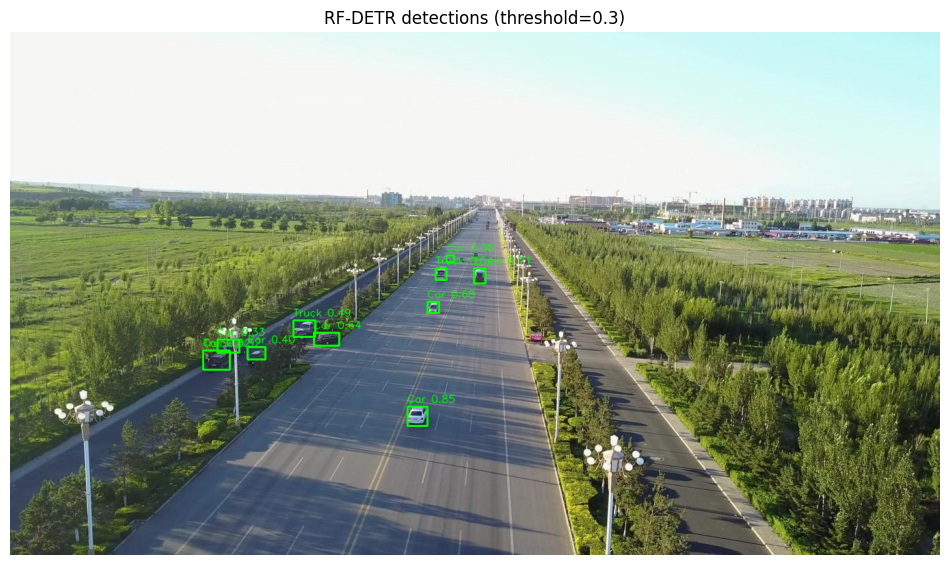

In [9]:
# ============================================================
# Cell 2: Load trained RF-DETR + visualize detections
# ============================================================

from pathlib import Path
import random
import torch
import cv2
import matplotlib.pyplot as plt

# -----------------------------
# 1) Paths + config
# -----------------------------
PHASE_ROOT = Path.cwd().parent.parent
RFDETR_MODELS_DIR = PHASE_ROOT / "rfdetr" / "models"
ENHANCED_RFDETR_MODELS_DIR = RFDETR_MODELS_DIR / "enhanced-training"

CKPT_PATH = ENHANCED_RFDETR_MODELS_DIR / "visdrone_rfdetr_nano_best_ema.pth"
VAL_IMG_DIR = PHASE_ROOT / "visdrone-dataset-rgb" / "val" / "images"

THRESHOLD = 0.30

# Phase class names
PHASE_CLASSES = {
    1: "Human",
    2: "Bicycle",
    3: "Car",
    4: "Truck",
    5: "Bus",
    6: "Other",
}

assert CKPT_PATH.exists(), f"Checkpoint not found: {CKPT_PATH}"
assert VAL_IMG_DIR.exists(), f"Val image dir not found: {VAL_IMG_DIR}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Checkpoint:", CKPT_PATH)

# -----------------------------
# 2) Load model (RF-DETR supported path)
# -----------------------------
global DETECTOR, _DETECTOR_CKPT
if "DETECTOR" not in globals() or "_DETECTOR_CKPT" not in globals() or _DETECTOR_CKPT != str(CKPT_PATH):
    print("Loading detector from checkpoint...")
    DETECTOR = RFDETRNano(pretrain_weights=str(CKPT_PATH))
    _DETECTOR_CKPT = str(CKPT_PATH)

DETECTOR.model.model.to(device)
DETECTOR.model.model.eval()
print("Detector loaded and ready.")

# -----------------------------
# 3) Pick a random image and run prediction
# -----------------------------
imgs = list(VAL_IMG_DIR.glob("*.jpg"))
assert imgs, f"No images found in: {VAL_IMG_DIR}"

image_path = str(random.choice(imgs))
print("Sanity test image:", image_path)

det = DETECTOR.predict(image_path, threshold=THRESHOLD)
print(f"Detections: {len(det.xyxy)} (threshold={THRESHOLD})")

# -----------------------------
# 4) Visualize boxes
# -----------------------------
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

for box, score, cls in zip(det.xyxy, det.confidence, det.class_id):
    x1, y1, x2, y2 = map(int, box.tolist())
    cls = int(cls)
    label = PHASE_CLASSES.get(cls, f"class_{cls}")
    text = f"{label} {float(score):.2f}"

    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        img_rgb,
        text,
        (x1, max(0, y1 - 6)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA,
    )

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"RF-DETR detections (threshold={THRESHOLD})")
plt.show()

In [10]:
# ============================================================
# Cell 3: Initialize ByteTrack
# ============================================================

import inspect
import numpy as np
import cv2

assert SUPERVISION_OK, "supervision is not installed/importable. Install with: pip install supervision"

# ---- Desired tracking settings (we'll tune later) ----
TRACK_THRESH = 0.30
TRACK_BUFFER = 30
MATCH_THRESH = 0.80
FRAME_RATE   = 30

# ---- Build kwargs based on what this supervision version supports ----
sig = inspect.signature(sv.ByteTrack.__init__)
params = set(sig.parameters.keys())

kwargs = {}

# Newer supervision naming
if "track_activation_threshold" in params:
    kwargs["track_activation_threshold"] = TRACK_THRESH
if "lost_track_buffer" in params:
    kwargs["lost_track_buffer"] = TRACK_BUFFER
if "minimum_matching_threshold" in params:
    kwargs["minimum_matching_threshold"] = MATCH_THRESH
if "frame_rate" in params:
    kwargs["frame_rate"] = FRAME_RATE

# Older naming (what we tried originally)
if "track_thresh" in params:
    kwargs["track_thresh"] = TRACK_THRESH
if "track_buffer" in params:
    kwargs["track_buffer"] = TRACK_BUFFER
if "match_thresh" in params:
    kwargs["match_thresh"] = MATCH_THRESH

# Fallback: if none of these are accepted, instantiate without args
try:
    TRACKER = sv.ByteTrack(**kwargs)
except TypeError:
    TRACKER = sv.ByteTrack()

print("ByteTrack initialized")
print("ByteTrack init kwargs used:", kwargs)

# -----------------------------
# Helper: RF-DETR detections -> supervision.Detections
# -----------------------------
def rfdetr_to_sv_detections(det, min_conf=0.30):
    xyxy = np.asarray(det.xyxy, dtype=np.float32)
    conf = np.asarray(det.confidence, dtype=np.float32)
    cls  = np.asarray(det.class_id, dtype=np.int32)

    keep = conf >= float(min_conf)
    return sv.Detections(
        xyxy=xyxy[keep],
        confidence=conf[keep],
        class_id=cls[keep]
    )

# -----------------------------
# Helper: Draw tracks
# -----------------------------
def draw_tracks(frame_bgr, detections: "sv.Detections", class_map: dict, show_conf=True):
    out = frame_bgr.copy()
    tracker_ids = getattr(detections, "tracker_id", None)

    for i, box in enumerate(detections.xyxy):
        x1, y1, x2, y2 = box.astype(int).tolist()
        cls = int(detections.class_id[i]) if detections.class_id is not None else -1
        conf = float(detections.confidence[i]) if detections.confidence is not None else 0.0

        tid = int(tracker_ids[i]) if tracker_ids is not None and tracker_ids[i] is not None else -1
        label = class_map.get(cls, f"class_{cls}")

        text = f"ID {tid}: {label}" if tid >= 0 else label
        if show_conf:
            text += f" {conf:.2f}"

        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(out, text, (x1, max(0, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)

    return out

print("Helpers ready: rfdetr_to_sv_detections(), draw_tracks()")

ByteTrack initialized
ByteTrack init kwargs used: {'track_activation_threshold': 0.3, 'lost_track_buffer': 30, 'minimum_matching_threshold': 0.8, 'frame_rate': 30}
Helpers ready: rfdetr_to_sv_detections(), draw_tracks()


In [4]:
# ============================================================
# Cell 4: Video files -> Detect (every N) -> ByteTrack -> Output mp4
# ============================================================

from pathlib import Path
import cv2
import numpy as np
from tqdm.auto import tqdm

# -----------------------------
# 1) Input configuration
# -----------------------------
BASE_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "vector_additions"
STILL_VIDEO_PATH = BASE_PATH / "camera_still.mp4"
MOVING_LEFT_VIDEO_PATH = BASE_PATH / "camera_moving_left.mp4"
MOVING_RIGHT_VIDEO_PATH = BASE_PATH / "camera_moving_right.mp4"

INPUT_VIDEO_PATHS = [
    STILL_VIDEO_PATH,
    MOVING_LEFT_VIDEO_PATH,
    MOVING_RIGHT_VIDEO_PATH,
]

OUTPUT_BASE_PATH = BASE_PATH / "detection_tracking_only"

DETECT_EVERY_N = 1
DET_THRESHOLD  = 0.30
MIN_BOX_AREA   = 30 * 30

FPS = 30.0
CLASS_MAP = PHASE_CLASSES

# Validate input videos
for video_path in INPUT_VIDEO_PATHS:
    assert video_path.exists(), f"Missing input video: {video_path}"

OUTPUT_BASE_PATH.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 2) Helper functions
# -----------------------------
def build_tensors_from_detections(detections: "sv.Detections") -> np.ndarray:
    """
    ByteTrack tensor format: Nx5 [x1, y1, x2, y2, score]
    """
    if len(detections) == 0:
        return np.zeros((0, 5), dtype=np.float32)

    return np.hstack([
        detections.xyxy.astype(np.float32),
        detections.confidence.reshape(-1, 1).astype(np.float32),
    ])

def active_tracks_to_boxes_and_ids(tracker) -> tuple[list[np.ndarray], list[int]]:
    """
    Convert tracker.tracked_tracks to (boxes, ids).
    Each track has tlbr (x1,y1,x2,y2) and external_track_id.
    """
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

# -----------------------------
# 3) Main loop over videos
# -----------------------------
fourcc = cv2.VideoWriter_fourcc(*"mp4v")

for VIDEO_PATH in INPUT_VIDEO_PATHS:
    print(f"\nProcessing: {VIDEO_PATH}")

    assert VIDEO_PATH.exists(), f"Could not find video: {VIDEO_PATH}"

    OUTPUT_PATH = OUTPUT_BASE_PATH / VIDEO_PATH.name

    cap = cv2.VideoCapture(str(VIDEO_PATH))
    assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 1:
        fps = FPS

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"Frames: {total_frames} | Size: {width}x{height} | Output FPS: {fps}")
    print(f"Detect every N: {DETECT_EVERY_N}")
    print(f"Saving to: {OUTPUT_PATH}")

    # Reset tracker per video so tracks do not leak across runs
    try:
        if hasattr(TRACKER, "frame_rate"):
            TRACKER.frame_rate = int(round(fps))
    except Exception:
        pass

    if hasattr(TRACKER, "reset"):
        TRACKER.reset()

    # Track metadata: track_id -> (class_id, confidence)
    track_meta = {}

    writer = cv2.VideoWriter(str(OUTPUT_PATH), fourcc, fps, (width, height))
    assert writer.isOpened(), f"Could not open writer: {OUTPUT_PATH}"

    pbar = tqdm(total=total_frames, desc=f"Processing {VIDEO_PATH.name}")

    for frame_idx in range(total_frames):
        ok, frame_bgr = cap.read()
        if not ok:
            break

        # Detection frame?
        if frame_idx % DETECT_EVERY_N == 0:
            temp_path = "temp_frame.jpg"
            cv2.imwrite(temp_path, frame_bgr)

            det = DETECTOR.predict(temp_path, threshold=DET_THRESHOLD)
            detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

            # Filter tiny boxes
            if len(detections) > 0:
                xyxy = detections.xyxy
                areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
                keep = areas >= MIN_BOX_AREA
                detections = detections[keep]

            # Advance tracker using tensors
            tensors = build_tensors_from_detections(detections)
            _ = TRACKER.update_with_tensors(tensors)

            # Get tracker_id mapping on detection frames
            det_with_ids = TRACKER.update_with_detections(detections)
            if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
                for i in range(len(det_with_ids)):
                    tid = int(det_with_ids.tracker_id[i])
                    cls = int(det_with_ids.class_id[i])
                    conf = float(det_with_ids.confidence[i])
                    track_meta[tid] = (cls, conf)

        else:
            # No detections: propagate tracks forward
            _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

        # Draw active tracks every frame
        out = frame_bgr.copy()
        boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)

        for box, tid in zip(boxes, ids):
            x1, y1, x2, y2 = box.astype(int).tolist()
            cls, conf = track_meta.get(tid, (-1, 0.0))
            label = CLASS_MAP.get(cls, f"class_{cls}") if cls != -1 else "unknown"
            text = f"ID {tid}: {label} {conf:.2f}"

            cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(
                out,
                text,
                (x1, max(0, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                1,
                cv2.LINE_AA
            )

        writer.write(out)
        pbar.update(1)

    pbar.close()
    cap.release()
    writer.release()

    print(f"Done. Saved tracked video to: {OUTPUT_PATH}")

print("\nAll videos processed.")


Processing: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\camera_still.mp4
Frames: 101 | Size: 800x600 | Output FPS: 20.0
Detect every N: 1
Saving to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\detection_tracking_only\camera_still.mp4


Processing camera_still.mp4:   0%|          | 0/101 [00:00<?, ?it/s]

Done. Saved tracked video to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\detection_tracking_only\camera_still.mp4

Processing: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\camera_moving_left.mp4
Frames: 94 | Size: 800x600 | Output FPS: 20.0
Detect every N: 1
Saving to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\detection_tracking_only\camera_moving_left.mp4


Processing camera_moving_left.mp4:   0%|          | 0/94 [00:00<?, ?it/s]

Done. Saved tracked video to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\detection_tracking_only\camera_moving_left.mp4

Processing: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\camera_moving_right.mp4
Frames: 110 | Size: 800x600 | Output FPS: 20.0
Detect every N: 1
Saving to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\detection_tracking_only\camera_moving_right.mp4


Processing camera_moving_right.mp4:   0%|          | 0/110 [00:00<?, ?it/s]

Done. Saved tracked video to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\detection_tracking_only\camera_moving_right.mp4

All videos processed.


In [5]:
# ============================================================
# Cell 5: Experiment setup for moving-camera velocity estimation
# Purpose:
# - define the 3 test videos
# - define known camera-speed inputs
# - define experiment order:
#     1) still-camera baseline
#     2) moving-camera ego-direction estimation
#     3) vector compensation
# - create output folders for all later cells
# ============================================================

from pathlib import Path
import json

# -----------------------------
# 1) Base paths
# -----------------------------
BASE_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "vector_additions"

STILL_VIDEO_PATH        = BASE_PATH / "camera_still.mp4"
MOVING_LEFT_VIDEO_PATH  = BASE_PATH / "camera_moving_left.mp4"
MOVING_RIGHT_VIDEO_PATH = BASE_PATH / "camera_moving_right.mp4"

INPUT_VIDEO_PATHS = {
    "still": STILL_VIDEO_PATH,
    "moving_left": MOVING_LEFT_VIDEO_PATH,
    "moving_right": MOVING_RIGHT_VIDEO_PATH,
}

for name, path in INPUT_VIDEO_PATHS.items():
    assert path.exists(), f"Missing {name} video: {path}"

# -----------------------------
# 2) Output folders
# -----------------------------
OUTPUT_BASE_DIR = BASE_PATH / "moving_camera_velocity_pipeline"
OUTPUT_BASE_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIRS = {
    "baseline": OUTPUT_BASE_DIR / "01_still_camera_baseline",
    "ego":      OUTPUT_BASE_DIR / "02_ego_direction_estimation",
    "final":    OUTPUT_BASE_DIR / "03_vector_compensation",
    "debug":    OUTPUT_BASE_DIR / "debug",
}

for p in OUTPUT_DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 3) Known camera-speed inputs for testing
#    Convention:
#    - speed magnitude is known
#    - sign is NOT used directly in compensation
#    - later cells will estimate direction from background
# -----------------------------
CAMERA_SPEED_KMH_BY_VIDEO = {
    "still": 0.0,
    "moving_left": 5.0,
    "moving_right": 5.0,
}

# -----------------------------
# 4) Ground-plane coordinate convention
#    We will use image-aligned 2D coordinates for now:
#      +x = right in image
#      +y = down in image
#
#    Later:
#    - car relative velocity will be estimated in this frame
#    - camera ego direction will be estimated in this frame
#    - vector compensation will happen in this frame
# -----------------------------
GROUND_PLANE_COORDS = {
    "x_axis": "image_right",
    "y_axis": "image_down",
    "note": "All velocity vectors must be expressed in the same 2D frame before compensation."
}

# -----------------------------
# 5) Experiment order
# -----------------------------
EXPERIMENT_SEQUENCE = [
    {
        "stage": "baseline_validation",
        "video_key": "still",
        "goal": "Verify that the existing bbox-scale-based estimator behaves properly when camera motion is zero."
    },
    {
        "stage": "ego_direction_estimation",
        "video_key": "moving_left",
        "goal": "Estimate dominant background ego direction and inspect whether it points left."
    },
    {
        "stage": "ego_direction_estimation",
        "video_key": "moving_right",
        "goal": "Estimate dominant background ego direction and inspect whether it points right."
    },
    {
        "stage": "vector_compensation",
        "video_key": "moving_left",
        "goal": "Combine relative vehicle velocity with known camera-speed magnitude and estimated ego direction."
    },
    {
        "stage": "vector_compensation",
        "video_key": "moving_right",
        "goal": "Combine relative vehicle velocity with known camera-speed magnitude and estimated ego direction."
    },
]

# -----------------------------
# 6) High-level algorithm switches
# -----------------------------
PIPELINE_FLAGS = {
    "run_still_baseline_first": True,
    "estimate_ego_direction_from_background": True,
    "mask_detected_objects_for_ego_estimation": True,
    "use_known_camera_speed_magnitude": True,
    "perform_vector_compensation": True,
    "save_debug_visualizations": True,
}

# -----------------------------
# 7) Save run config snapshot
# -----------------------------
run_config = {
    "videos": {k: str(v) for k, v in INPUT_VIDEO_PATHS.items()},
    "camera_speed_kmh_by_video": CAMERA_SPEED_KMH_BY_VIDEO,
    "ground_plane_coords": GROUND_PLANE_COORDS,
    "experiment_sequence": EXPERIMENT_SEQUENCE,
    "pipeline_flags": PIPELINE_FLAGS,
    "output_dirs": {k: str(v) for k, v in OUTPUT_DIRS.items()},
}

RUN_CONFIG_PATH = OUTPUT_BASE_DIR / "run_config.json"
with open(RUN_CONFIG_PATH, "w") as f:
    json.dump(run_config, f, indent=2)

# -----------------------------
# 8) Summary print
# -----------------------------
print("=== Cell 5: Moving-camera experiment setup ===")
print("Videos:")
for k, v in INPUT_VIDEO_PATHS.items():
    print(f"  - {k:12s}: {v}")

print("\nKnown camera speed magnitudes (km/h):")
for k, v in CAMERA_SPEED_KMH_BY_VIDEO.items():
    print(f"  - {k:12s}: {v:.2f}")

print("\nOutput directories:")
for k, v in OUTPUT_DIRS.items():
    print(f"  - {k:12s}: {v}")

print("\nExperiment sequence:")
for i, step in enumerate(EXPERIMENT_SEQUENCE, start=1):
    print(f"  {i}. [{step['stage']}] {step['video_key']} -> {step['goal']}")

print("\nRun config saved to:", RUN_CONFIG_PATH)
print("==============================================")

=== Cell 5: Moving-camera experiment setup ===
Videos:
  - still       : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\camera_still.mp4
  - moving_left : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\camera_moving_left.mp4
  - moving_right: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\camera_moving_right.mp4

Known camera speed magnitudes (km/h):
  - still       : 0.00
  - moving_left : 5.00
  - moving_right: 5.00

Output directories:
  - baseline    : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\01_still_camera_baseline
  - ego         : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_cam

In [11]:
# ============================================================
# Cell 6: Shared helpers + still-camera baseline runner
# Purpose:
# - keep existing bbox-dimension-based foundation
# - move from scalar speed to 2D relative velocity
# - create a reusable per-video runner
# - use this first on the still-camera video
#
# Notes:
# - This cell does NOT do ego-direction estimation yet
# - This cell does NOT do camera compensation yet
# - It produces the car's image-aligned relative velocity estimate:
#       vx_rel_mps, vy_rel_mps, speed_rel_kmh
# ============================================================

import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
from tqdm.auto import tqdm

assert SUPERVISION_OK, "supervision must be installed/importable for ByteTrack."

# -----------------------------
# 1) Detection / tracking / estimator config
# -----------------------------
DET_THRESHOLD = 0.30
MIN_BOX_AREA = 30 * 30
DETECT_EVERY_N = 1

TRACK_THRESH = 0.30
TRACK_BUFFER = 30
MATCH_THRESH = 0.80
DEFAULT_FPS = 30.0

# keep the same live-style foundation
SPEED_ESTIMATION_CLASS_IDS = {1, 2, 3, 4, 5, 6}

CLASS_DIMENSION_PRIORS = {
    "Human": {
        "width_m": 0.50,
        "length_m": 0.50,
        "height_m": 1.70,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
    "Bicycle": {
        "width_m": 0.60,
        "length_m": 1.80,
        "height_m": 1.10,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
    "Car": {
        "width_m": 2.05,
        "length_m": 5.10,
        "height_m": 1.50,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
    "Truck": {
        "width_m": 2.50,
        "length_m": 7.00,
        "height_m": 3.20,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
    "Bus": {
        "width_m": 2.55,
        "length_m": 12.00,
        "height_m": 3.20,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
    "Other": {
        "width_m": 2.00,
        "length_m": 4.50,
        "height_m": 1.80,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
}

CLASS_PRIOR_ALIASES = {
    "person": "Human",
    "pedestrian": "Human",
    "people": "Human",
    "bike": "Bicycle",
    "bicycle": "Bicycle",
    "cyclist": "Bicycle",
    "car": "Car",
    "sedan": "Car",
    "van": "Car",
    "suv": "Car",
    "pickup": "Car",
    "truck": "Truck",
    "lorry": "Truck",
    "semi": "Truck",
    "bus": "Bus",
    "coach": "Bus",
    "other": "Other",
    "motor": "Other",
    "vehicle": "Other",
}

MAX_REASONABLE_SPEED_KMH = 250.0
MPP_WINDOW = 5
VEL_WINDOW = 5
BORDER_MARGIN_PX = 20
TRAIL_LEN = 20

# -----------------------------
# 2) Generic helpers
# -----------------------------
def canonicalize_class_name(label: str) -> str:
    if label is None:
        return "Other"
    label = str(label).strip()
    if label in CLASS_DIMENSION_PRIORS:
        return label
    lowered = label.lower()
    return CLASS_PRIOR_ALIASES.get(lowered, "Other")

def get_class_dimension_prior(label: str) -> dict:
    canonical = canonicalize_class_name(label)
    prior = CLASS_DIMENSION_PRIORS[canonical].copy()
    prior["canonical_label"] = canonical
    prior["requested_label"] = label
    return prior

def rfdetr_to_sv_detections(det, min_conf=0.30):
    xyxy = np.asarray(det.xyxy, dtype=np.float32)
    conf = np.asarray(det.confidence, dtype=np.float32)
    cls = np.asarray(det.class_id, dtype=np.int32)

    keep = conf >= float(min_conf)
    return sv.Detections(
        xyxy=xyxy[keep],
        confidence=conf[keep],
        class_id=cls[keep],
    )

def build_tracker(frame_rate):
    sig = inspect.signature(sv.ByteTrack.__init__)
    params = set(sig.parameters.keys())
    kwargs = {}

    if "track_activation_threshold" in params:
        kwargs["track_activation_threshold"] = TRACK_THRESH
    if "lost_track_buffer" in params:
        kwargs["lost_track_buffer"] = TRACK_BUFFER
    if "minimum_matching_threshold" in params:
        kwargs["minimum_matching_threshold"] = MATCH_THRESH
    if "frame_rate" in params:
        kwargs["frame_rate"] = int(round(frame_rate))

    if "track_thresh" in params:
        kwargs["track_thresh"] = TRACK_THRESH
    if "track_buffer" in params:
        kwargs["track_buffer"] = TRACK_BUFFER
    if "match_thresh" in params:
        kwargs["match_thresh"] = MATCH_THRESH

    try:
        tracker = sv.ByteTrack(**kwargs)
    except TypeError:
        tracker = sv.ByteTrack()

    if hasattr(tracker, "reset"):
        tracker.reset()

    return tracker

def active_tracks_to_boxes_and_ids(tracker):
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

def bbox_center_xyxy(box_xyxy):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return np.array([(x1 + x2) / 2.0, (y1 + y2) / 2.0], dtype=np.float32)

def bbox_bottom_center_xyxy(box_xyxy, y_offset_px=0.0):
    x1, y1, x2, y2 = map(float, box_xyxy)
    cx = 0.5 * (x1 + x2)
    cy = y2 + float(y_offset_px)
    return np.array([cx, cy], dtype=np.float32)

def representative_point_xyxy(box_xyxy, class_label):
    prior = get_class_dimension_prior(class_label)
    mode = prior["rep_point_mode"]
    y_offset_px = prior["rep_y_offset_px"]

    if mode == "center":
        return bbox_center_xyxy(box_xyxy)
    if mode == "bottom_center":
        return bbox_bottom_center_xyxy(box_xyxy, y_offset_px=y_offset_px)
    raise ValueError(f"Unsupported representative point mode: {mode}")

def bbox_touches_border(box_xyxy, image_width, image_height, margin_px=20):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return (
        x1 <= margin_px or
        y1 <= margin_px or
        x2 >= (image_width - margin_px) or
        y2 >= (image_height - margin_px)
    )

def safe_bbox_dims(box_xyxy):
    x1, y1, x2, y2 = map(float, box_xyxy)
    w_px = max(float(x2 - x1), 1e-6)
    h_px = max(float(y2 - y1), 1e-6)
    return w_px, h_px

def moving_average_ignore_none(values, window=5):
    recent = [float(v) for v in values if v is not None]
    if len(recent) == 0:
        return None
    return float(np.mean(recent[-int(window):]))

def is_reasonable_speed_kmh(speed_kmh, max_kmh=250.0):
    return speed_kmh is not None and np.isfinite(speed_kmh) and (0.0 <= float(speed_kmh) <= float(max_kmh))

def compute_local_scale_from_box(box_xyxy, class_label):
    prior = get_class_dimension_prior(class_label)
    bbox_w_px, bbox_h_px = safe_bbox_dims(box_xyxy)

    mpp_x = float(prior["width_m"]) / bbox_w_px
    mpp_y = float(prior["length_m"]) / bbox_h_px
    mpp_geom = float(np.sqrt(max(mpp_x, 1e-12) * max(mpp_y, 1e-12)))

    return {
        "canonical_label": prior["canonical_label"],
        "width_m": float(prior["width_m"]),
        "length_m": float(prior["length_m"]),
        "bbox_width_px": bbox_w_px,
        "bbox_height_px": bbox_h_px,
        "mpp_x": mpp_x,
        "mpp_y": mpp_y,
        "mpp_geom": mpp_geom,
    }

def make_empty_track_history():
    return {
        "frames": [],
        "boxes": [],
        "labels": [],
        "confidences": [],
        "image_points": [],
        "mpp_geom": [],
        "mpp_smoothed": [],
        "vx_rel_mps_raw": [],
        "vy_rel_mps_raw": [],
        "speed_rel_kmh_raw": [],
        "vx_rel_mps_smooth": [],
        "vy_rel_mps_smooth": [],
        "speed_rel_kmh_smooth": [],
    }

def append_relative_velocity_observation(track_history, frame_idx, box_xyxy, class_label, confidence, fps):
    rep_pt = representative_point_xyxy(box_xyxy, class_label)
    scale_info = compute_local_scale_from_box(box_xyxy, class_label)

    track_history["frames"].append(int(frame_idx))
    track_history["boxes"].append(np.asarray(box_xyxy, dtype=np.float32))
    track_history["labels"].append(class_label)
    track_history["confidences"].append(float(confidence))
    track_history["image_points"].append(rep_pt)
    track_history["mpp_geom"].append(scale_info["mpp_geom"])

    current_mpp_smoothed = moving_average_ignore_none(track_history["mpp_geom"], window=MPP_WINDOW)
    track_history["mpp_smoothed"].append(current_mpp_smoothed)

    vx_rel_mps_raw = None
    vy_rel_mps_raw = None
    speed_rel_kmh_raw = None

    if len(track_history["image_points"]) >= 2:
        p1 = np.asarray(track_history["image_points"][-2], dtype=np.float64)
        p2 = np.asarray(track_history["image_points"][-1], dtype=np.float64)

        prev_mpp = track_history["mpp_smoothed"][-2]
        curr_mpp = track_history["mpp_smoothed"][-1]

        if prev_mpp is not None and curr_mpp is not None:
            local_mpp = 0.5 * (float(prev_mpp) + float(curr_mpp))
            dt = 1.0 / float(fps)

            dx_px = float(p2[0] - p1[0])
            dy_px = float(p2[1] - p1[1])

            # image-aligned ground-plane convention:
            # +x = right, +y = down
            vx_rel_mps_raw = (dx_px * local_mpp) / dt
            vy_rel_mps_raw = (dy_px * local_mpp) / dt

            speed_rel_mps_raw = float(np.sqrt(vx_rel_mps_raw**2 + vy_rel_mps_raw**2))
            speed_rel_kmh_raw = 3.6 * speed_rel_mps_raw

            if not is_reasonable_speed_kmh(speed_rel_kmh_raw, max_kmh=MAX_REASONABLE_SPEED_KMH):
                vx_rel_mps_raw = None
                vy_rel_mps_raw = None
                speed_rel_kmh_raw = None

    track_history["vx_rel_mps_raw"].append(vx_rel_mps_raw)
    track_history["vy_rel_mps_raw"].append(vy_rel_mps_raw)
    track_history["speed_rel_kmh_raw"].append(speed_rel_kmh_raw)

    vx_rel_mps_smooth = moving_average_ignore_none(track_history["vx_rel_mps_raw"], window=VEL_WINDOW)
    vy_rel_mps_smooth = moving_average_ignore_none(track_history["vy_rel_mps_raw"], window=VEL_WINDOW)
    speed_rel_kmh_smooth = None
    if vx_rel_mps_smooth is not None and vy_rel_mps_smooth is not None:
        speed_rel_kmh_smooth = 3.6 * float(np.sqrt(vx_rel_mps_smooth**2 + vy_rel_mps_smooth**2))

    track_history["vx_rel_mps_smooth"].append(vx_rel_mps_smooth)
    track_history["vy_rel_mps_smooth"].append(vy_rel_mps_smooth)
    track_history["speed_rel_kmh_smooth"].append(speed_rel_kmh_smooth)

    return {
        "rep_pt": rep_pt,
        "scale_info": scale_info,
        "vx_rel_mps_raw": vx_rel_mps_raw,
        "vy_rel_mps_raw": vy_rel_mps_raw,
        "speed_rel_kmh_raw": speed_rel_kmh_raw,
        "vx_rel_mps_smooth": vx_rel_mps_smooth,
        "vy_rel_mps_smooth": vy_rel_mps_smooth,
        "speed_rel_kmh_smooth": speed_rel_kmh_smooth,
    }

# -----------------------------
# 3) Main reusable runner
# -----------------------------
def run_relative_velocity_baseline(
    video_path,
    output_dir,
    detector,
    class_map,
    experiment_name="baseline",
):
    video_path = Path(video_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    output_video_path = output_dir / f"{experiment_name}_annotated.mp4"
    output_csv_path = output_dir / f"{experiment_name}_observations.csv"
    temp_infer_path = output_dir / f"_{experiment_name}_temp_frame.jpg"

    cap = cv2.VideoCapture(str(video_path))
    assert cap.isOpened(), f"Could not open video: {video_path}"

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or not np.isfinite(fps) or fps <= 1:
        fps = DEFAULT_FPS

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    tracker = build_tracker(frame_rate=fps)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_video_path), fourcc, fps, (width, height))
    assert writer.isOpened(), f"Could not open writer: {output_video_path}"

    print(f"Running {experiment_name}")
    print(f"Video: {video_path}")
    print(f"Frames: {total_frames} | Size: {width}x{height} | FPS: {fps:.2f}")

    track_histories = {}
    track_meta = {}
    output_rows = []

    pbar = tqdm(total=total_frames, desc=f"{experiment_name}")

    for frame_idx in range(total_frames):
        ok, frame_bgr = cap.read()
        if not ok:
            break

        if frame_idx % DETECT_EVERY_N == 0:
            ok_write = cv2.imwrite(str(temp_infer_path), frame_bgr)
            assert ok_write, f"Failed to write temp frame: {temp_infer_path}"

            det = detector.predict(str(temp_infer_path), threshold=DET_THRESHOLD)
            detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

            if len(detections) > 0:
                xyxy = detections.xyxy
                areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
                keep = areas >= MIN_BOX_AREA
                detections = detections[keep]

            det_with_ids = tracker.update_with_detections(detections)

            if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
                for i in range(len(det_with_ids)):
                    tid = int(det_with_ids.tracker_id[i])
                    cls = int(det_with_ids.class_id[i])
                    conf = float(det_with_ids.confidence[i])
                    label = class_map.get(cls, "Other")
                    track_meta[tid] = (cls, label, conf)
        else:
            empty_dets = sv.Detections(
                xyxy=np.zeros((0, 4), dtype=np.float32),
                confidence=np.zeros((0,), dtype=np.float32),
                class_id=np.zeros((0,), dtype=np.int32),
            )
            _ = tracker.update_with_detections(empty_dets)

        boxes, ids = active_tracks_to_boxes_and_ids(tracker)
        out = frame_bgr.copy()

        for box, tid in zip(boxes, ids):
            cls, label, conf = track_meta.get(tid, (-1, "Other", 0.0))
            if cls not in SPEED_ESTIMATION_CLASS_IDS:
                continue
            if bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX):
                continue

            if tid not in track_histories:
                track_histories[tid] = make_empty_track_history()

            result = append_relative_velocity_observation(
                track_history=track_histories[tid],
                frame_idx=frame_idx,
                box_xyxy=box,
                class_label=label,
                confidence=conf,
                fps=fps,
            )

            rep_pt = result["rep_pt"]
            scale_info = result["scale_info"]

            output_rows.append({
                "track_id": int(tid),
                "frame_idx": int(frame_idx),
                "class_id": int(cls),
                "label": label,
                "canonical_label": scale_info["canonical_label"],
                "confidence": float(conf),

                "bbox_x1": float(box[0]),
                "bbox_y1": float(box[1]),
                "bbox_x2": float(box[2]),
                "bbox_y2": float(box[3]),

                "rep_image_x": float(rep_pt[0]),
                "rep_image_y": float(rep_pt[1]),

                "bbox_width_px": float(scale_info["bbox_width_px"]),
                "bbox_height_px": float(scale_info["bbox_height_px"]),
                "mpp_x": float(scale_info["mpp_x"]),
                "mpp_y": float(scale_info["mpp_y"]),
                "mpp_geom": float(scale_info["mpp_geom"]),
                "mpp_smoothed": track_histories[tid]["mpp_smoothed"][-1],

                "vx_rel_mps_raw": result["vx_rel_mps_raw"],
                "vy_rel_mps_raw": result["vy_rel_mps_raw"],
                "speed_rel_kmh_raw": result["speed_rel_kmh_raw"],

                "vx_rel_mps_smooth": result["vx_rel_mps_smooth"],
                "vy_rel_mps_smooth": result["vy_rel_mps_smooth"],
                "speed_rel_kmh_smooth": result["speed_rel_kmh_smooth"],
            })

            x1, y1, x2, y2 = map(int, np.round(box))
            cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)

            rep_x, rep_y = map(int, np.round(rep_pt))
            cv2.circle(out, (rep_x, rep_y), 4, (0, 0, 255), -1)

            pts = np.array(track_histories[tid]["image_points"][-TRAIL_LEN:], dtype=np.float32)
            if len(pts) >= 2:
                pts = np.round(pts).astype(int)
                for j in range(1, len(pts)):
                    cv2.line(out, tuple(pts[j - 1]), tuple(pts[j]), (255, 0, 0), 2, cv2.LINE_AA)

            text = f"ID {tid}: {label} {conf:.2f}"
            if result["vx_rel_mps_smooth"] is not None and result["vy_rel_mps_smooth"] is not None:
                text += (
                    f" | vx {result['vx_rel_mps_smooth']:.2f}"
                    f" vy {result['vy_rel_mps_smooth']:.2f}"
                    f" | {result['speed_rel_kmh_smooth']:.2f} km/h"
                )

            cv2.putText(
                out,
                text,
                (x1, max(0, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                (0, 255, 0),
                1,
                cv2.LINE_AA,
            )

        writer.write(out)
        pbar.update(1)

    pbar.close()
    cap.release()
    writer.release()

    if temp_infer_path.exists():
        try:
            temp_infer_path.unlink()
        except Exception:
            pass

    obs_df = pd.DataFrame(output_rows)
    assert len(obs_df) > 0, f"No observations collected for {experiment_name}"

    obs_df.to_csv(output_csv_path, index=False)

    print(f"Saved annotated video: {output_video_path}")
    print(f"Saved observations CSV: {output_csv_path}")

    return {
        "output_video_path": output_video_path,
        "output_csv_path": output_csv_path,
        "obs_df": obs_df,
    }

print("Cell 6 ready: shared helpers + run_relative_velocity_baseline()")

Cell 6 ready: shared helpers + run_relative_velocity_baseline()


Running still_camera_baseline
Video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\camera_still.mp4
Frames: 101 | Size: 800x600 | FPS: 20.00


still_camera_baseline:   0%|          | 0/101 [00:00<?, ?it/s]

Saved annotated video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\01_still_camera_baseline\still_camera_baseline_annotated.mp4
Saved observations CSV: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\01_still_camera_baseline\still_camera_baseline_observations.csv
=== Still-camera baseline summary ===
Rows: 99
Unique tracks: 1
Class counts:


,count
canonical_label,
Car,99



Velocity / speed summary:


,vx_rel_mps_raw,vy_rel_mps_raw,speed_rel_kmh_raw,vx_rel_mps_smooth,vy_rel_mps_smooth,speed_rel_kmh_smooth,mpp_geom,mpp_smoothed
count,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,99.000000,99.000000
mean,7.854700,0.274601,28.327703,7.759677,0.272020,27.963293,0.058161,0.058076
std,1.522431,0.327013,5.432093,1.132637,0.115405,4.020007,0.001552,0.001568
min,-0.035528,-0.624409,0.714607,-0.035528,0.009122,0.714607,0.053256,0.053436
25%,7.285578,0.081516,26.233301,7.780110,0.198964,28.019618,0.057269,0.057167
50%,7.669426,0.275205,27.680606,7.865868,0.267182,28.338529,0.058263,0.058205
75%,8.330645,0.505165,30.009229,7.980405,0.327877,28.754083,0.059520,0.059327
max,18.252626,1.129825,65.712148,10.075252,0.711812,36.294507,0.060707,0.060119



Dominant track_id: 1
Frames in dominant track: 99


,track_id,frame_idx,class_id,label,canonical_label,confidence,bbox_x1,bbox_y1,bbox_x2,bbox_y2,...,mpp_x,mpp_y,mpp_geom,mpp_smoothed,vx_rel_mps_raw,vy_rel_mps_raw,speed_rel_kmh_raw,vx_rel_mps_smooth,vy_rel_mps_smooth,speed_rel_kmh_smooth
0,1,0,3,Car,Car,0.904526,25.109432,280.708588,118.344559,319.718292,...,0.021987,0.130737,0.053615,0.053615,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,3,Car,Car,0.900629,24.768787,280.622864,118.618828,319.900726,...,0.021843,0.129844,0.053256,0.053436,-0.035528,0.195297,0.714607,-0.035528,0.195297,0.714607
2,1,2,3,Car,Car,0.881672,31.665642,281.356018,123.773407,319.908875,...,0.022257,0.132286,0.054261,0.053711,6.456333,0.008730,23.242820,3.210403,0.102014,11.563283
3,1,3,3,Car,Car,0.890845,38.636059,282.051941,130.838058,320.655243,...,0.022234,0.132113,0.054198,0.053832,7.546867,0.802667,27.321955,4.655891,0.335565,16.804684
4,1,4,3,Car,Car,0.891621,45.776173,282.758789,136.493851,320.731720,...,0.022598,0.134306,0.055091,0.054084,6.904439,0.082531,24.857755,5.218028,0.272306,18.810461


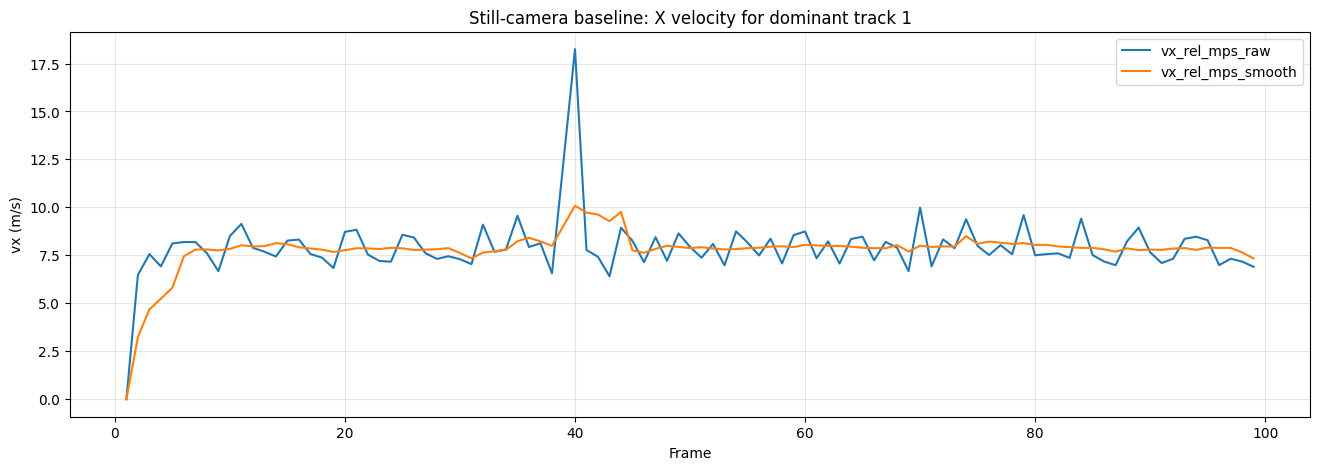

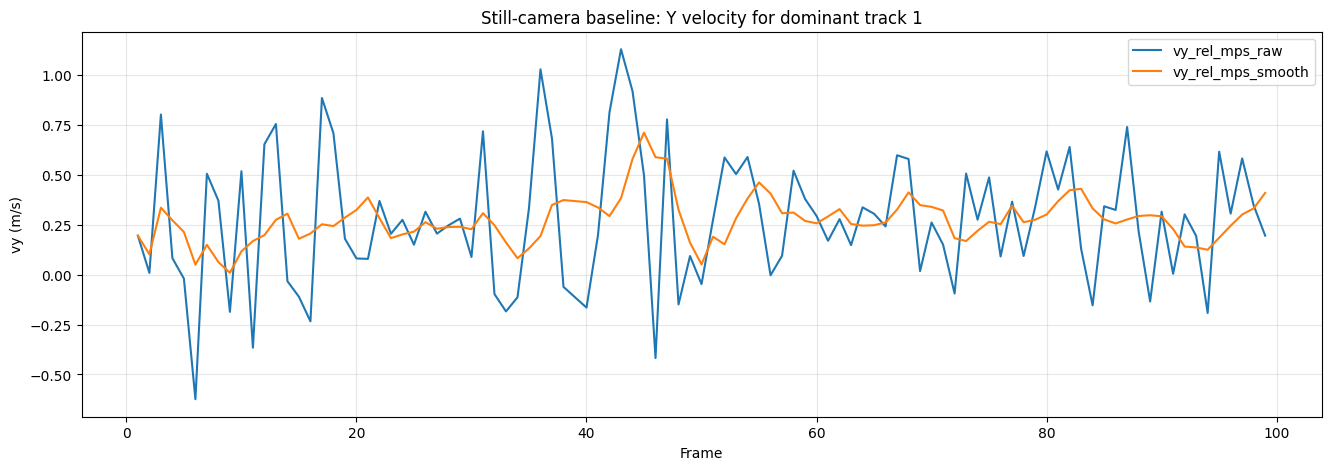

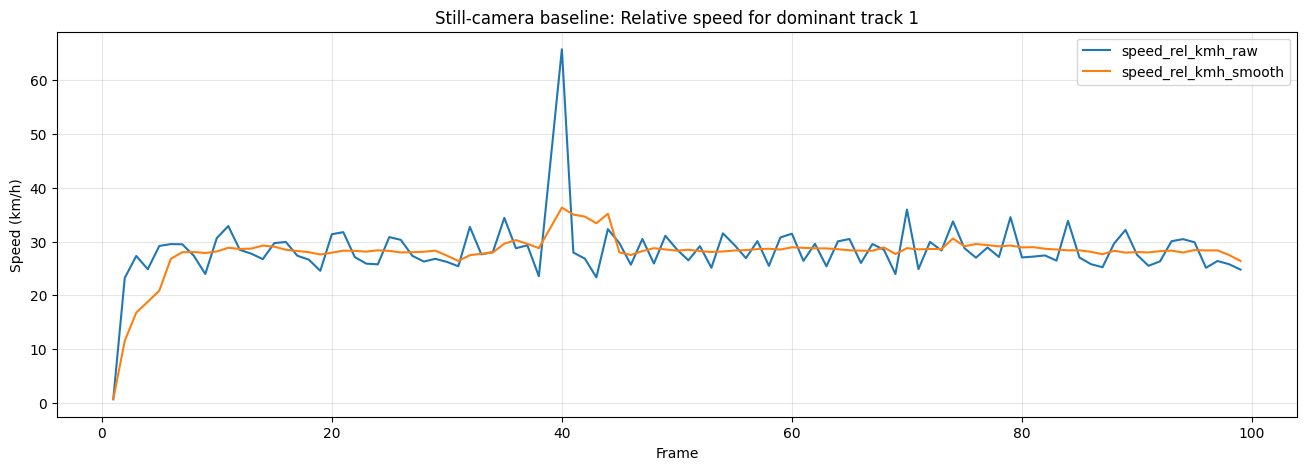

=== Dominant-track sanity check ===
Mean smoothed speed (km/h): 27.963
Median smoothed speed (km/h): 28.339
Std smoothed speed (km/h): 4.020
Mean smoothed vx (m/s): 7.760
Mean smoothed vy (m/s): 0.272

Saved files:
Annotated video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\01_still_camera_baseline\still_camera_baseline_annotated.mp4
Observations CSV: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\01_still_camera_baseline\still_camera_baseline_observations.csv

Cell 7 complete.


In [7]:
# ============================================================
# Cell 7: Run still-camera baseline + inspect dominant track
# Purpose:
# - verify that the relative-velocity estimator works when camera motion = 0
# - save baseline outputs
# - inspect the dominant car track before adding ego compensation
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------
# 1) Run baseline on still video
# -----------------------------
still_results = run_relative_velocity_baseline(
    video_path=INPUT_VIDEO_PATHS["still"],
    output_dir=OUTPUT_DIRS["baseline"],
    detector=DETECTOR,
    class_map=PHASE_CLASSES,
    experiment_name="still_camera_baseline",
)

still_obs_df = still_results["obs_df"].copy()

# -----------------------------
# 2) Basic summary
# -----------------------------
print("=== Still-camera baseline summary ===")
print("Rows:", len(still_obs_df))
print("Unique tracks:", still_obs_df["track_id"].nunique())
print("Class counts:")
display(still_obs_df["canonical_label"].value_counts().to_frame("count"))

print("\nVelocity / speed summary:")
display(
    still_obs_df[
        [
            "vx_rel_mps_raw",
            "vy_rel_mps_raw",
            "speed_rel_kmh_raw",
            "vx_rel_mps_smooth",
            "vy_rel_mps_smooth",
            "speed_rel_kmh_smooth",
            "mpp_geom",
            "mpp_smoothed",
        ]
    ].describe()
)

# -----------------------------
# 3) Focus on the dominant track
# -----------------------------
dominant_track_id = int(still_obs_df["track_id"].value_counts().index[0])
dominant_df = (
    still_obs_df[still_obs_df["track_id"] == dominant_track_id]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

print(f"\nDominant track_id: {dominant_track_id}")
print(f"Frames in dominant track: {len(dominant_df)}")
display(dominant_df.head())

# -----------------------------
# 4) Plot relative velocity components
# -----------------------------
plt.figure(figsize=(16, 5))
plt.plot(dominant_df["frame_idx"], dominant_df["vx_rel_mps_raw"], label="vx_rel_mps_raw")
plt.plot(dominant_df["frame_idx"], dominant_df["vx_rel_mps_smooth"], label="vx_rel_mps_smooth")
plt.xlabel("Frame")
plt.ylabel("vx (m/s)")
plt.title(f"Still-camera baseline: X velocity for dominant track {dominant_track_id}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(16, 5))
plt.plot(dominant_df["frame_idx"], dominant_df["vy_rel_mps_raw"], label="vy_rel_mps_raw")
plt.plot(dominant_df["frame_idx"], dominant_df["vy_rel_mps_smooth"], label="vy_rel_mps_smooth")
plt.xlabel("Frame")
plt.ylabel("vy (m/s)")
plt.title(f"Still-camera baseline: Y velocity for dominant track {dominant_track_id}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 5) Plot relative speed magnitude
# -----------------------------
plt.figure(figsize=(16, 5))
plt.plot(dominant_df["frame_idx"], dominant_df["speed_rel_kmh_raw"], label="speed_rel_kmh_raw")
plt.plot(dominant_df["frame_idx"], dominant_df["speed_rel_kmh_smooth"], label="speed_rel_kmh_smooth")
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title(f"Still-camera baseline: Relative speed for dominant track {dominant_track_id}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 6) Quick sanity metrics
# -----------------------------
valid_speed = dominant_df["speed_rel_kmh_smooth"].dropna()
valid_vx = dominant_df["vx_rel_mps_smooth"].dropna()
valid_vy = dominant_df["vy_rel_mps_smooth"].dropna()

print("=== Dominant-track sanity check ===")
if len(valid_speed) > 0:
    print(f"Mean smoothed speed (km/h): {valid_speed.mean():.3f}")
    print(f"Median smoothed speed (km/h): {valid_speed.median():.3f}")
    print(f"Std smoothed speed (km/h): {valid_speed.std():.3f}")
else:
    print("No valid smoothed speed values found.")

if len(valid_vx) > 0:
    print(f"Mean smoothed vx (m/s): {valid_vx.mean():.3f}")
if len(valid_vy) > 0:
    print(f"Mean smoothed vy (m/s): {valid_vy.mean():.3f}")

print("\nSaved files:")
print("Annotated video:", still_results["output_video_path"])
print("Observations CSV:", still_results["output_csv_path"])

# -----------------------------
# 7) Keep baseline artifacts in globals for later cells
# -----------------------------
STILL_BASELINE_RESULTS = still_results
STILL_BASELINE_OBS_DF = still_obs_df
STILL_BASELINE_DOMINANT_TRACK_ID = dominant_track_id
STILL_BASELINE_DOMINANT_DF = dominant_df

print("\nCell 7 complete.")

In [8]:
# ============================================================
# Cell 8: Background-based ego-direction estimation helpers
# Purpose:
# - estimate camera ego direction from background motion
# - explicitly mask detected/tracked objects so cars do not bias ego motion
# - return a per-frame unit direction vector in the same 2D image-aligned frame:
#       +x = right, +y = down
#
# Notes:
# - we estimate DIRECTION here, not metric camera speed
# - later cells will combine:
#       known camera speed magnitude + estimated direction
# - then perform vector compensation on tracked vehicle velocities
# ============================================================

from pathlib import Path
import numpy as np
import cv2
from tqdm.auto import tqdm

# -----------------------------
# 1) Ego-motion estimation config
# -----------------------------
EGO_FEATURE_MAX_CORNERS = 600
EGO_FEATURE_QUALITY = 0.01
EGO_FEATURE_MIN_DISTANCE = 7
EGO_FEATURE_BLOCK_SIZE = 7

EGO_LK_WIN_SIZE = (21, 21)
EGO_LK_MAX_LEVEL = 3
EGO_LK_CRITERIA = (
    cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
    30,
    0.01,
)

EGO_MIN_VALID_TRACKS = 25
EGO_DIRECTION_SMOOTH_WINDOW = 5
EGO_MASK_DILATE_PX = 12
EGO_BORDER_MARGIN_PX = 10
EGO_DEBUG_DRAW_MAX_ARROWS = 120

# -----------------------------
# 2) Mask helpers
# -----------------------------
def make_object_mask(frame_shape, boxes_xyxy, dilate_px=12, border_margin_px=10):
    """
    Returns:
        allowed_mask_uint8: 255 where background points are allowed
                           0 where dynamic objects / borders are masked out
    """
    h, w = frame_shape[:2]
    mask = np.full((h, w), 255, dtype=np.uint8)

    # mask borders to avoid unstable points near edges
    if border_margin_px > 0:
        mask[:border_margin_px, :] = 0
        mask[h - border_margin_px:, :] = 0
        mask[:, :border_margin_px] = 0
        mask[:, w - border_margin_px:] = 0

    # mask detected/tracked objects
    for box in boxes_xyxy:
        x1, y1, x2, y2 = map(int, np.round(box))
        x1 = max(0, x1 - dilate_px)
        y1 = max(0, y1 - dilate_px)
        x2 = min(w - 1, x2 + dilate_px)
        y2 = min(h - 1, y2 + dilate_px)
        mask[y1:y2+1, x1:x2+1] = 0

    return mask

def detect_background_features(gray_frame, allowed_mask):
    pts = cv2.goodFeaturesToTrack(
        gray_frame,
        maxCorners=EGO_FEATURE_MAX_CORNERS,
        qualityLevel=EGO_FEATURE_QUALITY,
        minDistance=EGO_FEATURE_MIN_DISTANCE,
        blockSize=EGO_FEATURE_BLOCK_SIZE,
        mask=allowed_mask,
    )
    if pts is None:
        return np.zeros((0, 1, 2), dtype=np.float32)
    return pts.astype(np.float32)

# -----------------------------
# 3) Robust direction estimation
# -----------------------------
def robust_unit_direction_from_flows(flow_vectors, min_valid_tracks=25):
    """
    flow_vectors: Nx2 array of background optical-flow vectors in image coords
    Returns:
        dict with robust mean flow and unit direction
    """
    flow_vectors = np.asarray(flow_vectors, dtype=np.float32)
    if flow_vectors.ndim != 2 or flow_vectors.shape[0] == 0:
        return {
            "ok": False,
            "n_used": 0,
            "mean_dx": None,
            "mean_dy": None,
            "unit_dx": None,
            "unit_dy": None,
            "flow_mag_px": None,
        }

    mags = np.linalg.norm(flow_vectors, axis=1)
    finite = np.isfinite(mags)
    flow_vectors = flow_vectors[finite]
    mags = mags[finite]

    if len(flow_vectors) < min_valid_tracks:
        return {
            "ok": False,
            "n_used": int(len(flow_vectors)),
            "mean_dx": None,
            "mean_dy": None,
            "unit_dx": None,
            "unit_dy": None,
            "flow_mag_px": None,
        }

    # robust trimming by magnitude
    q10, q90 = np.percentile(mags, [10, 90])
    keep = (mags >= q10) & (mags <= q90)
    trimmed = flow_vectors[keep]

    if len(trimmed) < min_valid_tracks:
        trimmed = flow_vectors

    mean_flow = np.median(trimmed, axis=0).astype(np.float32)
    mean_dx = float(mean_flow[0])
    mean_dy = float(mean_flow[1])
    mag = float(np.sqrt(mean_dx**2 + mean_dy**2))

    if not np.isfinite(mag) or mag <= 1e-8:
        return {
            "ok": False,
            "n_used": int(len(trimmed)),
            "mean_dx": mean_dx,
            "mean_dy": mean_dy,
            "unit_dx": None,
            "unit_dy": None,
            "flow_mag_px": mag,
        }

    return {
        "ok": True,
        "n_used": int(len(trimmed)),
        "mean_dx": mean_dx,
        "mean_dy": mean_dy,
        "unit_dx": mean_dx / mag,
        "unit_dy": mean_dy / mag,
        "flow_mag_px": mag,
    }

def moving_average_unit_vectors(dx_list, dy_list, window=5):
    """
    Smooth unit directions by averaging vectors, then renormalizing.
    """
    recent = []
    for dx, dy in zip(dx_list, dy_list):
        if dx is None or dy is None:
            continue
        if not (np.isfinite(dx) and np.isfinite(dy)):
            continue
        recent.append([float(dx), float(dy)])

    if len(recent) == 0:
        return None, None

    recent = np.asarray(recent[-int(window):], dtype=np.float64)
    mean_vec = recent.mean(axis=0)
    mag = float(np.linalg.norm(mean_vec))
    if mag <= 1e-8 or not np.isfinite(mag):
        return None, None

    return float(mean_vec[0] / mag), float(mean_vec[1] / mag)

# -----------------------------
# 4) Per-video ego-direction runner
# -----------------------------
def estimate_background_ego_direction(
    video_path,
    detector,
    class_map,
    output_dir,
    experiment_name="ego_direction",
):
    """
    Runs detection/tracking mainly to build object masks, then estimates
    dominant background motion direction from optical flow.

    Returns:
        dict with:
            ego_df
            debug_video_path
            csv_path
    """
    video_path = Path(video_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    debug_video_path = output_dir / f"{experiment_name}_ego_debug.mp4"
    csv_path = output_dir / f"{experiment_name}_ego_direction.csv"
    temp_infer_path = output_dir / f"_{experiment_name}_temp_frame.jpg"

    cap = cv2.VideoCapture(str(video_path))
    assert cap.isOpened(), f"Could not open video: {video_path}"

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or not np.isfinite(fps) or fps <= 1:
        fps = DEFAULT_FPS

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    tracker = build_tracker(frame_rate=fps)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(debug_video_path), fourcc, fps, (width, height))
    assert writer.isOpened(), f"Could not open writer: {debug_video_path}"

    track_meta = {}
    ego_rows = []

    prev_gray = None
    prev_background_pts = None

    smooth_unit_dx_hist = []
    smooth_unit_dy_hist = []

    pbar = tqdm(total=total_frames, desc=f"{experiment_name}")

    for frame_idx in range(total_frames):
        ok, frame_bgr = cap.read()
        if not ok:
            break

        frame_gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

        # ---- run detection/tracking to build object masks ----
        if frame_idx % DETECT_EVERY_N == 0:
            ok_write = cv2.imwrite(str(temp_infer_path), frame_bgr)
            assert ok_write, f"Failed to write temp frame: {temp_infer_path}"

            det = detector.predict(str(temp_infer_path), threshold=DET_THRESHOLD)
            detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

            if len(detections) > 0:
                xyxy = detections.xyxy
                areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
                keep = areas >= MIN_BOX_AREA
                detections = detections[keep]

            det_with_ids = tracker.update_with_detections(detections)

            if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
                for i in range(len(det_with_ids)):
                    tid = int(det_with_ids.tracker_id[i])
                    cls = int(det_with_ids.class_id[i])
                    conf = float(det_with_ids.confidence[i])
                    label = class_map.get(cls, "Other")
                    track_meta[tid] = (cls, label, conf)
        else:
            empty_dets = sv.Detections(
                xyxy=np.zeros((0, 4), dtype=np.float32),
                confidence=np.zeros((0,), dtype=np.float32),
                class_id=np.zeros((0,), dtype=np.int32),
            )
            _ = tracker.update_with_detections(empty_dets)

        active_boxes, active_ids = active_tracks_to_boxes_and_ids(tracker)
        bg_mask = make_object_mask(
            frame_shape=frame_bgr.shape,
            boxes_xyxy=active_boxes,
            dilate_px=EGO_MASK_DILATE_PX,
            border_margin_px=EGO_BORDER_MARGIN_PX,
        )

        mean_dx = None
        mean_dy = None
        unit_dx = None
        unit_dy = None
        unit_dx_smooth = None
        unit_dy_smooth = None
        n_used = 0
        flow_mag_px = None

        debug_frame = frame_bgr.copy()

        # overlay masked regions
        mask_vis = np.zeros_like(debug_frame)
        mask_vis[:, :, 1] = bg_mask
        debug_frame = cv2.addWeighted(debug_frame, 1.0, mask_vis, 0.12, 0.0)

        # draw tracked object boxes
        for box, tid in zip(active_boxes, active_ids):
            x1, y1, x2, y2 = map(int, np.round(box))
            cls, label, conf = track_meta.get(tid, (-1, "Other", 0.0))
            cv2.rectangle(debug_frame, (x1, y1), (x2, y2), (0, 255, 255), 2)
            cv2.putText(
                debug_frame,
                f"ID {tid}: {label}",
                (x1, max(0, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                (0, 255, 255),
                1,
                cv2.LINE_AA,
            )

        # ---- optical flow on background only ----
        if prev_gray is not None:
            need_new_points = (
                prev_background_pts is None or
                len(prev_background_pts) < EGO_MIN_VALID_TRACKS
            )

            if need_new_points:
                prev_bg_mask = make_object_mask(
                    frame_shape=frame_bgr.shape,
                    boxes_xyxy=active_boxes,
                    dilate_px=EGO_MASK_DILATE_PX,
                    border_margin_px=EGO_BORDER_MARGIN_PX,
                )
                prev_background_pts = detect_background_features(prev_gray, prev_bg_mask)

            if prev_background_pts is not None and len(prev_background_pts) > 0:
                next_pts, status, err = cv2.calcOpticalFlowPyrLK(
                    prev_gray,
                    frame_gray,
                    prev_background_pts,
                    None,
                    winSize=EGO_LK_WIN_SIZE,
                    maxLevel=EGO_LK_MAX_LEVEL,
                    criteria=EGO_LK_CRITERIA,
                )

                if next_pts is not None and status is not None:
                    good_prev = prev_background_pts[status.flatten() == 1].reshape(-1, 2)
                    good_next = next_pts[status.flatten() == 1].reshape(-1, 2)

                    # keep only points landing on currently allowed background
                    valid_prev = []
                    valid_next = []
                    for p0, p1 in zip(good_prev, good_next):
                        x1i = int(round(p1[0]))
                        y1i = int(round(p1[1]))
                        if 0 <= x1i < width and 0 <= y1i < height and bg_mask[y1i, x1i] > 0:
                            valid_prev.append(p0)
                            valid_next.append(p1)

                    if len(valid_prev) > 0:
                        valid_prev = np.asarray(valid_prev, dtype=np.float32)
                        valid_next = np.asarray(valid_next, dtype=np.float32)
                        flows = valid_next - valid_prev

                        robust = robust_unit_direction_from_flows(
                            flows,
                            min_valid_tracks=EGO_MIN_VALID_TRACKS,
                        )

                        if robust["ok"]:
                            mean_dx = robust["mean_dx"]
                            mean_dy = robust["mean_dy"]
                            unit_dx = robust["unit_dx"]
                            unit_dy = robust["unit_dy"]
                            n_used = robust["n_used"]
                            flow_mag_px = robust["flow_mag_px"]

                            smooth_unit_dx_hist.append(unit_dx)
                            smooth_unit_dy_hist.append(unit_dy)

                            unit_dx_smooth, unit_dy_smooth = moving_average_unit_vectors(
                                smooth_unit_dx_hist,
                                smooth_unit_dy_hist,
                                window=EGO_DIRECTION_SMOOTH_WINDOW,
                            )

                        # draw sample flow arrows
                        sample_idx = np.linspace(
                            0,
                            max(len(valid_prev) - 1, 0),
                            num=min(EGO_DEBUG_DRAW_MAX_ARROWS, len(valid_prev)),
                            dtype=int,
                        ) if len(valid_prev) > 0 else []

                        for idx in sample_idx:
                            p0 = valid_prev[idx]
                            p1 = valid_next[idx]
                            cv2.arrowedLine(
                                debug_frame,
                                tuple(np.round(p0).astype(int)),
                                tuple(np.round(p1).astype(int)),
                                (255, 0, 0),
                                1,
                                tipLength=0.25,
                            )

                    prev_background_pts = valid_next.reshape(-1, 1, 2) if len(valid_prev) > 0 else None
                else:
                    prev_background_pts = None

        # draw dominant background-flow direction
        origin = np.array([70, 70], dtype=np.int32)
        arrow_len = 50

        if unit_dx is not None and unit_dy is not None:
            end_raw = origin + np.round(arrow_len * np.array([unit_dx, unit_dy])).astype(np.int32)
            cv2.arrowedLine(
                debug_frame,
                tuple(origin),
                tuple(end_raw),
                (0, 0, 255),
                3,
                tipLength=0.25,
            )
            cv2.putText(
                debug_frame,
                "raw ego dir",
                (origin[0] + 10, origin[1] - 12),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 0, 255),
                1,
                cv2.LINE_AA,
            )

        if unit_dx_smooth is not None and unit_dy_smooth is not None:
            end_smooth = origin + np.round(arrow_len * np.array([unit_dx_smooth, unit_dy_smooth])).astype(np.int32)
            cv2.arrowedLine(
                debug_frame,
                tuple(origin + np.array([0, 35])),
                tuple(end_smooth + np.array([0, 35])),
                (0, 255, 0),
                3,
                tipLength=0.25,
            )
            cv2.putText(
                debug_frame,
                "smoothed ego dir",
                (origin[0] + 10, origin[1] + 23),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                1,
                cv2.LINE_AA,
            )

        status_text = f"frame={frame_idx} | bg_pts={n_used}"
        if unit_dx_smooth is not None and unit_dy_smooth is not None:
            status_text += f" | ego_unit=({unit_dx_smooth:.3f}, {unit_dy_smooth:.3f})"
        cv2.putText(
            debug_frame,
            status_text,
            (20, height - 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

        writer.write(debug_frame)

        ego_rows.append({
            "frame_idx": int(frame_idx),
            "n_background_tracks_used": int(n_used),
            "mean_flow_dx_px": mean_dx,
            "mean_flow_dy_px": mean_dy,
            "flow_mag_px": flow_mag_px,
            "ego_unit_dx_raw": unit_dx,
            "ego_unit_dy_raw": unit_dy,
            "ego_unit_dx_smooth": unit_dx_smooth,
            "ego_unit_dy_smooth": unit_dy_smooth,
        })

        prev_gray = frame_gray
        pbar.update(1)

    pbar.close()
    cap.release()
    writer.release()

    if temp_infer_path.exists():
        try:
            temp_infer_path.unlink()
        except Exception:
            pass

    ego_df = pd.DataFrame(ego_rows)
    ego_df.to_csv(csv_path, index=False)

    print(f"Saved ego debug video: {debug_video_path}")
    print(f"Saved ego direction CSV: {csv_path}")

    return {
        "ego_df": ego_df,
        "debug_video_path": debug_video_path,
        "csv_path": csv_path,
    }

print("Cell 8 ready: background-based ego-direction estimation helpers")

Cell 8 ready: background-based ego-direction estimation helpers


moving_left_ego_direction:   0%|          | 0/94 [00:00<?, ?it/s]

Saved ego debug video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\02_ego_direction_estimation\moving_left_ego_direction_ego_debug.mp4
Saved ego direction CSV: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\02_ego_direction_estimation\moving_left_ego_direction_ego_direction.csv


moving_right_ego_direction:   0%|          | 0/110 [00:00<?, ?it/s]

Saved ego debug video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\02_ego_direction_estimation\moving_right_ego_direction_ego_debug.mp4
Saved ego direction CSV: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\02_ego_direction_estimation\moving_right_ego_direction_ego_direction.csv
=== moving_left summary ===
Rows: 94
Valid smoothed ego-direction rows: 93


,n_background_tracks_used,mean_flow_dx_px,mean_flow_dy_px,flow_mag_px,ego_unit_dx_raw,ego_unit_dy_raw,ego_unit_dx_smooth,ego_unit_dy_smooth
count,94.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000
mean,60.478723,1.074466,0.000902,1.074507,0.999961,0.000867,0.999991,0.001223
std,7.855864,0.032309,0.009332,0.032293,0.000112,0.008788,0.000042,0.004130
min,0.000000,1.003052,-0.046082,1.003413,0.999018,-0.044304,0.999687,-0.007251
25%,58.000000,1.048645,-0.004272,1.048650,0.999968,-0.003913,0.999995,-0.001040
50%,61.000000,1.072472,0.001068,1.072472,0.999988,0.000989,0.999998,0.001071
75%,65.000000,1.100151,0.006165,1.100304,0.999997,0.005944,0.999999,0.002275
max,69.000000,1.145172,0.026917,1.145181,1.000000,0.026825,1.000000,0.025019


Mean smoothed ego unit dx: 1.0000
Mean smoothed ego unit dy: 0.0012
Mean smoothed ego vector magnitude: 1.0000


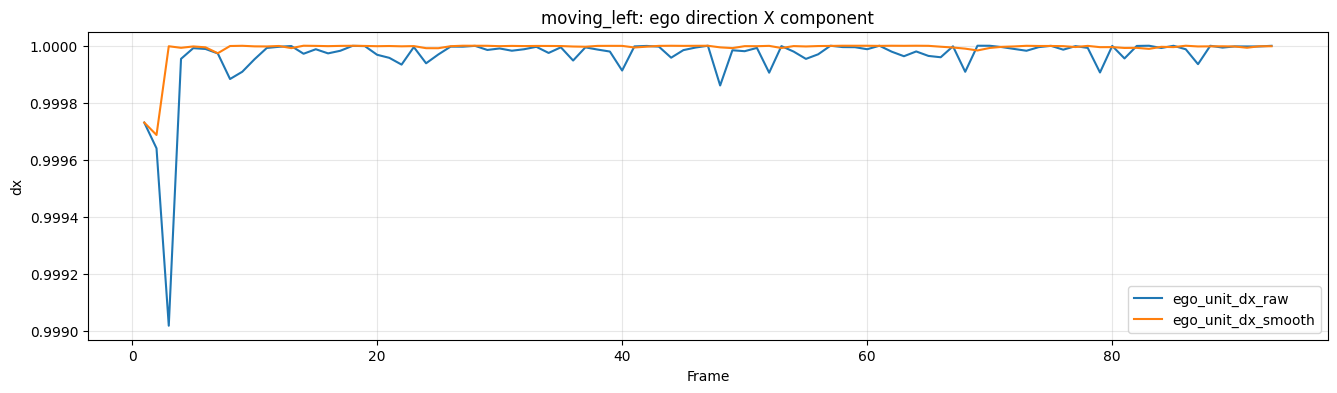

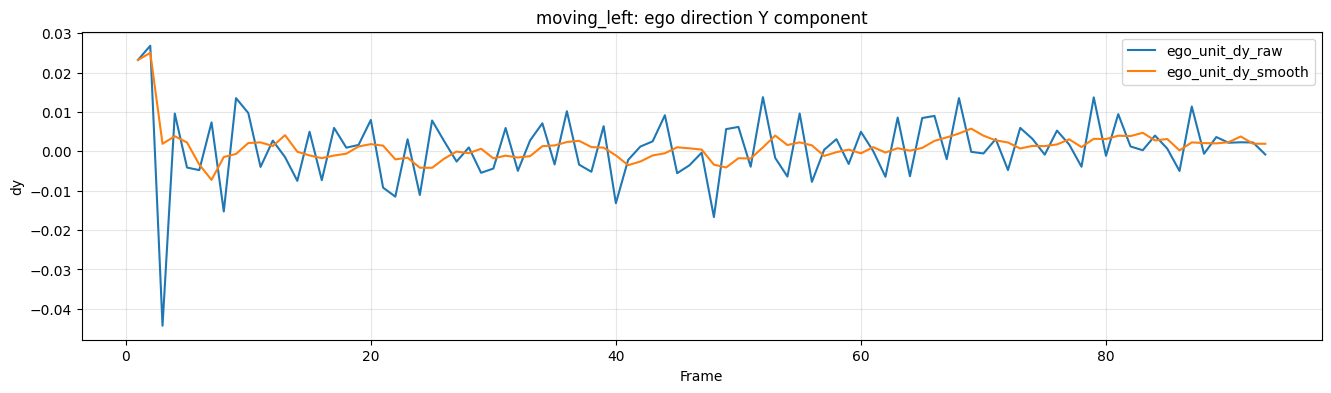

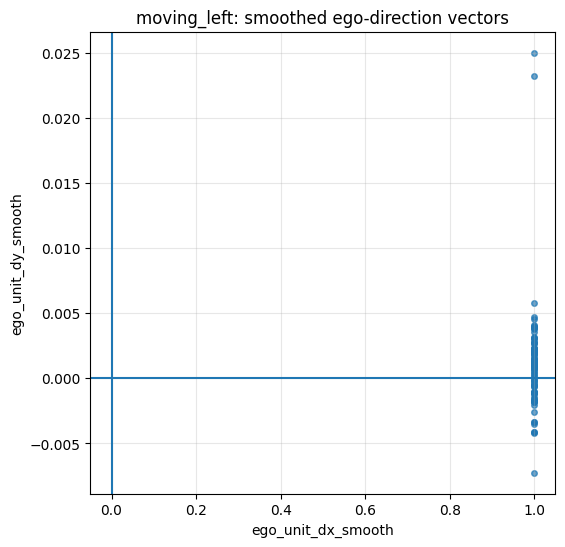

=== moving_right summary ===
Rows: 110
Valid smoothed ego-direction rows: 109


,n_background_tracks_used,mean_flow_dx_px,mean_flow_dy_px,flow_mag_px,ego_unit_dx_raw,ego_unit_dy_raw,ego_unit_dx_smooth,ego_unit_dy_smooth
count,110.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000
mean,51.054545,-1.078801,0.004727,1.078850,-0.999955,0.004326,-0.999984,0.004455
std,6.950462,0.047088,0.009292,0.047105,0.000072,0.008500,0.000021,0.003445
min,0.000000,-1.165314,-0.023254,0.825825,-1.000000,-0.020414,-1.000000,-0.002443
25%,47.000000,-1.107285,-0.001404,1.060613,-0.999995,-0.001297,-0.999998,0.001806
50%,49.500000,-1.087524,0.004242,1.087539,-0.999982,0.003863,-0.999991,0.004308
75%,56.000000,-1.060577,0.010986,1.107426,-0.999945,0.009914,-0.999979,0.006482
max,59.000000,-0.825748,0.036011,1.165315,-0.999482,0.032175,-0.999856,0.016954


Mean smoothed ego unit dx: -1.0000
Mean smoothed ego unit dy: 0.0045
Mean smoothed ego vector magnitude: 1.0000


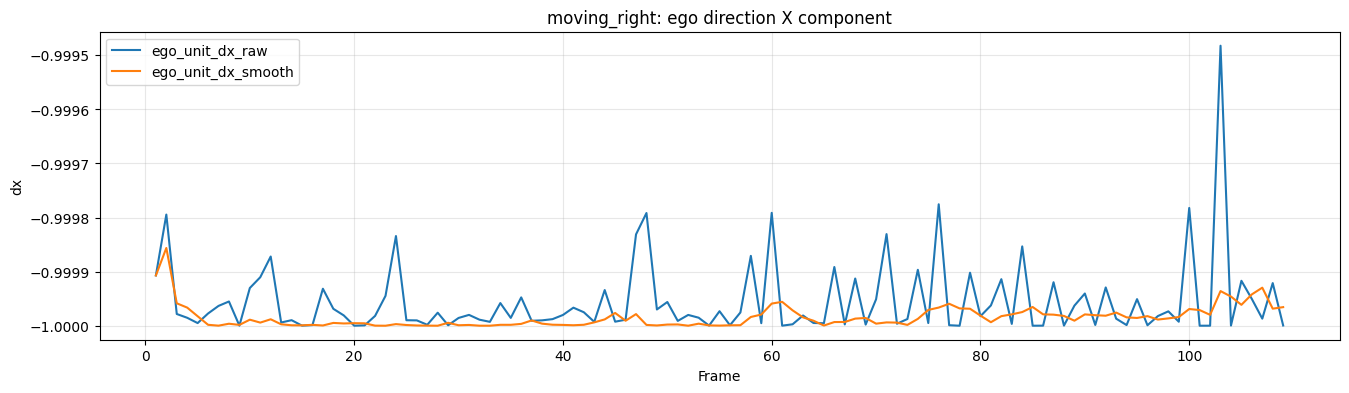

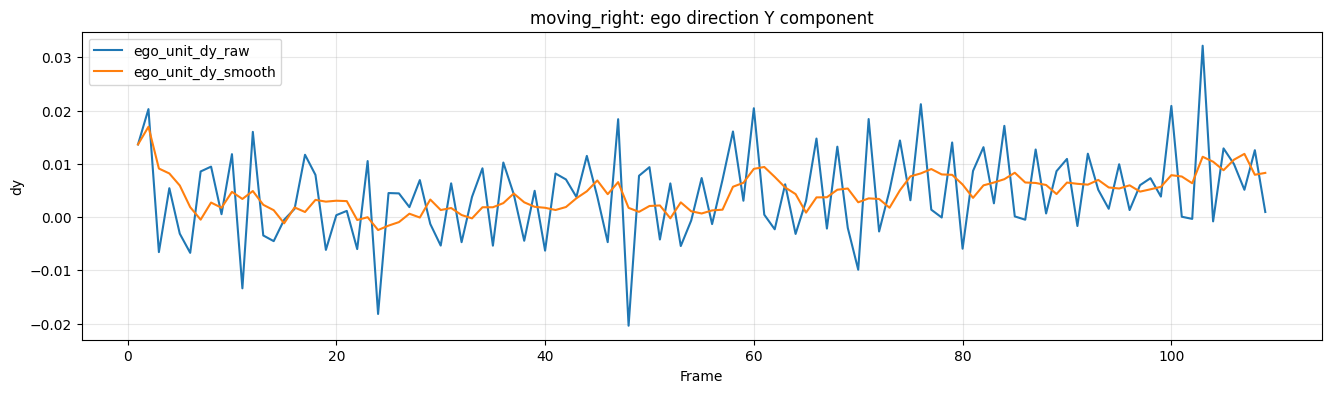

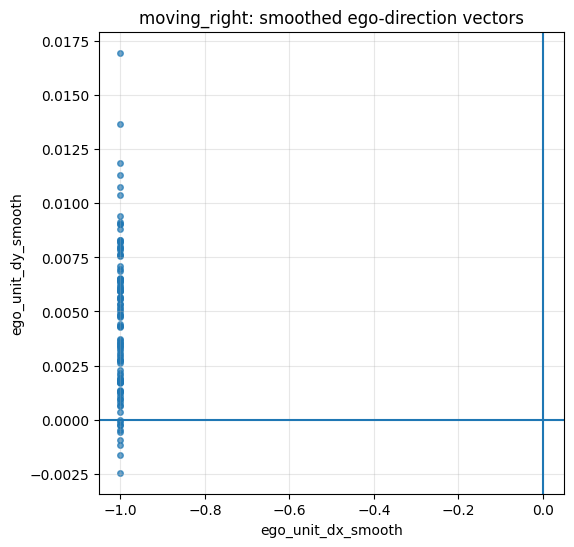

moving_left mean ego_unit_dx_smooth: 0.999990816805936
moving_right mean ego_unit_dx_smooth: -0.9999841961517061

Saved files:
moving_left debug video : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\02_ego_direction_estimation\moving_left_ego_direction_ego_debug.mp4
moving_left ego CSV     : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\02_ego_direction_estimation\moving_left_ego_direction_ego_direction.csv
moving_right debug video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\02_ego_direction_estimation\moving_right_ego_direction_ego_debug.mp4
moving_right ego CSV    : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vecto

In [9]:
# ============================================================
# Cell 9: Run ego-direction estimation on moving-camera videos
# Purpose:
# - estimate dominant background ego direction on:
#       1) moving_left
#       2) moving_right
# - inspect whether the estimated direction is stable and sensible
# - save debug videos + per-frame ego-direction CSVs
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------
# 1) Run ego-direction estimation
# -----------------------------
moving_left_ego_results = estimate_background_ego_direction(
    video_path=INPUT_VIDEO_PATHS["moving_left"],
    detector=DETECTOR,
    class_map=PHASE_CLASSES,
    output_dir=OUTPUT_DIRS["ego"],
    experiment_name="moving_left_ego_direction",
)

moving_right_ego_results = estimate_background_ego_direction(
    video_path=INPUT_VIDEO_PATHS["moving_right"],
    detector=DETECTOR,
    class_map=PHASE_CLASSES,
    output_dir=OUTPUT_DIRS["ego"],
    experiment_name="moving_right_ego_direction",
)

left_ego_df = moving_left_ego_results["ego_df"].copy()
right_ego_df = moving_right_ego_results["ego_df"].copy()

# -----------------------------
# 2) Helper for summary + plots
# -----------------------------
def summarize_and_plot_ego_df(ego_df, title_prefix="ego"):
    valid_df = ego_df.dropna(subset=["ego_unit_dx_smooth", "ego_unit_dy_smooth"]).copy()

    print(f"=== {title_prefix} summary ===")
    print("Rows:", len(ego_df))
    print("Valid smoothed ego-direction rows:", len(valid_df))

    display(
        ego_df[
            [
                "n_background_tracks_used",
                "mean_flow_dx_px",
                "mean_flow_dy_px",
                "flow_mag_px",
                "ego_unit_dx_raw",
                "ego_unit_dy_raw",
                "ego_unit_dx_smooth",
                "ego_unit_dy_smooth",
            ]
        ].describe()
    )

    if len(valid_df) == 0:
        print("No valid smoothed ego-direction rows found.")
        return

    mean_unit_dx = float(valid_df["ego_unit_dx_smooth"].mean())
    mean_unit_dy = float(valid_df["ego_unit_dy_smooth"].mean())
    mean_dir_mag = float(np.sqrt(mean_unit_dx**2 + mean_unit_dy**2))

    print(f"Mean smoothed ego unit dx: {mean_unit_dx:.4f}")
    print(f"Mean smoothed ego unit dy: {mean_unit_dy:.4f}")
    print(f"Mean smoothed ego vector magnitude: {mean_dir_mag:.4f}")

    plt.figure(figsize=(16, 4))
    plt.plot(ego_df["frame_idx"], ego_df["ego_unit_dx_raw"], label="ego_unit_dx_raw")
    plt.plot(ego_df["frame_idx"], ego_df["ego_unit_dx_smooth"], label="ego_unit_dx_smooth")
    plt.xlabel("Frame")
    plt.ylabel("dx")
    plt.title(f"{title_prefix}: ego direction X component")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(16, 4))
    plt.plot(ego_df["frame_idx"], ego_df["ego_unit_dy_raw"], label="ego_unit_dy_raw")
    plt.plot(ego_df["frame_idx"], ego_df["ego_unit_dy_smooth"], label="ego_unit_dy_smooth")
    plt.xlabel("Frame")
    plt.ylabel("dy")
    plt.title(f"{title_prefix}: ego direction Y component")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.scatter(
        valid_df["ego_unit_dx_smooth"],
        valid_df["ego_unit_dy_smooth"],
        s=16,
        alpha=0.7,
    )
    plt.axhline(0.0)
    plt.axvline(0.0)
    plt.xlabel("ego_unit_dx_smooth")
    plt.ylabel("ego_unit_dy_smooth")
    plt.title(f"{title_prefix}: smoothed ego-direction vectors")
    plt.grid(True, alpha=0.3)
    plt.show()

# -----------------------------
# 3) Inspect moving-left results
# -----------------------------
summarize_and_plot_ego_df(
    left_ego_df,
    title_prefix="moving_left",
)

# -----------------------------
# 4) Inspect moving-right results
# -----------------------------
summarize_and_plot_ego_df(
    right_ego_df,
    title_prefix="moving_right",
)

# -----------------------------
# 5) Quick sign check on horizontal direction
#    Expectation in image coordinates:
#    - camera moving left  -> dominant background flow often trends right
#    - camera moving right -> dominant background flow often trends left
#
#    We are not hard-coding that as truth yet.
#    This is just a sanity check before compensation.
# -----------------------------
left_valid = left_ego_df.dropna(subset=["ego_unit_dx_smooth"])
right_valid = right_ego_df.dropna(subset=["ego_unit_dx_smooth"])

if len(left_valid) > 0:
    print("moving_left mean ego_unit_dx_smooth:", float(left_valid["ego_unit_dx_smooth"].mean()))
if len(right_valid) > 0:
    print("moving_right mean ego_unit_dx_smooth:", float(right_valid["ego_unit_dx_smooth"].mean()))

print("\nSaved files:")
print("moving_left debug video :", moving_left_ego_results["debug_video_path"])
print("moving_left ego CSV     :", moving_left_ego_results["csv_path"])
print("moving_right debug video:", moving_right_ego_results["debug_video_path"])
print("moving_right ego CSV    :", moving_right_ego_results["csv_path"])

# -----------------------------
# 6) Keep in globals for later cells
# -----------------------------
MOVING_LEFT_EGO_RESULTS = moving_left_ego_results
MOVING_RIGHT_EGO_RESULTS = moving_right_ego_results
MOVING_LEFT_EGO_DF = left_ego_df
MOVING_RIGHT_EGO_DF = right_ego_df

print("\nCell 9 complete.")

Running moving_left_relative_velocity
Video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\camera_moving_left.mp4
Frames: 94 | Size: 800x600 | FPS: 20.00


moving_left_relative_velocity:   0%|          | 0/94 [00:00<?, ?it/s]

Saved annotated video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\03_vector_compensation\moving_left_relative_velocity_annotated.mp4
Saved observations CSV: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\03_vector_compensation\moving_left_relative_velocity_observations.csv
Running moving_right_relative_velocity
Video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\camera_moving_right.mp4
Frames: 110 | Size: 800x600 | FPS: 20.00


moving_right_relative_velocity:   0%|          | 0/110 [00:00<?, ?it/s]

Saved annotated video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\03_vector_compensation\moving_right_relative_velocity_annotated.mp4
Saved observations CSV: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\03_vector_compensation\moving_right_relative_velocity_observations.csv
=== moving_left compensated summary ===


,vx_rel_mps_smooth,vy_rel_mps_smooth,vx_cam_mps,vy_cam_mps,vx_world_mps,vy_world_mps,speed_rel_kmh_smooth,speed_world_kmh
count,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,9.140722,0.273460,-1.388875,-0.001616,7.751847,0.271844,32.923002,27.926541
std,1.378015,0.101048,0.000062,0.006045,1.377971,0.102306,4.962900,4.958764
min,1.393566,-0.030471,-1.388889,-0.034749,0.005051,-0.028464,5.020688,0.082564
25%,9.000546,0.220954,-1.388888,-0.003217,7.611659,0.221502,32.417257,27.419805
50%,9.167367,0.281069,-1.388887,-0.001386,7.778479,0.280570,33.006991,28.007896
75%,9.369478,0.327685,-1.388882,0.001480,7.980593,0.326306,33.746936,28.749696
max,11.741157,0.557166,-1.388454,0.010071,10.352269,0.561885,42.280489,37.282289


Dominant track_id: 1
Frames in dominant track: 84


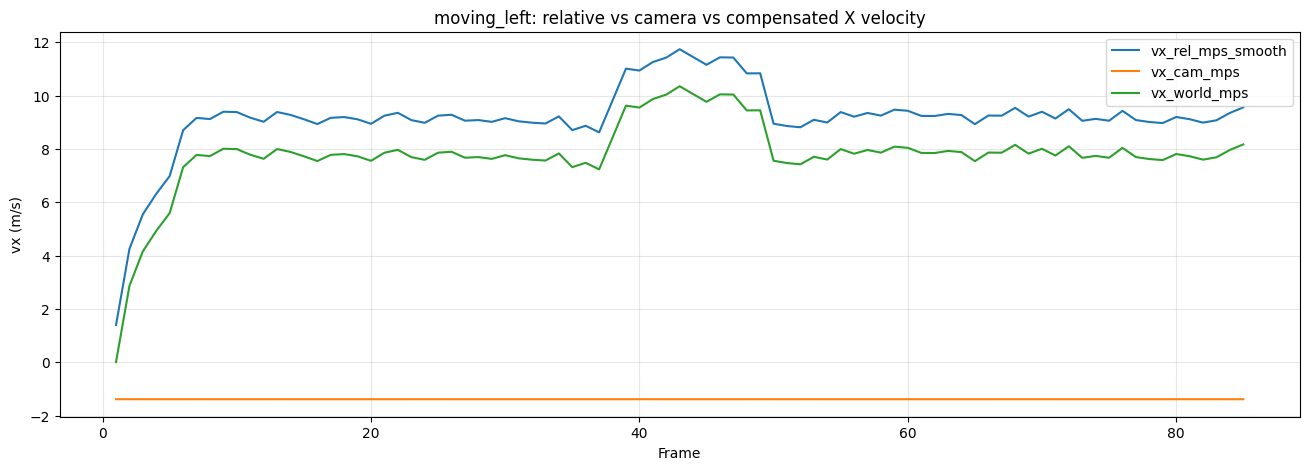

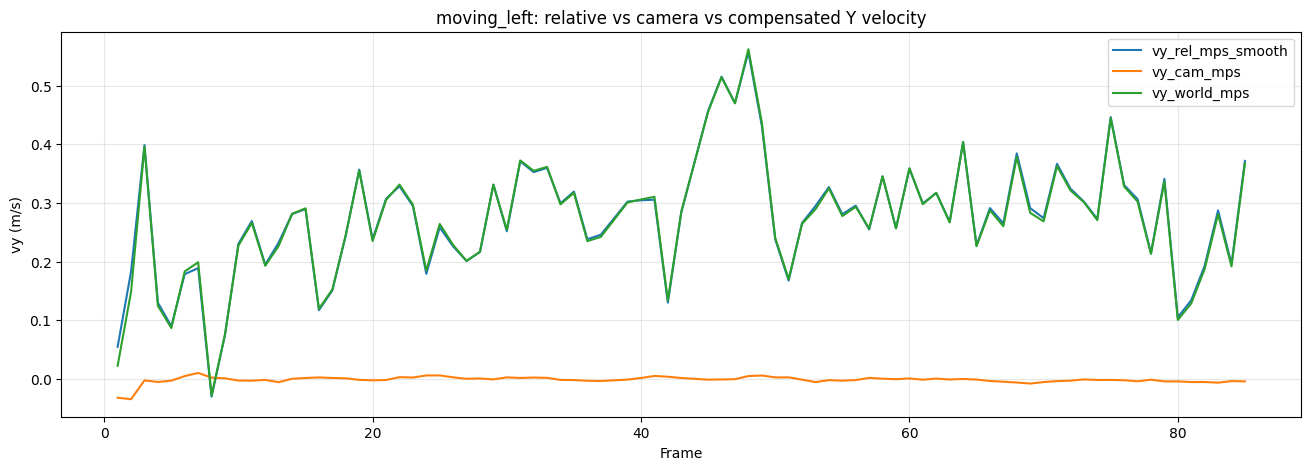

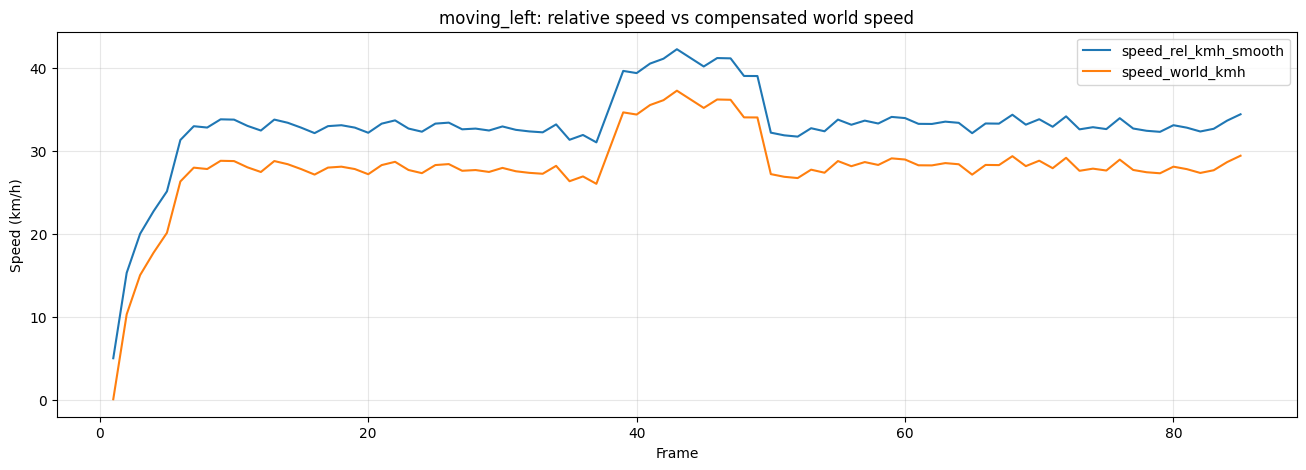

Dominant-track means:
  mean relative speed (km/h):   32.923
  mean compensated speed (km/h): 27.927
=== moving_right compensated summary ===


,vx_rel_mps_smooth,vy_rel_mps_smooth,vx_cam_mps,vy_cam_mps,vx_world_mps,vy_world_mps,speed_rel_kmh_smooth,speed_world_kmh
count,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000
mean,6.600566,0.274898,1.388867,-0.006234,7.989433,0.268664,23.860030,28.787996
std,1.338470,0.134944,0.000029,0.004820,1.338485,0.134684,4.441979,4.783826
min,-1.035202,-0.070334,1.388689,-0.023548,0.353558,-0.074109,4.071687,2.022669
25%,6.417258,0.193100,1.388860,-0.009003,7.806067,0.191570,23.109247,28.106644
50%,6.578947,0.267688,1.388876,-0.005993,7.967835,0.260565,23.720141,28.710239
75%,6.752613,0.350969,1.388887,-0.002509,8.141492,0.345008,24.339689,29.333731
max,10.932660,0.764399,1.388889,0.003394,12.321546,0.761789,39.453660,44.442261


Dominant track_id: 1
Frames in dominant track: 106


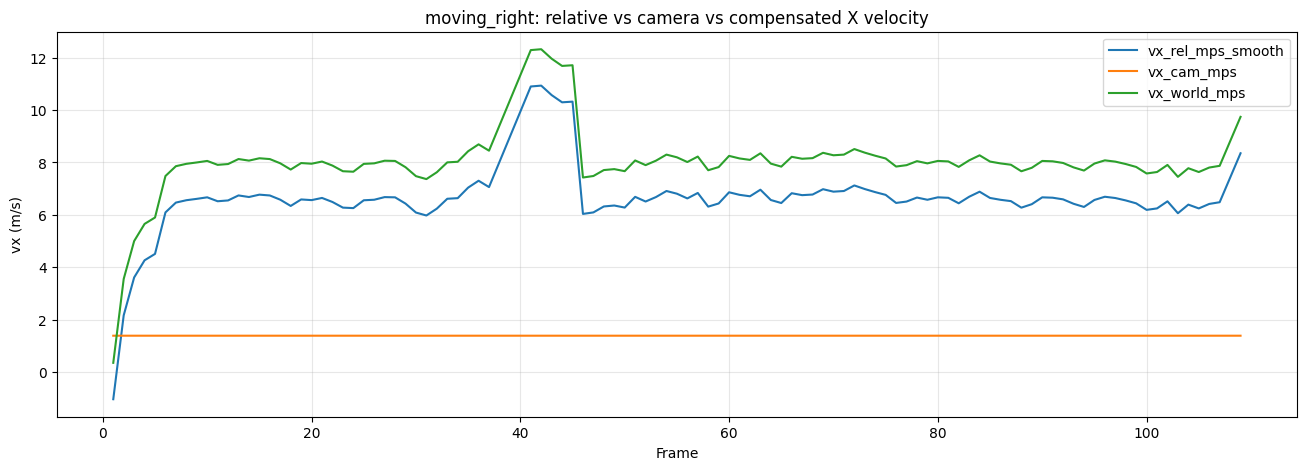

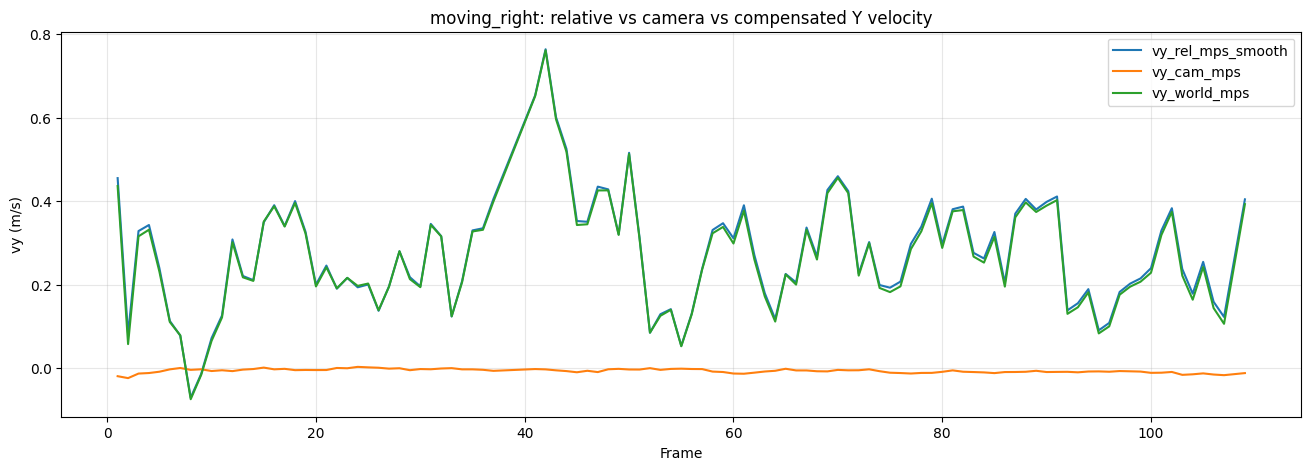

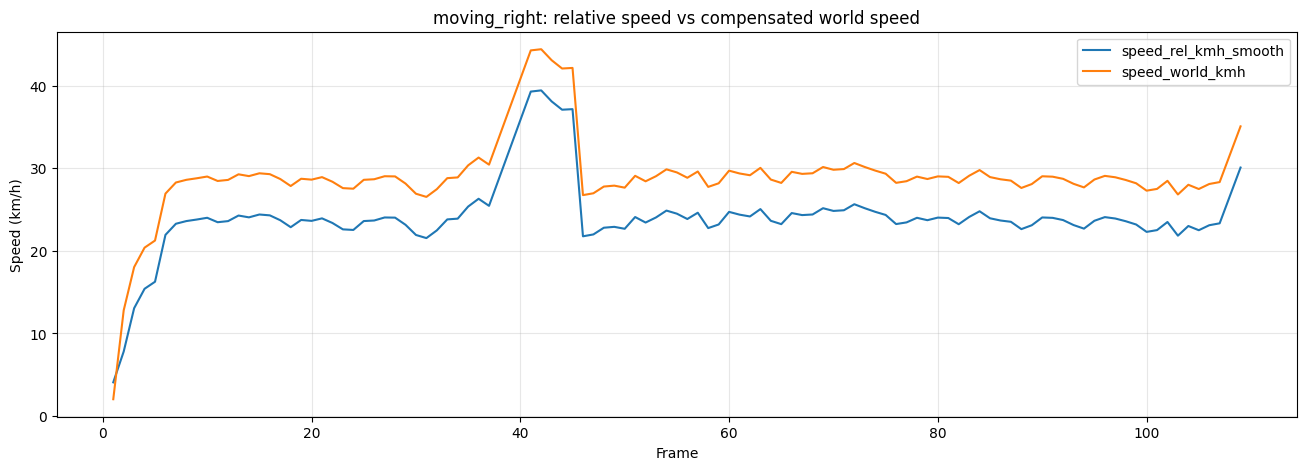

Dominant-track means:
  mean relative speed (km/h):   23.860
  mean compensated speed (km/h): 28.788
=== Comparison against still-camera baseline ===
Still-camera mean speed (km/h): 27.963
Moving-left compensated mean speed (km/h):  27.927
Moving-right compensated mean speed (km/h): 28.788

Saved files:
Moving-left relative annotated video : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\03_vector_compensation\moving_left_relative_velocity_annotated.mp4
Moving-left compensated CSV          : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\03_vector_compensation\moving_left_compensated_velocity.csv
Moving-right relative annotated video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipelin

In [10]:
# ============================================================
# Cell 10: Vector compensation on moving-camera videos
# Purpose:
# - run the same relative-velocity estimator on moving-camera videos
# - join those per-track velocities with per-frame ego-direction estimates
# - convert background-flow direction -> camera-motion direction
# - use known camera speed magnitude
# - compute compensated vehicle world velocity and final speed
#
# Key convention:
#   estimated background direction = apparent background flow
#   camera direction = negative(background direction)
#
# Therefore:
#   v_cam = camera_speed_mps * ( -ego_unit_background )
#   v_car_world = v_car_relative + v_cam
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Small helper to run baseline on a moving-camera video
# -----------------------------
moving_left_rel_results = run_relative_velocity_baseline(
    video_path=INPUT_VIDEO_PATHS["moving_left"],
    output_dir=OUTPUT_DIRS["final"],
    detector=DETECTOR,
    class_map=PHASE_CLASSES,
    experiment_name="moving_left_relative_velocity",
)

moving_right_rel_results = run_relative_velocity_baseline(
    video_path=INPUT_VIDEO_PATHS["moving_right"],
    output_dir=OUTPUT_DIRS["final"],
    detector=DETECTOR,
    class_map=PHASE_CLASSES,
    experiment_name="moving_right_relative_velocity",
)

moving_left_rel_df = moving_left_rel_results["obs_df"].copy()
moving_right_rel_df = moving_right_rel_results["obs_df"].copy()

# -----------------------------
# 2) Compensation helper
# -----------------------------
def compensate_vehicle_velocity_with_camera_motion(
    rel_df: pd.DataFrame,
    ego_df: pd.DataFrame,
    camera_speed_kmh: float,
    video_key: str,
) -> pd.DataFrame:
    """
    Inputs:
      rel_df: per-track relative vehicle velocities
      ego_df: per-frame background-flow unit vectors
      camera_speed_kmh: known camera speed magnitude

    Returns:
      rel_df joined with ego estimates and compensated world velocities
    """
    out = rel_df.copy()

    ego_cols = [
        "frame_idx",
        "ego_unit_dx_smooth",
        "ego_unit_dy_smooth",
        "n_background_tracks_used",
        "flow_mag_px",
    ]
    ego_small = ego_df[ego_cols].copy()

    out = out.merge(ego_small, on="frame_idx", how="left")

    camera_speed_mps = float(camera_speed_kmh) / 3.6
    out["camera_speed_kmh_input"] = float(camera_speed_kmh)
    out["camera_speed_mps_input"] = camera_speed_mps

    # background-flow direction -> camera-motion direction
    out["cam_unit_dx"] = -out["ego_unit_dx_smooth"]
    out["cam_unit_dy"] = -out["ego_unit_dy_smooth"]

    out["vx_cam_mps"] = camera_speed_mps * out["cam_unit_dx"]
    out["vy_cam_mps"] = camera_speed_mps * out["cam_unit_dy"]

    # compensated vehicle world velocity
    out["vx_world_mps"] = out["vx_rel_mps_smooth"] + out["vx_cam_mps"]
    out["vy_world_mps"] = out["vy_rel_mps_smooth"] + out["vy_cam_mps"]

    out["speed_world_kmh"] = 3.6 * np.sqrt(
        np.square(out["vx_world_mps"]) + np.square(out["vy_world_mps"])
    )

    out["video_key"] = video_key

    return out

# -----------------------------
# 3) Apply compensation
# -----------------------------
moving_left_comp_df = compensate_vehicle_velocity_with_camera_motion(
    rel_df=moving_left_rel_df,
    ego_df=MOVING_LEFT_EGO_DF,
    camera_speed_kmh=CAMERA_SPEED_KMH_BY_VIDEO["moving_left"],
    video_key="moving_left",
)

moving_right_comp_df = compensate_vehicle_velocity_with_camera_motion(
    rel_df=moving_right_rel_df,
    ego_df=MOVING_RIGHT_EGO_DF,
    camera_speed_kmh=CAMERA_SPEED_KMH_BY_VIDEO["moving_right"],
    video_key="moving_right",
)

# -----------------------------
# 4) Save compensated CSVs
# -----------------------------
MOVING_LEFT_COMP_CSV = OUTPUT_DIRS["final"] / "moving_left_compensated_velocity.csv"
MOVING_RIGHT_COMP_CSV = OUTPUT_DIRS["final"] / "moving_right_compensated_velocity.csv"

moving_left_comp_df.to_csv(MOVING_LEFT_COMP_CSV, index=False)
moving_right_comp_df.to_csv(MOVING_RIGHT_COMP_CSV, index=False)

# -----------------------------
# 5) Helper for dominant-track inspection
# -----------------------------
def summarize_compensation_result(
    comp_df: pd.DataFrame,
    title_prefix: str,
):
    print(f"=== {title_prefix} compensated summary ===")
    display(
        comp_df[
            [
                "vx_rel_mps_smooth",
                "vy_rel_mps_smooth",
                "vx_cam_mps",
                "vy_cam_mps",
                "vx_world_mps",
                "vy_world_mps",
                "speed_rel_kmh_smooth",
                "speed_world_kmh",
            ]
        ].describe()
    )

    dominant_track_id = int(comp_df["track_id"].value_counts().index[0])
    dom_df = (
        comp_df[comp_df["track_id"] == dominant_track_id]
        .sort_values("frame_idx")
        .reset_index(drop=True)
    )

    print(f"Dominant track_id: {dominant_track_id}")
    print(f"Frames in dominant track: {len(dom_df)}")

    plt.figure(figsize=(16, 5))
    plt.plot(dom_df["frame_idx"], dom_df["vx_rel_mps_smooth"], label="vx_rel_mps_smooth")
    plt.plot(dom_df["frame_idx"], dom_df["vx_cam_mps"], label="vx_cam_mps")
    plt.plot(dom_df["frame_idx"], dom_df["vx_world_mps"], label="vx_world_mps")
    plt.xlabel("Frame")
    plt.ylabel("vx (m/s)")
    plt.title(f"{title_prefix}: relative vs camera vs compensated X velocity")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(16, 5))
    plt.plot(dom_df["frame_idx"], dom_df["vy_rel_mps_smooth"], label="vy_rel_mps_smooth")
    plt.plot(dom_df["frame_idx"], dom_df["vy_cam_mps"], label="vy_cam_mps")
    plt.plot(dom_df["frame_idx"], dom_df["vy_world_mps"], label="vy_world_mps")
    plt.xlabel("Frame")
    plt.ylabel("vy (m/s)")
    plt.title(f"{title_prefix}: relative vs camera vs compensated Y velocity")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(16, 5))
    plt.plot(dom_df["frame_idx"], dom_df["speed_rel_kmh_smooth"], label="speed_rel_kmh_smooth")
    plt.plot(dom_df["frame_idx"], dom_df["speed_world_kmh"], label="speed_world_kmh")
    plt.xlabel("Frame")
    plt.ylabel("Speed (km/h)")
    plt.title(f"{title_prefix}: relative speed vs compensated world speed")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    valid_rel = dom_df["speed_rel_kmh_smooth"].dropna()
    valid_world = dom_df["speed_world_kmh"].dropna()

    print("Dominant-track means:")
    if len(valid_rel) > 0:
        print(f"  mean relative speed (km/h):   {valid_rel.mean():.3f}")
    if len(valid_world) > 0:
        print(f"  mean compensated speed (km/h): {valid_world.mean():.3f}")

    return dominant_track_id, dom_df

# -----------------------------
# 6) Inspect moving-left and moving-right compensation
# -----------------------------
moving_left_dom_tid, moving_left_dom_df = summarize_compensation_result(
    moving_left_comp_df,
    title_prefix="moving_left",
)

moving_right_dom_tid, moving_right_dom_df = summarize_compensation_result(
    moving_right_comp_df,
    title_prefix="moving_right",
)

# -----------------------------
# 7) Compare against still-camera baseline
# -----------------------------
still_dom_df = STILL_BASELINE_DOMINANT_DF.copy()
still_valid = still_dom_df["speed_rel_kmh_smooth"].dropna()

print("=== Comparison against still-camera baseline ===")
if len(still_valid) > 0:
    print(f"Still-camera mean speed (km/h): {still_valid.mean():.3f}")

left_valid_world = moving_left_dom_df["speed_world_kmh"].dropna()
right_valid_world = moving_right_dom_df["speed_world_kmh"].dropna()

if len(left_valid_world) > 0:
    print(f"Moving-left compensated mean speed (km/h):  {left_valid_world.mean():.3f}")
if len(right_valid_world) > 0:
    print(f"Moving-right compensated mean speed (km/h): {right_valid_world.mean():.3f}")

print("\nSaved files:")
print("Moving-left relative annotated video :", moving_left_rel_results["output_video_path"])
print("Moving-left compensated CSV          :", MOVING_LEFT_COMP_CSV)
print("Moving-right relative annotated video:", moving_right_rel_results["output_video_path"])
print("Moving-right compensated CSV         :", MOVING_RIGHT_COMP_CSV)

# -----------------------------
# 8) Keep artifacts for later cells
# -----------------------------
MOVING_LEFT_REL_RESULTS = moving_left_rel_results
MOVING_RIGHT_REL_RESULTS = moving_right_rel_results
MOVING_LEFT_REL_DF = moving_left_rel_df
MOVING_RIGHT_REL_DF = moving_right_rel_df
MOVING_LEFT_COMP_DF = moving_left_comp_df
MOVING_RIGHT_COMP_DF = moving_right_comp_df
MOVING_LEFT_DOMINANT_TRACK_ID = moving_left_dom_tid
MOVING_RIGHT_DOMINANT_TRACK_ID = moving_right_dom_tid
MOVING_LEFT_DOMINANT_DF = moving_left_dom_df
MOVING_RIGHT_DOMINANT_DF = moving_right_dom_df

print("\nCell 10 complete.")

=== Dominant-track pre-compensation summary ===


,video_key,n_rows,mean_bbox_width_px,mean_bbox_height_px,mean_mpp_x,mean_mpp_y,mean_mpp_geom,mean_rep_x,mean_rep_y,mean_vx_rel_mps_smooth,mean_vy_rel_mps_smooth,mean_speed_rel_kmh_smooth
0,still,99,83.026272,37.305002,0.024749,0.136769,0.058161,403.067235,338.718892,7.759677,0.272020,27.963293
1,moving_left,84,83.385251,37.460671,0.024642,0.136196,0.057911,403.154939,337.065548,9.140722,0.273460,32.923002
2,moving_right,106,82.312759,37.302469,0.024963,0.136794,0.058421,407.033592,339.833626,6.600566,0.274898,23.860030


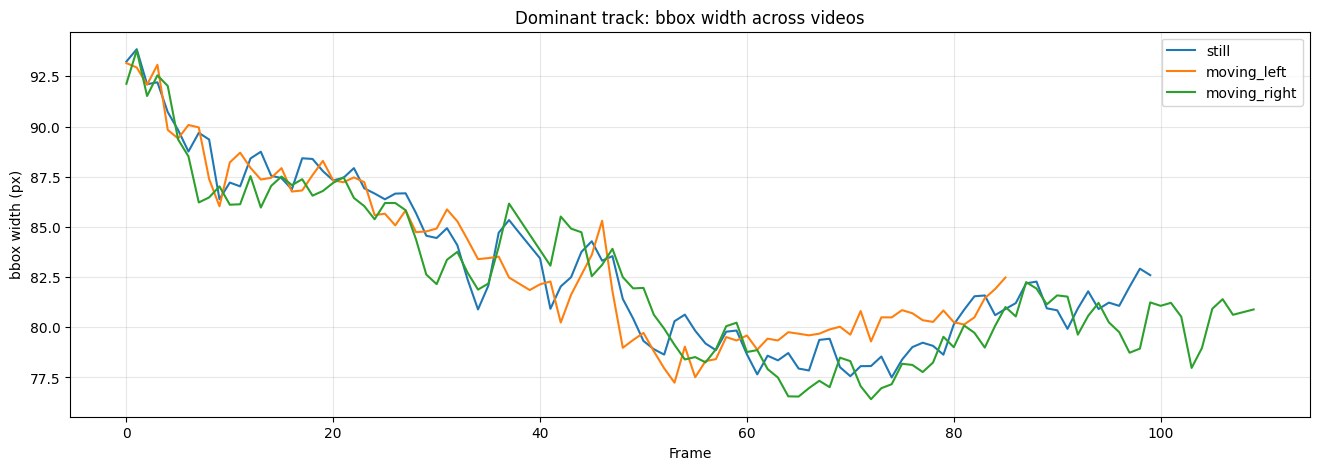

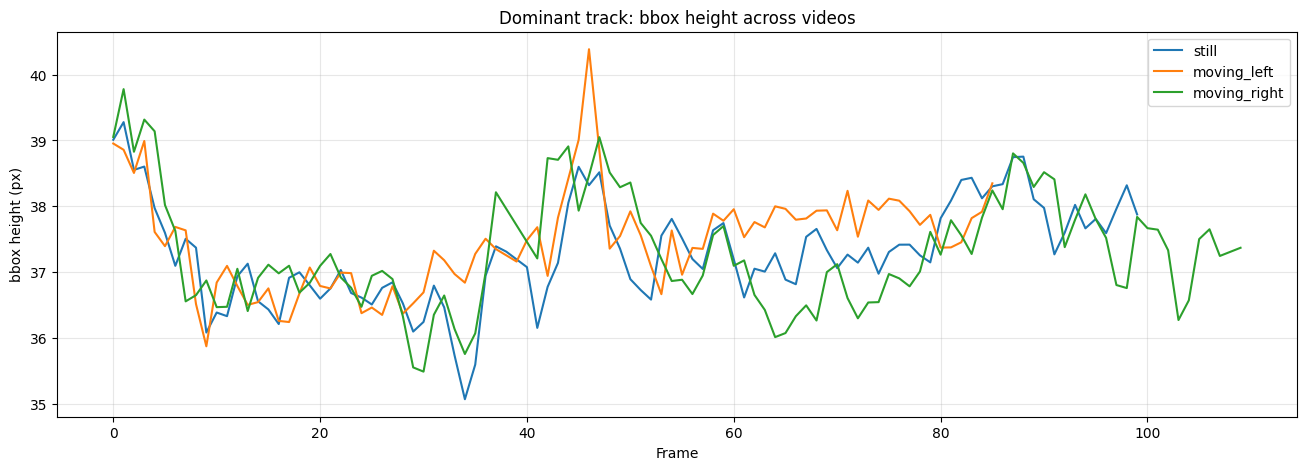

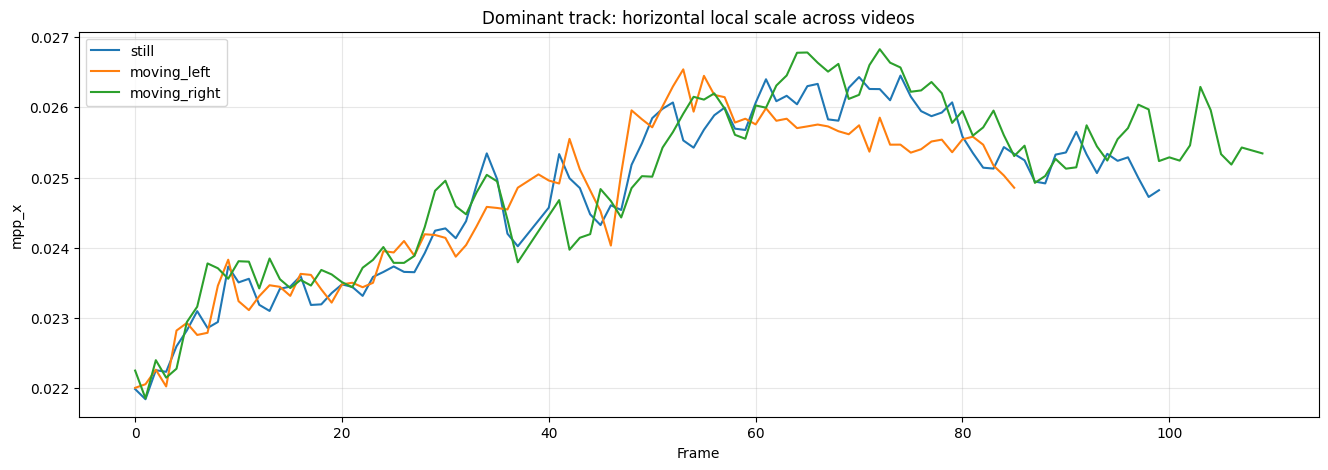

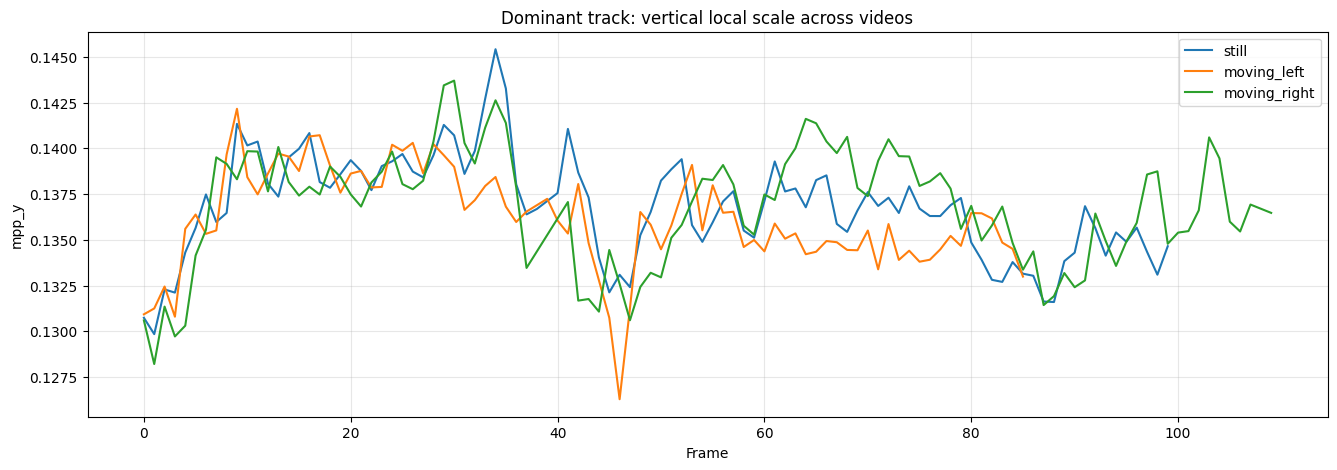

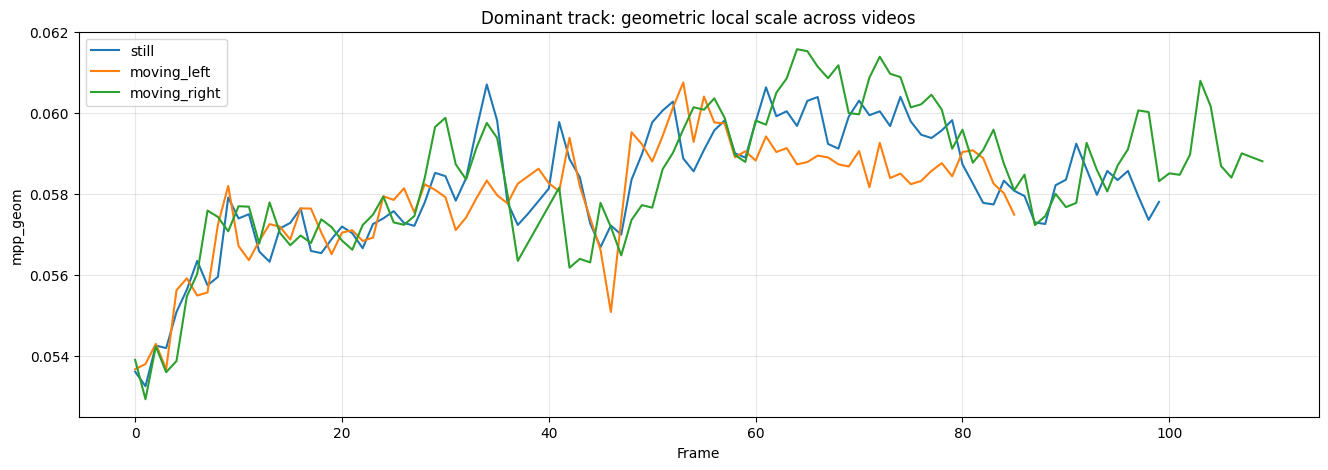

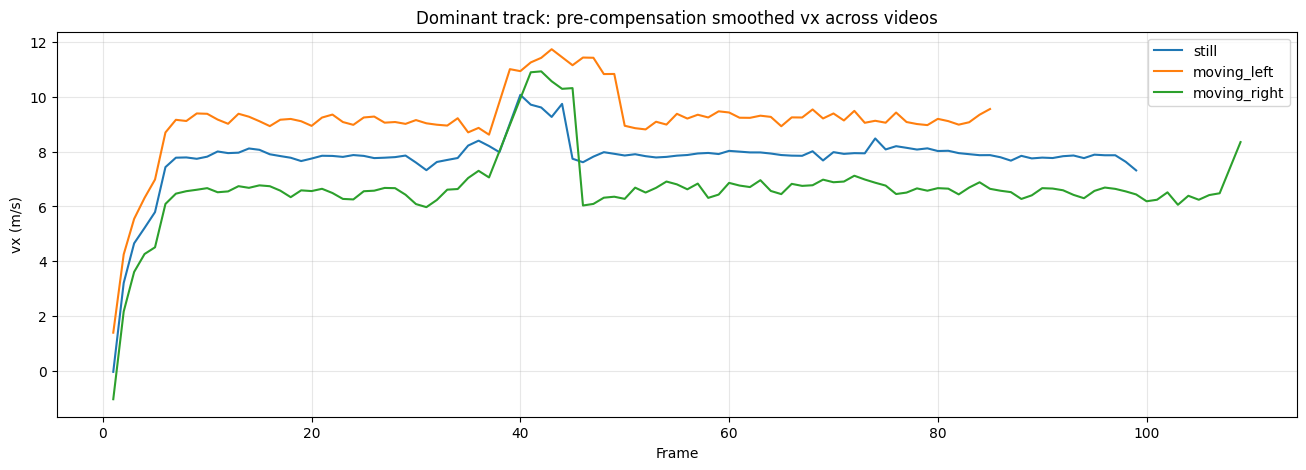

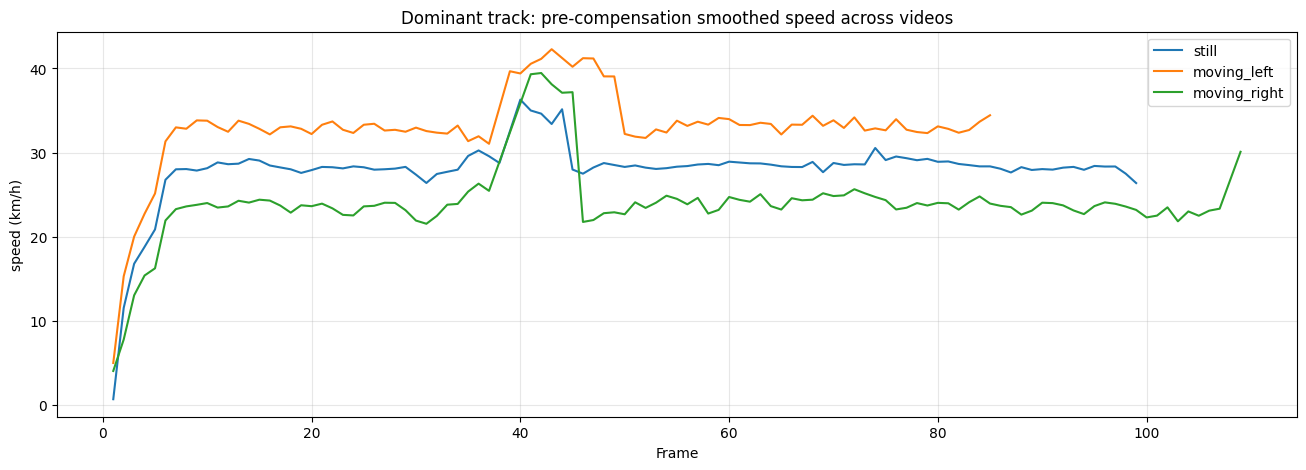

=== Original shared-scale vs anisotropic relative estimator ===


,video_key,orig_mean_vx_mps,aniso_mean_vx_mps,orig_mean_vy_mps,aniso_mean_vy_mps,orig_mean_speed_kmh,aniso_mean_speed_kmh
0,still,7.759677,4.959227,0.272020,0.956759,27.963293,18.257291
1,moving_left,9.140722,5.844050,0.273460,0.961770,32.923002,21.352020
2,moving_right,6.600566,4.234342,0.274898,0.962983,23.860030,15.771564


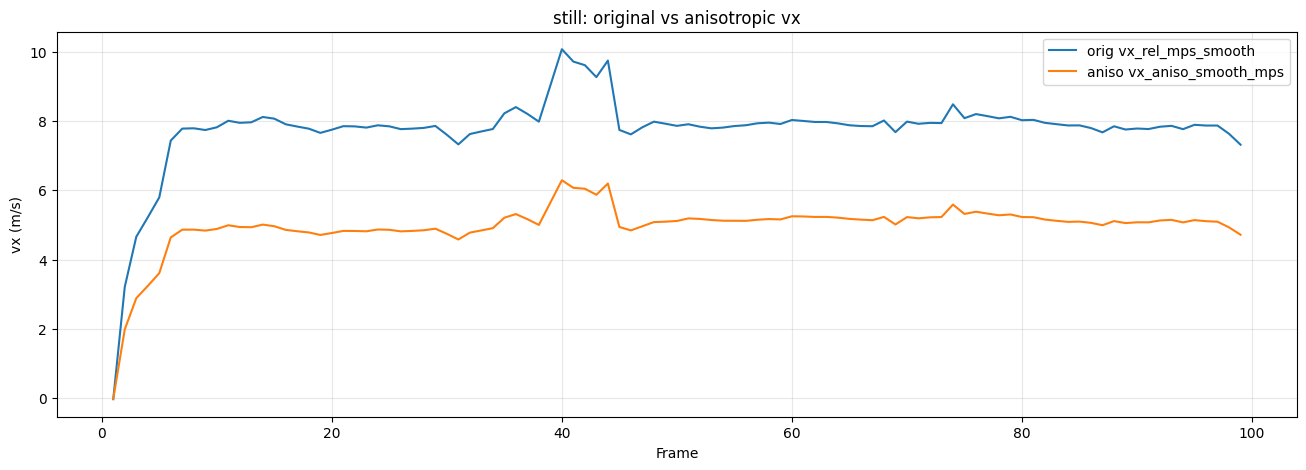

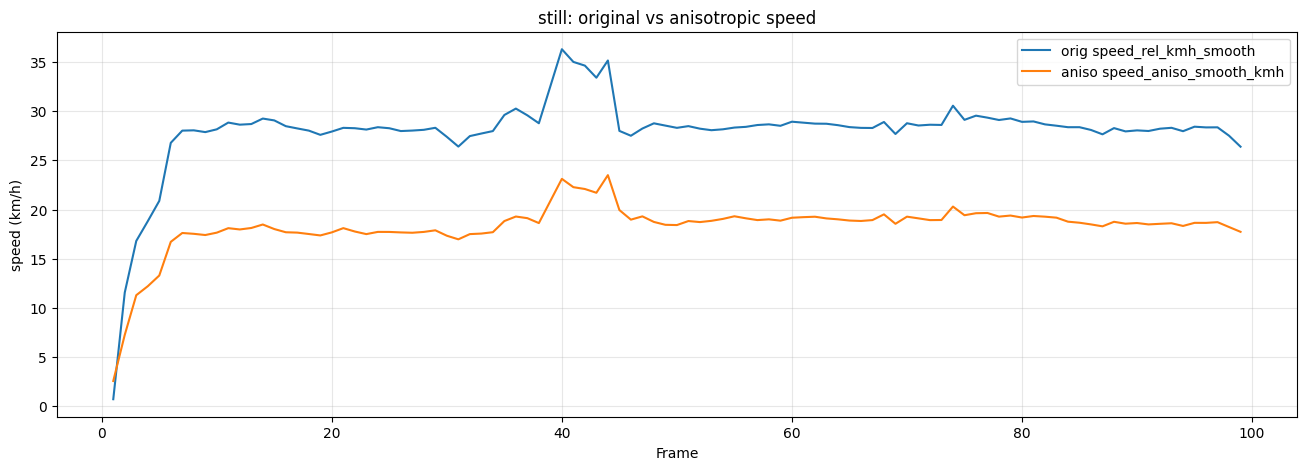

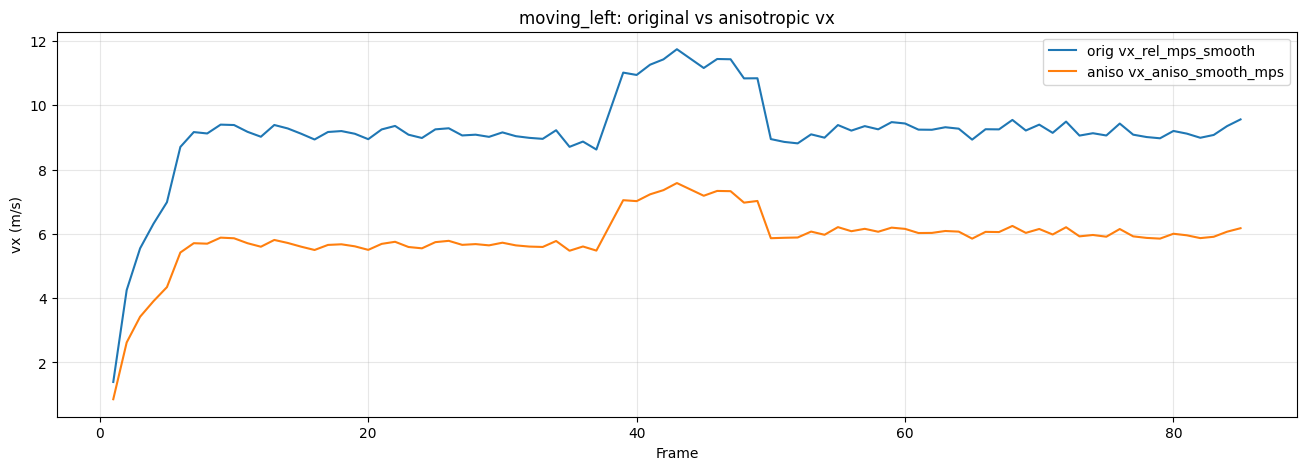

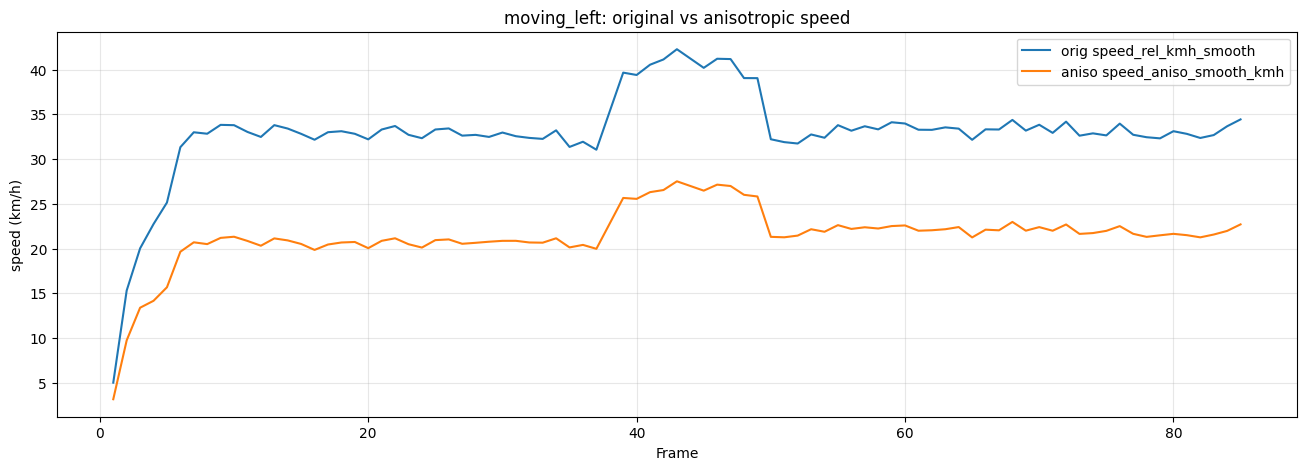

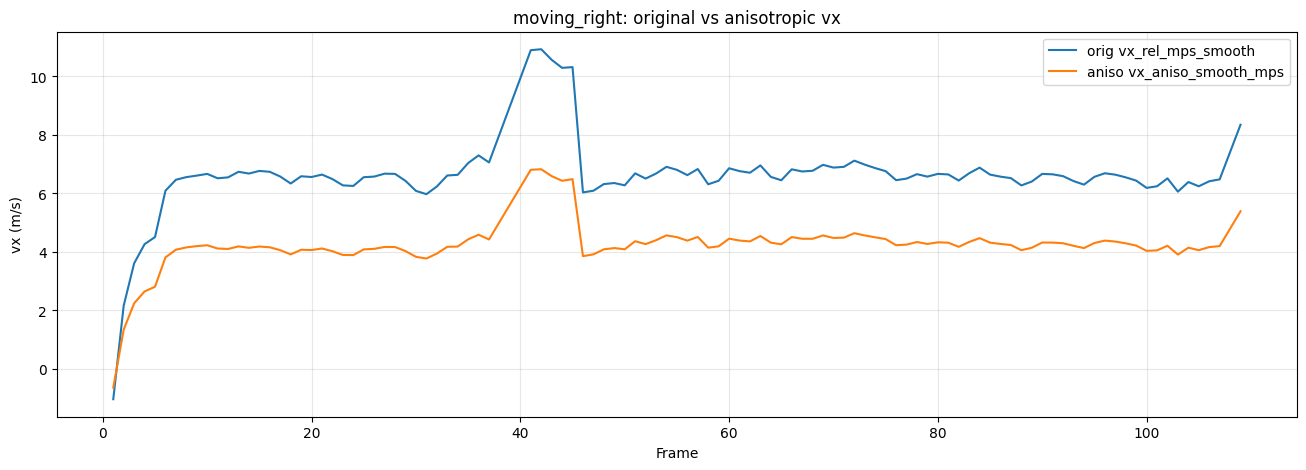

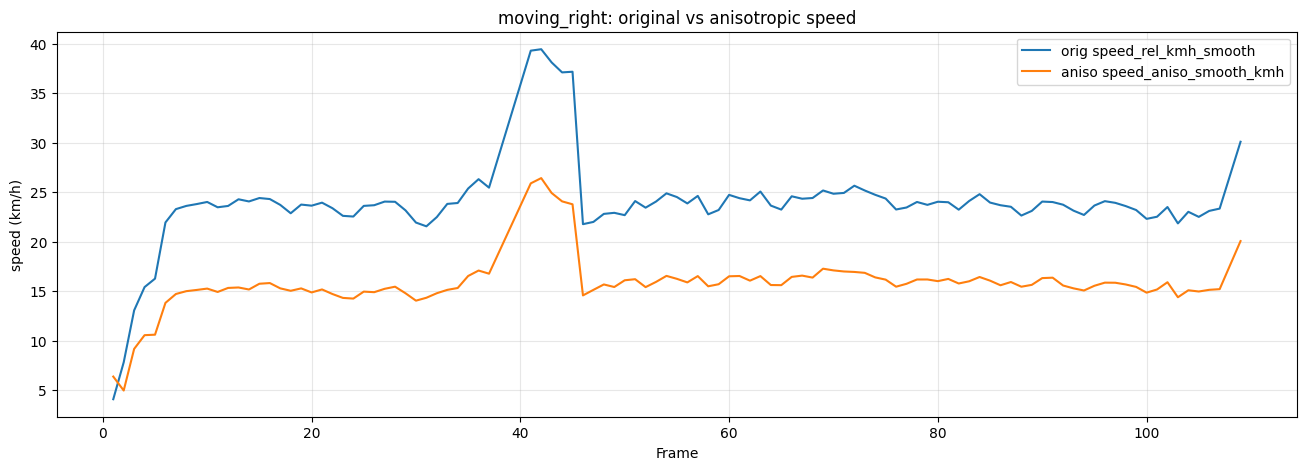

Cell 11 complete.


In [12]:
# ============================================================
# Cell 11: Diagnose left/right asymmetry in the relative estimator
# Purpose:
# - compare still vs moving-left vs moving-right BEFORE compensation
# - determine whether asymmetry enters through:
#     1) bbox geometry
#     2) local scale (mpp)
#     3) representative-point x motion
# - test a key hypothesis:
#     use mpp_x for vx and mpp_y for vy instead of mpp_geom for both
#
# Main idea:
# - current relative estimator uses one shared scalar scale (mpp_geom)
# - but motion here is dominated by horizontal vx
# - so an anisotropic estimator may reduce left/right bias
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Gather the three pre-compensation dataframes
# -----------------------------
still_df = STILL_BASELINE_OBS_DF.copy()
left_df = MOVING_LEFT_REL_DF.copy()
right_df = MOVING_RIGHT_REL_DF.copy()

still_df["video_key"] = "still"
left_df["video_key"] = "moving_left"
right_df["video_key"] = "moving_right"

all_rel_df = pd.concat([still_df, left_df, right_df], ignore_index=True)

# focus on dominant track from each run
still_dom = STILL_BASELINE_DOMINANT_DF.copy()
left_dom = MOVING_LEFT_REL_DF[MOVING_LEFT_REL_DF["track_id"] == MOVING_LEFT_DOMINANT_TRACK_ID].sort_values("frame_idx").reset_index(drop=True).copy()
right_dom = MOVING_RIGHT_REL_DF[MOVING_RIGHT_REL_DF["track_id"] == MOVING_RIGHT_DOMINANT_TRACK_ID].sort_values("frame_idx").reset_index(drop=True).reset_index(drop=True).copy()

still_dom["video_key"] = "still"
left_dom["video_key"] = "moving_left"
right_dom["video_key"] = "moving_right"

# -----------------------------
# 2) Summary table for dominant tracks
# -----------------------------
summary_rows = []
for name, df in [("still", still_dom), ("moving_left", left_dom), ("moving_right", right_dom)]:
    row = {
        "video_key": name,
        "n_rows": len(df),
        "mean_bbox_width_px": df["bbox_width_px"].mean(),
        "mean_bbox_height_px": df["bbox_height_px"].mean(),
        "mean_mpp_x": df["mpp_x"].mean(),
        "mean_mpp_y": df["mpp_y"].mean(),
        "mean_mpp_geom": df["mpp_geom"].mean(),
        "mean_rep_x": df["rep_image_x"].mean(),
        "mean_rep_y": df["rep_image_y"].mean(),
        "mean_vx_rel_mps_smooth": df["vx_rel_mps_smooth"].mean(),
        "mean_vy_rel_mps_smooth": df["vy_rel_mps_smooth"].mean(),
        "mean_speed_rel_kmh_smooth": df["speed_rel_kmh_smooth"].mean(),
    }
    summary_rows.append(row)

dominant_summary_df = pd.DataFrame(summary_rows)
print("=== Dominant-track pre-compensation summary ===")
display(dominant_summary_df)

# -----------------------------
# 3) Plot core quantities to localize asymmetry
# -----------------------------
def plot_three_way(series_name, ylabel, title):
    plt.figure(figsize=(16, 5))
    plt.plot(still_dom["frame_idx"], still_dom[series_name], label="still")
    plt.plot(left_dom["frame_idx"], left_dom[series_name], label="moving_left")
    plt.plot(right_dom["frame_idx"], right_dom[series_name], label="moving_right")
    plt.xlabel("Frame")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_three_way("bbox_width_px", "bbox width (px)", "Dominant track: bbox width across videos")
plot_three_way("bbox_height_px", "bbox height (px)", "Dominant track: bbox height across videos")
plot_three_way("mpp_x", "mpp_x", "Dominant track: horizontal local scale across videos")
plot_three_way("mpp_y", "mpp_y", "Dominant track: vertical local scale across videos")
plot_three_way("mpp_geom", "mpp_geom", "Dominant track: geometric local scale across videos")
plot_three_way("vx_rel_mps_smooth", "vx (m/s)", "Dominant track: pre-compensation smoothed vx across videos")
plot_three_way("speed_rel_kmh_smooth", "speed (km/h)", "Dominant track: pre-compensation smoothed speed across videos")

# -----------------------------
# 4) Recompute anisotropic relative velocities
#    Hypothesis:
#    - vx should use mpp_x
#    - vy should use mpp_y
#    instead of using one shared mpp_geom scale for both
# -----------------------------
def recompute_anisotropic_velocity(df: pd.DataFrame, fps: float = 30.0, vel_window: int = 5):
    df = df.sort_values(["track_id", "frame_idx"]).copy()

    out_parts = []
    for tid, g in df.groupby("track_id", sort=False):
        g = g.sort_values("frame_idx").copy().reset_index(drop=True)

        rep_x = g["rep_image_x"].astype(float).to_numpy()
        rep_y = g["rep_image_y"].astype(float).to_numpy()
        mpp_x = g["mpp_x"].astype(float).to_numpy()
        mpp_y = g["mpp_y"].astype(float).to_numpy()

        dx_px = np.full(len(g), np.nan, dtype=np.float64)
        dy_px = np.full(len(g), np.nan, dtype=np.float64)
        dx_px[1:] = rep_x[1:] - rep_x[:-1]
        dy_px[1:] = rep_y[1:] - rep_y[:-1]

        # use pairwise-averaged directional scale
        mpp_x_pair = np.full(len(g), np.nan, dtype=np.float64)
        mpp_y_pair = np.full(len(g), np.nan, dtype=np.float64)
        mpp_x_pair[1:] = 0.5 * (mpp_x[1:] + mpp_x[:-1])
        mpp_y_pair[1:] = 0.5 * (mpp_y[1:] + mpp_y[:-1])

        dt = 1.0 / float(fps)

        vx_aniso_raw = (dx_px * mpp_x_pair) / dt
        vy_aniso_raw = (dy_px * mpp_y_pair) / dt
        speed_aniso_raw = 3.6 * np.sqrt(np.square(vx_aniso_raw) + np.square(vy_aniso_raw))

        def rolling_mean_nan(arr, window=5):
            s = pd.Series(arr)
            return s.rolling(window=window, min_periods=1).mean().to_numpy()

        vx_aniso_smooth = rolling_mean_nan(vx_aniso_raw, window=vel_window)
        vy_aniso_smooth = rolling_mean_nan(vy_aniso_raw, window=vel_window)
        speed_aniso_smooth = 3.6 * np.sqrt(np.square(vx_aniso_smooth) + np.square(vy_aniso_smooth))

        g["dx_px"] = dx_px
        g["dy_px"] = dy_px
        g["vx_aniso_raw_mps"] = vx_aniso_raw
        g["vy_aniso_raw_mps"] = vy_aniso_raw
        g["speed_aniso_raw_kmh"] = speed_aniso_raw
        g["vx_aniso_smooth_mps"] = vx_aniso_smooth
        g["vy_aniso_smooth_mps"] = vy_aniso_smooth
        g["speed_aniso_smooth_kmh"] = speed_aniso_smooth

        out_parts.append(g)

    return pd.concat(out_parts, ignore_index=True)

still_aniso = recompute_anisotropic_velocity(still_df, fps=30.0, vel_window=VEL_WINDOW)
left_aniso = recompute_anisotropic_velocity(left_df, fps=30.0, vel_window=VEL_WINDOW)
right_aniso = recompute_anisotropic_velocity(right_df, fps=30.0, vel_window=VEL_WINDOW)

still_aniso_dom = still_aniso[still_aniso["track_id"] == STILL_BASELINE_DOMINANT_TRACK_ID].sort_values("frame_idx").reset_index(drop=True)
left_aniso_dom = left_aniso[left_aniso["track_id"] == MOVING_LEFT_DOMINANT_TRACK_ID].sort_values("frame_idx").reset_index(drop=True)
right_aniso_dom = right_aniso[right_aniso["track_id"] == MOVING_RIGHT_DOMINANT_TRACK_ID].sort_values("frame_idx").reset_index(drop=True)

# -----------------------------
# 5) Compare original shared-scale vs anisotropic estimator
# -----------------------------
comparison_rows = []
for name, orig_df, aniso_df in [
    ("still", still_dom, still_aniso_dom),
    ("moving_left", left_dom, left_aniso_dom),
    ("moving_right", right_dom, right_aniso_dom),
]:
    comparison_rows.append({
        "video_key": name,
        "orig_mean_vx_mps": orig_df["vx_rel_mps_smooth"].mean(),
        "aniso_mean_vx_mps": aniso_df["vx_aniso_smooth_mps"].mean(),
        "orig_mean_vy_mps": orig_df["vy_rel_mps_smooth"].mean(),
        "aniso_mean_vy_mps": aniso_df["vy_aniso_smooth_mps"].mean(),
        "orig_mean_speed_kmh": orig_df["speed_rel_kmh_smooth"].mean(),
        "aniso_mean_speed_kmh": aniso_df["speed_aniso_smooth_kmh"].mean(),
    })

comparison_df = pd.DataFrame(comparison_rows)
print("=== Original shared-scale vs anisotropic relative estimator ===")
display(comparison_df)

# -----------------------------
# 6) Plot anisotropic speed against original speed
# -----------------------------
def plot_orig_vs_aniso(orig_df, aniso_df, title_prefix):
    plt.figure(figsize=(16, 5))
    plt.plot(orig_df["frame_idx"], orig_df["vx_rel_mps_smooth"], label="orig vx_rel_mps_smooth")
    plt.plot(aniso_df["frame_idx"], aniso_df["vx_aniso_smooth_mps"], label="aniso vx_aniso_smooth_mps")
    plt.xlabel("Frame")
    plt.ylabel("vx (m/s)")
    plt.title(f"{title_prefix}: original vs anisotropic vx")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(16, 5))
    plt.plot(orig_df["frame_idx"], orig_df["speed_rel_kmh_smooth"], label="orig speed_rel_kmh_smooth")
    plt.plot(aniso_df["frame_idx"], aniso_df["speed_aniso_smooth_kmh"], label="aniso speed_aniso_smooth_kmh")
    plt.xlabel("Frame")
    plt.ylabel("speed (km/h)")
    plt.title(f"{title_prefix}: original vs anisotropic speed")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_orig_vs_aniso(still_dom, still_aniso_dom, "still")
plot_orig_vs_aniso(left_dom, left_aniso_dom, "moving_left")
plot_orig_vs_aniso(right_dom, right_aniso_dom, "moving_right")

# -----------------------------
# 7) Save diagnostic artifacts for later use
# -----------------------------
CELL11_DIAGNOSTIC_SUMMARY_DF = dominant_summary_df
CELL11_ORIG_VS_ANISO_DF = comparison_df

STILL_ANISO_DF = still_aniso
MOVING_LEFT_ANISO_DF = left_aniso
MOVING_RIGHT_ANISO_DF = right_aniso

STILL_ANISO_DOM_DF = still_aniso_dom
MOVING_LEFT_ANISO_DOM_DF = left_aniso_dom
MOVING_RIGHT_ANISO_DOM_DF = right_aniso_dom

print("Cell 11 complete.")

=== Ego-flow residual relative estimator summary ===


,video_key,mean_dx_obj_px,mean_dx_ego_px,mean_dx_residual_px,mean_vx_residual_smooth_mps,mean_vy_residual_smooth_mps,mean_speed_residual_smooth_kmh
0,still,6.755453,0.000000,6.755453,11.639516,0.408031,41.944940
1,moving_left,8.026532,1.072677,6.953854,11.853679,0.408184,42.701555
2,moving_right,5.783158,-1.078360,6.861518,11.779321,0.403674,42.466171


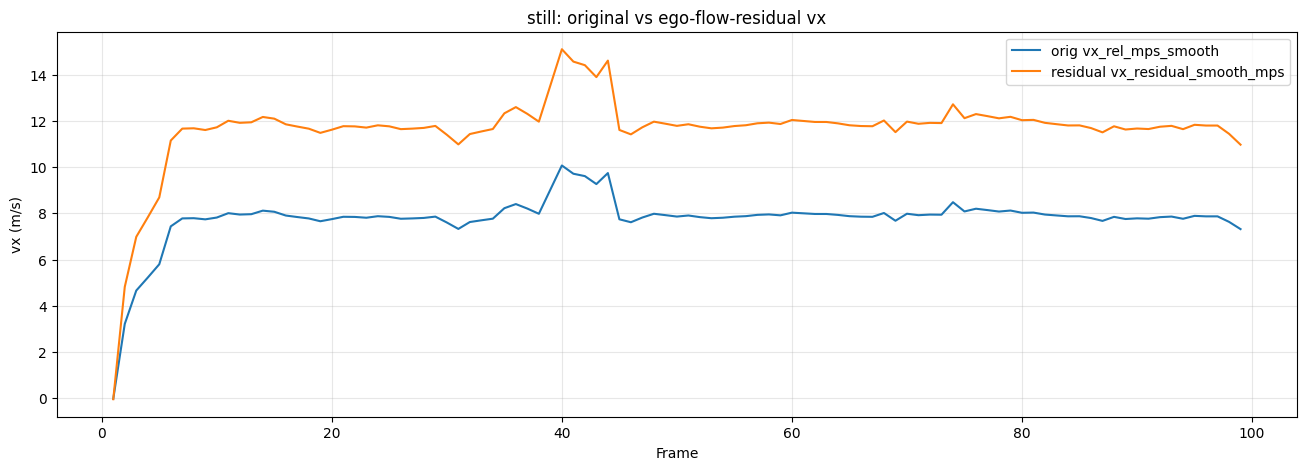

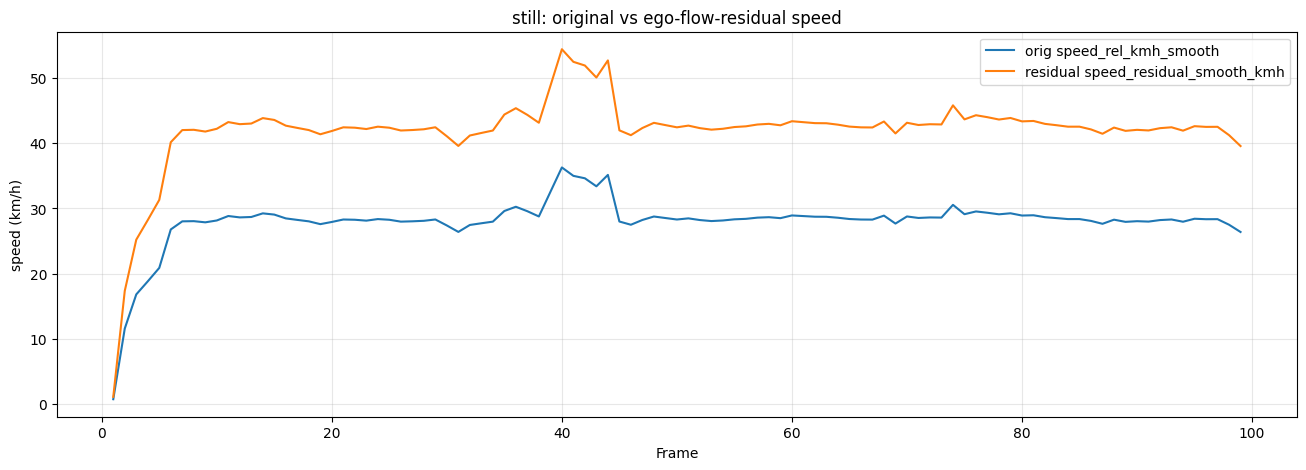

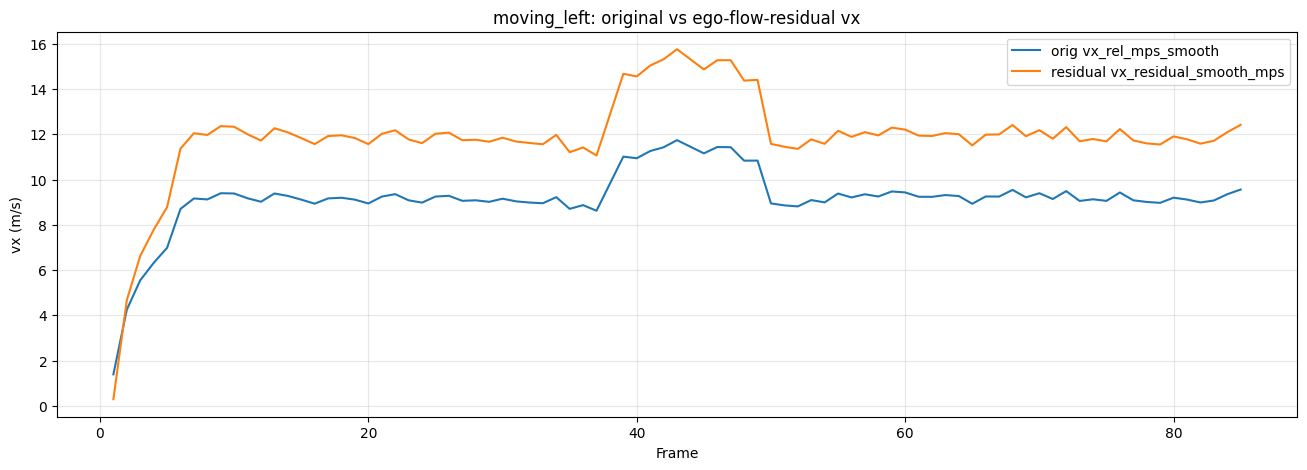

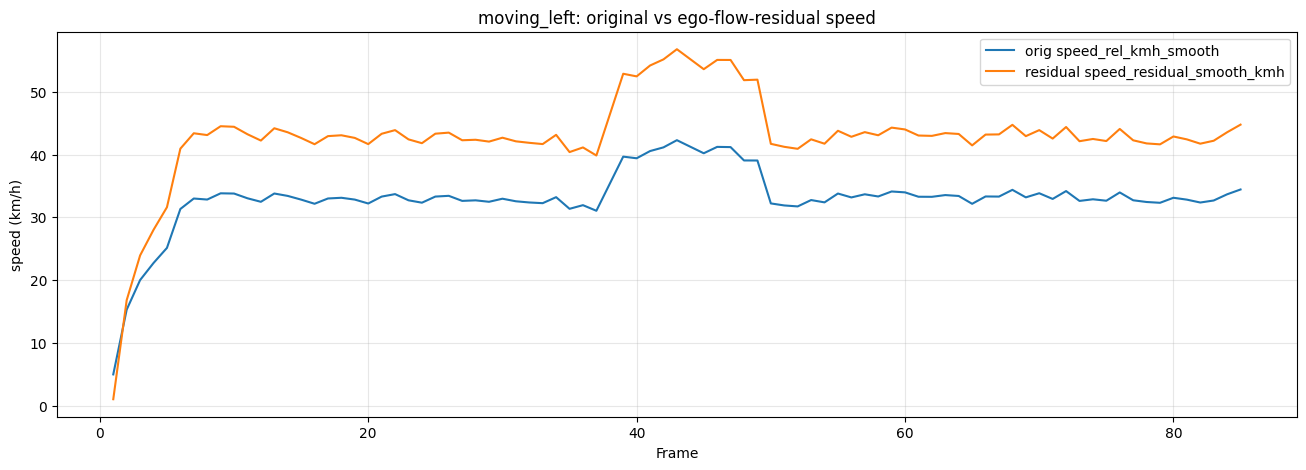

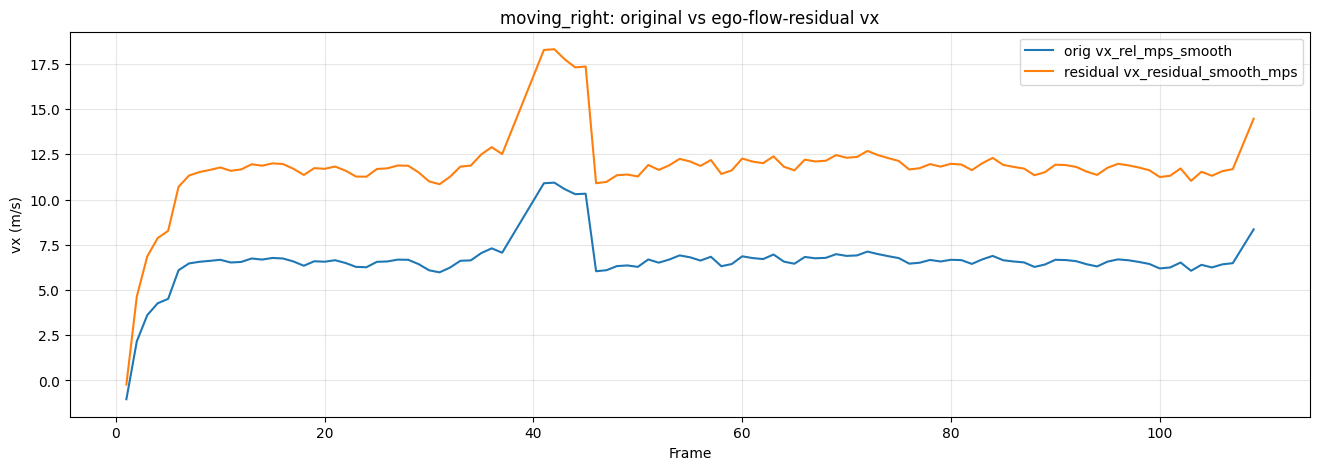

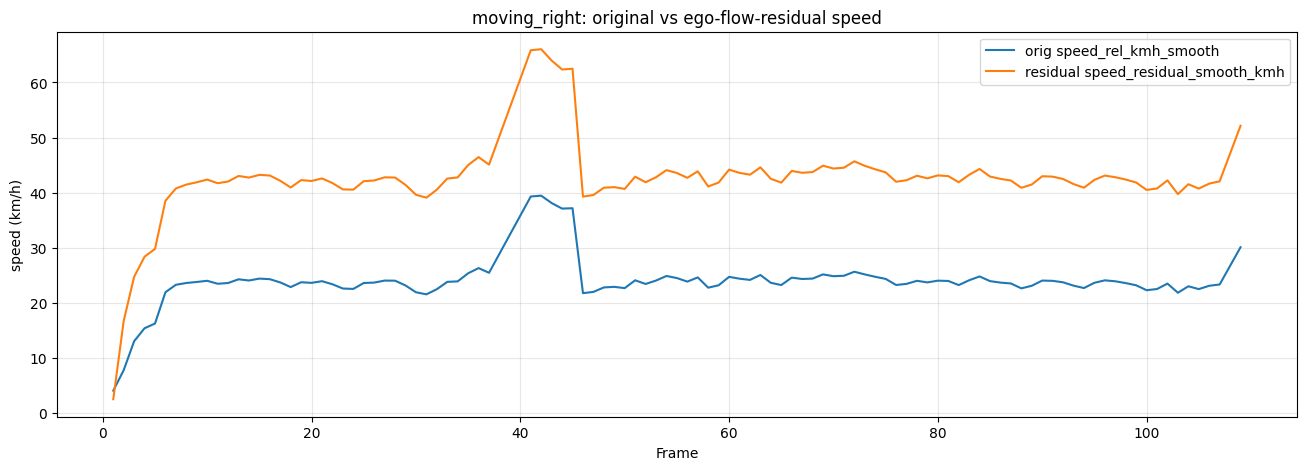

Cell 12 complete.


In [13]:
# ============================================================
# Cell 12: Ego-flow residual relative velocity estimator
# Purpose:
# - improve the relative motion measurement BEFORE metric conversion
# - remove dominant background flow in image space first
# - then convert residual pixel displacement to metric velocity
#
# Core idea:
#   object_pixel_motion = rep_pt(t) - rep_pt(t-1)
#   ego_pixel_motion    = dominant background flow at frame t
#   residual_pixel_motion = object_pixel_motion - ego_pixel_motion
#
# Then:
#   residual metric velocity = residual_pixel_motion * local_scale / dt
#
# Why this cell:
# - Cell 11 showed the main asymmetry is entering through motion measurement,
#   not mainly through scale
# - so we keep the bbox-dimension foundation
# - but replace raw object displacement with ego-flow-corrected displacement
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Helper: apply ego-flow residual correction
# -----------------------------
def recompute_ego_residual_relative_velocity(
    rel_df: pd.DataFrame,
    ego_df: pd.DataFrame,
    fps: float = 30.0,
    vel_window: int = 5,
):
    """
    Inputs
    ------
    rel_df:
        output of run_relative_velocity_baseline(...), containing:
        - rep_image_x, rep_image_y
        - mpp_geom, mpp_smoothed
        - track_id, frame_idx
    ego_df:
        output of estimate_background_ego_direction(...), containing:
        - frame_idx
        - mean_flow_dx_px, mean_flow_dy_px
        or equivalently smoothed unit directions + flow magnitude

    Output
    ------
    DataFrame with extra columns:
        dx_obj_px
        dy_obj_px
        dx_ego_px
        dy_ego_px
        dx_residual_px
        dy_residual_px
        vx_residual_raw_mps
        vy_residual_raw_mps
        speed_residual_raw_kmh
        vx_residual_smooth_mps
        vy_residual_smooth_mps
        speed_residual_smooth_kmh
    """
    df = rel_df.copy().sort_values(["track_id", "frame_idx"]).reset_index(drop=True)

    ego_small = ego_df[
        [
            "frame_idx",
            "mean_flow_dx_px",
            "mean_flow_dy_px",
            "flow_mag_px",
            "ego_unit_dx_smooth",
            "ego_unit_dy_smooth",
        ]
    ].copy()

    df = df.merge(ego_small, on="frame_idx", how="left")

    out_parts = []
    dt = 1.0 / float(fps)

    for tid, g in df.groupby("track_id", sort=False):
        g = g.sort_values("frame_idx").copy().reset_index(drop=True)

        rep_x = g["rep_image_x"].astype(float).to_numpy()
        rep_y = g["rep_image_y"].astype(float).to_numpy()

        # original object motion from representative point
        dx_obj_px = np.full(len(g), np.nan, dtype=np.float64)
        dy_obj_px = np.full(len(g), np.nan, dtype=np.float64)
        dx_obj_px[1:] = rep_x[1:] - rep_x[:-1]
        dy_obj_px[1:] = rep_y[1:] - rep_y[:-1]

        # dominant background flow already measured in image space
        # use mean_flow if available; it already captures apparent background motion
        dx_ego_px = g["mean_flow_dx_px"].astype(float).to_numpy()
        dy_ego_px = g["mean_flow_dy_px"].astype(float).to_numpy()

        # image-space residual
        dx_residual_px = dx_obj_px - dx_ego_px
        dy_residual_px = dy_obj_px - dy_ego_px

        # keep same local metric scaling philosophy as before
        local_mpp = g["mpp_smoothed"].astype(float).to_numpy()

        # pairwise average mpp for frame-to-frame displacement
        local_mpp_pair = np.full(len(g), np.nan, dtype=np.float64)
        local_mpp_pair[1:] = 0.5 * (local_mpp[1:] + local_mpp[:-1])

        vx_residual_raw_mps = (dx_residual_px * local_mpp_pair) / dt
        vy_residual_raw_mps = (dy_residual_px * local_mpp_pair) / dt
        speed_residual_raw_kmh = 3.6 * np.sqrt(
            np.square(vx_residual_raw_mps) + np.square(vy_residual_raw_mps)
        )

        def rolling_mean_nan(arr, window=5):
            return pd.Series(arr).rolling(window=window, min_periods=1).mean().to_numpy()

        vx_residual_smooth_mps = rolling_mean_nan(vx_residual_raw_mps, window=vel_window)
        vy_residual_smooth_mps = rolling_mean_nan(vy_residual_raw_mps, window=vel_window)
        speed_residual_smooth_kmh = 3.6 * np.sqrt(
            np.square(vx_residual_smooth_mps) + np.square(vy_residual_smooth_mps)
        )

        g["dx_obj_px"] = dx_obj_px
        g["dy_obj_px"] = dy_obj_px
        g["dx_ego_px"] = dx_ego_px
        g["dy_ego_px"] = dy_ego_px
        g["dx_residual_px"] = dx_residual_px
        g["dy_residual_px"] = dy_residual_px

        g["vx_residual_raw_mps"] = vx_residual_raw_mps
        g["vy_residual_raw_mps"] = vy_residual_raw_mps
        g["speed_residual_raw_kmh"] = speed_residual_raw_kmh

        g["vx_residual_smooth_mps"] = vx_residual_smooth_mps
        g["vy_residual_smooth_mps"] = vy_residual_smooth_mps
        g["speed_residual_smooth_kmh"] = speed_residual_smooth_kmh

        out_parts.append(g)

    return pd.concat(out_parts, ignore_index=True)

# -----------------------------
# 2) Run residual estimator on moving videos
# -----------------------------
moving_left_residual_df = recompute_ego_residual_relative_velocity(
    rel_df=MOVING_LEFT_REL_DF,
    ego_df=MOVING_LEFT_EGO_DF,
    fps=30.0,
    vel_window=VEL_WINDOW,
)

moving_right_residual_df = recompute_ego_residual_relative_velocity(
    rel_df=MOVING_RIGHT_REL_DF,
    ego_df=MOVING_RIGHT_EGO_DF,
    fps=30.0,
    vel_window=VEL_WINDOW,
)

# For still camera, create a zero-ego dataframe so we can compare uniformly
still_zero_ego_df = pd.DataFrame({
    "frame_idx": sorted(STILL_BASELINE_OBS_DF["frame_idx"].unique()),
    "mean_flow_dx_px": 0.0,
    "mean_flow_dy_px": 0.0,
    "flow_mag_px": 0.0,
    "ego_unit_dx_smooth": 0.0,
    "ego_unit_dy_smooth": 0.0,
})

still_residual_df = recompute_ego_residual_relative_velocity(
    rel_df=STILL_BASELINE_OBS_DF,
    ego_df=still_zero_ego_df,
    fps=30.0,
    vel_window=VEL_WINDOW,
)

# -----------------------------
# 3) Dominant-track comparison
# -----------------------------
still_residual_dom = (
    still_residual_df[still_residual_df["track_id"] == STILL_BASELINE_DOMINANT_TRACK_ID]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

left_residual_dom = (
    moving_left_residual_df[moving_left_residual_df["track_id"] == MOVING_LEFT_DOMINANT_TRACK_ID]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

right_residual_dom = (
    moving_right_residual_df[moving_right_residual_df["track_id"] == MOVING_RIGHT_DOMINANT_TRACK_ID]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

# -----------------------------
# 4) Summary table
# -----------------------------
residual_summary_rows = []
for name, df in [
    ("still", still_residual_dom),
    ("moving_left", left_residual_dom),
    ("moving_right", right_residual_dom),
]:
    residual_summary_rows.append({
        "video_key": name,
        "mean_dx_obj_px": df["dx_obj_px"].mean(),
        "mean_dx_ego_px": df["dx_ego_px"].mean(),
        "mean_dx_residual_px": df["dx_residual_px"].mean(),
        "mean_vx_residual_smooth_mps": df["vx_residual_smooth_mps"].mean(),
        "mean_vy_residual_smooth_mps": df["vy_residual_smooth_mps"].mean(),
        "mean_speed_residual_smooth_kmh": df["speed_residual_smooth_kmh"].mean(),
    })

residual_summary_df = pd.DataFrame(residual_summary_rows)
print("=== Ego-flow residual relative estimator summary ===")
display(residual_summary_df)

# -----------------------------
# 5) Plots: original vs residual
# -----------------------------
def plot_original_vs_residual(orig_df, residual_df, title_prefix):
    plt.figure(figsize=(16, 5))
    plt.plot(orig_df["frame_idx"], orig_df["vx_rel_mps_smooth"], label="orig vx_rel_mps_smooth")
    plt.plot(residual_df["frame_idx"], residual_df["vx_residual_smooth_mps"], label="residual vx_residual_smooth_mps")
    plt.xlabel("Frame")
    plt.ylabel("vx (m/s)")
    plt.title(f"{title_prefix}: original vs ego-flow-residual vx")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(16, 5))
    plt.plot(orig_df["frame_idx"], orig_df["speed_rel_kmh_smooth"], label="orig speed_rel_kmh_smooth")
    plt.plot(residual_df["frame_idx"], residual_df["speed_residual_smooth_kmh"], label="residual speed_residual_smooth_kmh")
    plt.xlabel("Frame")
    plt.ylabel("speed (km/h)")
    plt.title(f"{title_prefix}: original vs ego-flow-residual speed")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_original_vs_residual(STILL_BASELINE_DOMINANT_DF, still_residual_dom, "still")
plot_original_vs_residual(
    MOVING_LEFT_REL_DF[MOVING_LEFT_REL_DF["track_id"] == MOVING_LEFT_DOMINANT_TRACK_ID].sort_values("frame_idx").reset_index(drop=True),
    left_residual_dom,
    "moving_left",
)
plot_original_vs_residual(
    MOVING_RIGHT_REL_DF[MOVING_RIGHT_REL_DF["track_id"] == MOVING_RIGHT_DOMINANT_TRACK_ID].sort_values("frame_idx").reset_index(drop=True),
    right_residual_dom,
    "moving_right",
)

# -----------------------------
# 6) Save artifacts for next cell
# -----------------------------
STILL_RESIDUAL_DF = still_residual_df
MOVING_LEFT_RESIDUAL_DF = moving_left_residual_df
MOVING_RIGHT_RESIDUAL_DF = moving_right_residual_df

STILL_RESIDUAL_DOM_DF = still_residual_dom
MOVING_LEFT_RESIDUAL_DOM_DF = left_residual_dom
MOVING_RIGHT_RESIDUAL_DOM_DF = right_residual_dom

CELL12_RESIDUAL_SUMMARY_DF = residual_summary_df

print("Cell 12 complete.")

Still-camera baseline mean speed (km/h): 27.963293
=== Alpha sweep summary ===


,alpha,still_baseline_mean_kmh,moving_left_mean_kmh,moving_right_mean_kmh,moving_left_minus_still,moving_right_minus_still,abs_total_error_vs_still,left_right_gap_kmh
0,0.7,27.963293,29.424873,27.299613,1.461579,-0.663680,2.125259,-2.125259
1,0.8,27.963293,28.925187,27.794414,0.961894,-0.168879,1.130773,-1.130773
2,0.9,27.963293,28.425537,28.290645,0.462243,0.327352,0.789595,-0.134892
3,1.0,27.963293,27.926541,28.787996,-0.036752,0.824702,0.861454,0.861454
4,1.1,27.963293,27.437771,29.286097,-0.525523,1.322803,1.848326,1.848326
5,1.2,27.963293,26.950129,29.784675,-1.013164,1.821381,2.834545,2.834545
6,1.3,27.963293,26.462529,30.283558,-1.500764,2.320265,3.821029,3.821029


Best alpha by total error vs still baseline: 0.90


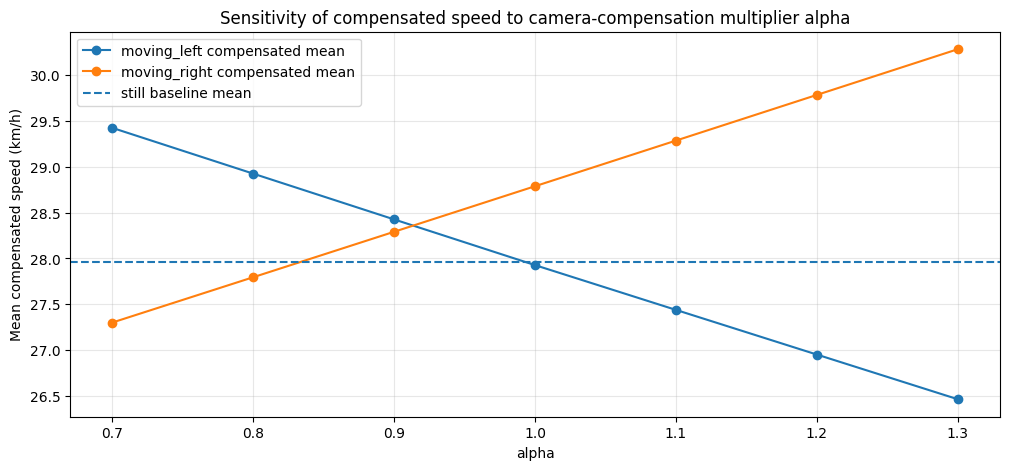

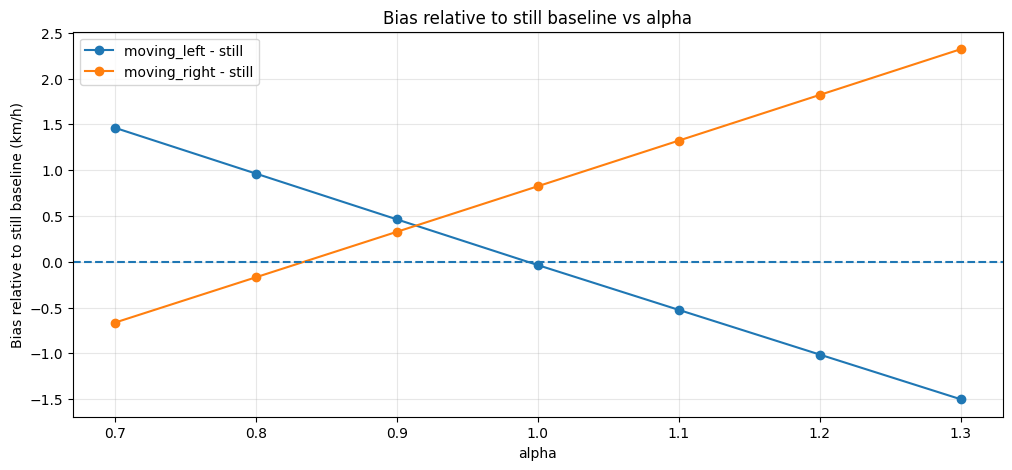

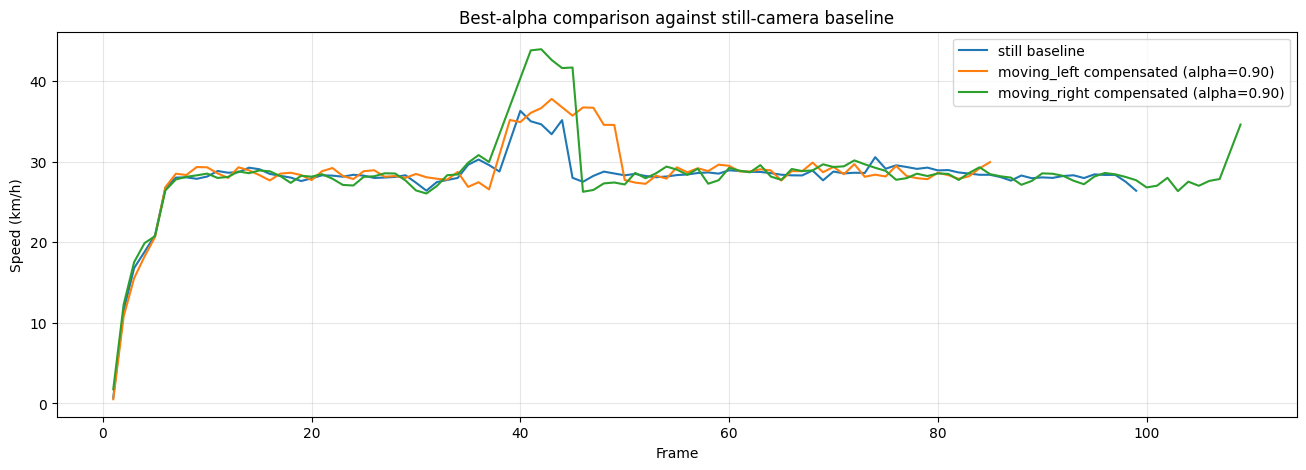

Cell 13 complete.
Selected BEST_ALPHA = 0.90


In [14]:
# ============================================================
# Cell 13: Sweep camera-compensation magnitude without changing
#          the underlying relative estimator
#
# What we learned from Cell 12:
# - The ego-flow-residual estimator, as implemented there, is not
#   a good replacement for the current pipeline.
# - It failed the most important sanity check: it did NOT preserve
#   the still-camera baseline. Even with zero ego flow, the speed
#   estimate jumped far above the original baseline.
# - That means Cell 12 changed more than just ego compensation; it
#   altered the effective motion-to-metric conversion enough to make
#   the outputs unusable for this pipeline.
# - So we should NOT move forward with that residual formulation.
#
# What we do instead in this cell:
# - Return to the last good design:
#     1) original relative estimator
#     2) background-based ego-direction estimation
#     3) known camera speed magnitude
#     4) vector compensation
# - But now introduce a scalar compensation multiplier alpha:
#
#       v_cam_eff = alpha * v_cam
#
# - This lets us test whether the remaining left/right asymmetry is
#   mostly due to:
#     a) slightly mis-scaled camera compensation magnitude, or
#     b) upstream tracking / box / rep-point asymmetry that alpha
#        alone cannot fix.
#
# Interpretation goal:
# - If a single alpha makes both moving_left and moving_right land
#   close to the still-camera baseline, then the compensation
#   magnitude is slightly off and can be tuned.
# - If no single alpha fixes both sides at once, then the remaining
#   issue is upstream in the relative velocity estimator.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Alpha sweep settings
# -----------------------------
ALPHA_VALUES = [0.70, 0.80, 0.90, 1.00, 1.10, 1.20, 1.30]

still_baseline_mean_kmh = float(
    STILL_BASELINE_DOMINANT_DF["speed_rel_kmh_smooth"].dropna().mean()
)

print("Still-camera baseline mean speed (km/h):", round(still_baseline_mean_kmh, 6))

# -----------------------------
# 2) Compensation helper with alpha
# -----------------------------
def compensate_with_alpha(
    rel_df: pd.DataFrame,
    ego_df: pd.DataFrame,
    camera_speed_kmh: float,
    alpha: float,
    video_key: str,
) -> pd.DataFrame:
    out = rel_df.copy()

    ego_cols = [
        "frame_idx",
        "ego_unit_dx_smooth",
        "ego_unit_dy_smooth",
        "n_background_tracks_used",
        "flow_mag_px",
    ]
    out = out.merge(ego_df[ego_cols].copy(), on="frame_idx", how="left")

    camera_speed_mps = float(camera_speed_kmh) / 3.6

    # estimated ego vector is background apparent motion
    # camera motion is the negative of that
    out["cam_unit_dx"] = -out["ego_unit_dx_smooth"]
    out["cam_unit_dy"] = -out["ego_unit_dy_smooth"]

    out["alpha"] = float(alpha)
    out["camera_speed_kmh_input"] = float(camera_speed_kmh)
    out["camera_speed_mps_input"] = camera_speed_mps

    out["vx_cam_mps_alpha"] = float(alpha) * camera_speed_mps * out["cam_unit_dx"]
    out["vy_cam_mps_alpha"] = float(alpha) * camera_speed_mps * out["cam_unit_dy"]

    out["vx_world_mps_alpha"] = out["vx_rel_mps_smooth"] + out["vx_cam_mps_alpha"]
    out["vy_world_mps_alpha"] = out["vy_rel_mps_smooth"] + out["vy_cam_mps_alpha"]

    out["speed_world_kmh_alpha"] = 3.6 * np.sqrt(
        np.square(out["vx_world_mps_alpha"]) + np.square(out["vy_world_mps_alpha"])
    )

    out["video_key"] = video_key
    return out

# -----------------------------
# 3) Run alpha sweep for left/right
# -----------------------------
left_alpha_results = {}
right_alpha_results = {}
alpha_summary_rows = []

left_dom_track_id = MOVING_LEFT_DOMINANT_TRACK_ID
right_dom_track_id = MOVING_RIGHT_DOMINANT_TRACK_ID

for alpha in ALPHA_VALUES:
    left_df_alpha = compensate_with_alpha(
        rel_df=MOVING_LEFT_REL_DF,
        ego_df=MOVING_LEFT_EGO_DF,
        camera_speed_kmh=CAMERA_SPEED_KMH_BY_VIDEO["moving_left"],
        alpha=alpha,
        video_key="moving_left",
    )

    right_df_alpha = compensate_with_alpha(
        rel_df=MOVING_RIGHT_REL_DF,
        ego_df=MOVING_RIGHT_EGO_DF,
        camera_speed_kmh=CAMERA_SPEED_KMH_BY_VIDEO["moving_right"],
        alpha=alpha,
        video_key="moving_right",
    )

    left_alpha_results[alpha] = left_df_alpha
    right_alpha_results[alpha] = right_df_alpha

    left_dom = (
        left_df_alpha[left_df_alpha["track_id"] == left_dom_track_id]
        .sort_values("frame_idx")
        .reset_index(drop=True)
    )
    right_dom = (
        right_df_alpha[right_df_alpha["track_id"] == right_dom_track_id]
        .sort_values("frame_idx")
        .reset_index(drop=True)
    )

    left_mean = float(left_dom["speed_world_kmh_alpha"].dropna().mean())
    right_mean = float(right_dom["speed_world_kmh_alpha"].dropna().mean())

    alpha_summary_rows.append({
        "alpha": float(alpha),
        "still_baseline_mean_kmh": still_baseline_mean_kmh,
        "moving_left_mean_kmh": left_mean,
        "moving_right_mean_kmh": right_mean,
        "moving_left_minus_still": left_mean - still_baseline_mean_kmh,
        "moving_right_minus_still": right_mean - still_baseline_mean_kmh,
        "abs_total_error_vs_still": abs(left_mean - still_baseline_mean_kmh) + abs(right_mean - still_baseline_mean_kmh),
        "left_right_gap_kmh": right_mean - left_mean,
    })

alpha_summary_df = pd.DataFrame(alpha_summary_rows).sort_values("alpha").reset_index(drop=True)

print("=== Alpha sweep summary ===")
display(alpha_summary_df)

best_alpha_row = alpha_summary_df.sort_values(
    ["abs_total_error_vs_still", "left_right_gap_kmh"],
    key=lambda s: np.abs(s) if s.name == "left_right_gap_kmh" else s
).iloc[0]

BEST_ALPHA = float(best_alpha_row["alpha"])
print(f"Best alpha by total error vs still baseline: {BEST_ALPHA:.2f}")

# -----------------------------
# 4) Plot mean compensated speed vs alpha
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(alpha_summary_df["alpha"], alpha_summary_df["moving_left_mean_kmh"], marker="o", label="moving_left compensated mean")
plt.plot(alpha_summary_df["alpha"], alpha_summary_df["moving_right_mean_kmh"], marker="o", label="moving_right compensated mean")
plt.axhline(still_baseline_mean_kmh, linestyle="--", label="still baseline mean")
plt.xlabel("alpha")
plt.ylabel("Mean compensated speed (km/h)")
plt.title("Sensitivity of compensated speed to camera-compensation multiplier alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(alpha_summary_df["alpha"], alpha_summary_df["moving_left_minus_still"], marker="o", label="moving_left - still")
plt.plot(alpha_summary_df["alpha"], alpha_summary_df["moving_right_minus_still"], marker="o", label="moving_right - still")
plt.axhline(0.0, linestyle="--")
plt.xlabel("alpha")
plt.ylabel("Bias relative to still baseline (km/h)")
plt.title("Bias relative to still baseline vs alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 5) Inspect dominant tracks at best alpha
# -----------------------------
best_left_df = left_alpha_results[BEST_ALPHA]
best_right_df = right_alpha_results[BEST_ALPHA]

best_left_dom = (
    best_left_df[best_left_df["track_id"] == left_dom_track_id]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

best_right_dom = (
    best_right_df[best_right_df["track_id"] == right_dom_track_id]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

plt.figure(figsize=(16, 5))
plt.plot(STILL_BASELINE_DOMINANT_DF["frame_idx"], STILL_BASELINE_DOMINANT_DF["speed_rel_kmh_smooth"], label="still baseline")
plt.plot(best_left_dom["frame_idx"], best_left_dom["speed_world_kmh_alpha"], label=f"moving_left compensated (alpha={BEST_ALPHA:.2f})")
plt.plot(best_right_dom["frame_idx"], best_right_dom["speed_world_kmh_alpha"], label=f"moving_right compensated (alpha={BEST_ALPHA:.2f})")
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Best-alpha comparison against still-camera baseline")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 6) Save artifacts for later cells
# -----------------------------
CELL13_ALPHA_SUMMARY_DF = alpha_summary_df
CELL13_BEST_ALPHA = BEST_ALPHA
CELL13_LEFT_ALPHA_RESULTS = left_alpha_results
CELL13_RIGHT_ALPHA_RESULTS = right_alpha_results
CELL13_BEST_LEFT_DF = best_left_df
CELL13_BEST_RIGHT_DF = best_right_df
CELL13_BEST_LEFT_DOM_DF = best_left_dom
CELL13_BEST_RIGHT_DOM_DF = best_right_dom

print("Cell 13 complete.")
print(f"Selected BEST_ALPHA = {BEST_ALPHA:.2f}")

New videos:
  - moving_down: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\camera_moving_down.mp4
  - moving_up: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\camera_moving_up.mp4

Using BEST_ALPHA = 0.9


moving_down_ego_direction:   0%|          | 0/94 [00:00<?, ?it/s]

Saved ego debug video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\02_ego_direction_estimation\moving_down_ego_direction_ego_debug.mp4
Saved ego direction CSV: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\02_ego_direction_estimation\moving_down_ego_direction_ego_direction.csv


moving_up_ego_direction:   0%|          | 0/102 [00:00<?, ?it/s]

Saved ego debug video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\02_ego_direction_estimation\moving_up_ego_direction_ego_debug.mp4
Saved ego direction CSV: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\02_ego_direction_estimation\moving_up_ego_direction_ego_direction.csv
Running moving_down_relative_velocity
Video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\camera_moving_down.mp4
Frames: 94 | Size: 800x600 | FPS: 20.00


...

Saved annotated video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\03_vector_compensation\moving_up_relative_velocity_annotated.mp4
Saved observations CSV: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\03_vector_compensation\moving_up_relative_velocity_observations.csv
=== moving_down compensated summary ===


,vx_rel_mps_smooth,vy_rel_mps_smooth,vx_cam_mps,vy_cam_mps,vx_world_mps,vy_world_mps,speed_rel_kmh_smooth,speed_world_kmh
count,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000
mean,7.662169,-1.028235,-0.004122,1.249952,7.658046,0.221716,27.850076,27.585837
std,0.993858,0.134406,0.010215,0.000245,1.003428,0.134409,3.459159,3.603688
min,1.002381,-1.404705,-0.074315,1.247789,0.928066,-0.154705,5.020694,3.487844
25%,7.717338,-1.114219,-0.003485,1.249995,7.716121,0.135779,28.008618,27.795974
50%,7.831971,-1.026240,-0.001383,1.249999,7.832809,0.223760,28.429225,28.203338
75%,7.981916,-0.961821,-0.000318,1.250000,7.978468,0.288174,28.999473,28.760145
max,8.504794,-0.572007,0.004080,1.250000,8.503974,0.677989,30.942090,30.614320


Dominant track_id: 1
Dominant-track mean relative speed (km/h):   27.850
Dominant-track mean compensated speed (km/h): 27.586
Bias vs still baseline (km/h): -0.377
=== moving_up compensated summary ===


,vx_rel_mps_smooth,vy_rel_mps_smooth,vx_cam_mps,vy_cam_mps,vx_world_mps,vy_world_mps,speed_rel_kmh_smooth,speed_world_kmh
count,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000
mean,8.054840,1.646030,0.001367,-1.249997,8.056207,0.396034,29.642222,29.070927
std,1.383786,0.245313,0.002590,0.000007,1.383746,0.245309,4.782354,4.860460
min,-0.222579,0.943779,-0.007601,-1.250000,-0.230180,-0.306198,3.490812,1.379038
25%,7.698929,1.497406,-0.000087,-1.250000,7.702337,0.247407,28.400701,27.774533
50%,7.912997,1.654644,0.000800,-1.250000,7.913071,0.404644,29.045218,28.509171
75%,9.044168,1.778931,0.002029,-1.249998,9.048389,0.528931,33.167357,32.626338
max,10.167808,2.379421,0.009356,-1.249965,10.168410,1.129423,37.180089,36.661916


Dominant track_id: 1
Dominant-track mean relative speed (km/h):   29.642
Dominant-track mean compensated speed (km/h): 29.071
Bias vs still baseline (km/h): 1.108


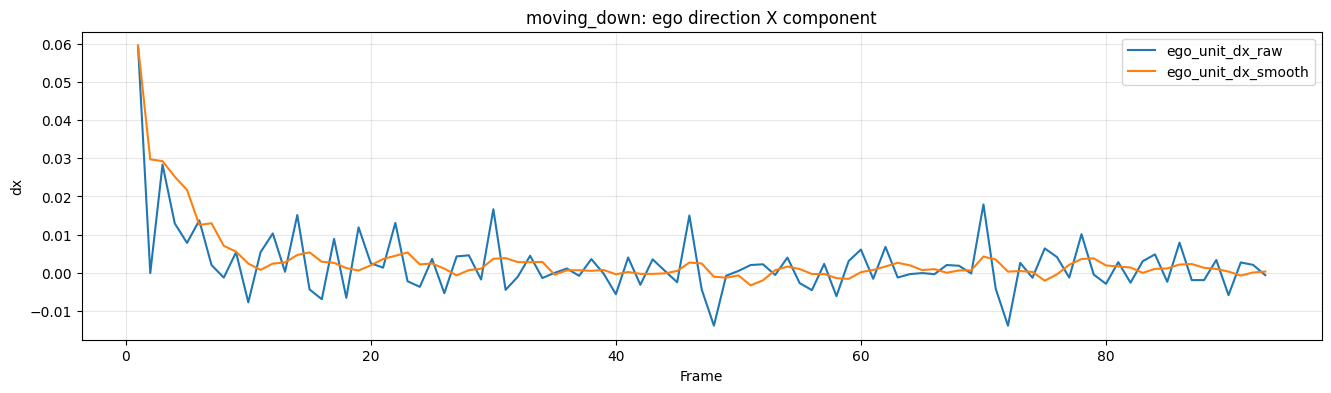

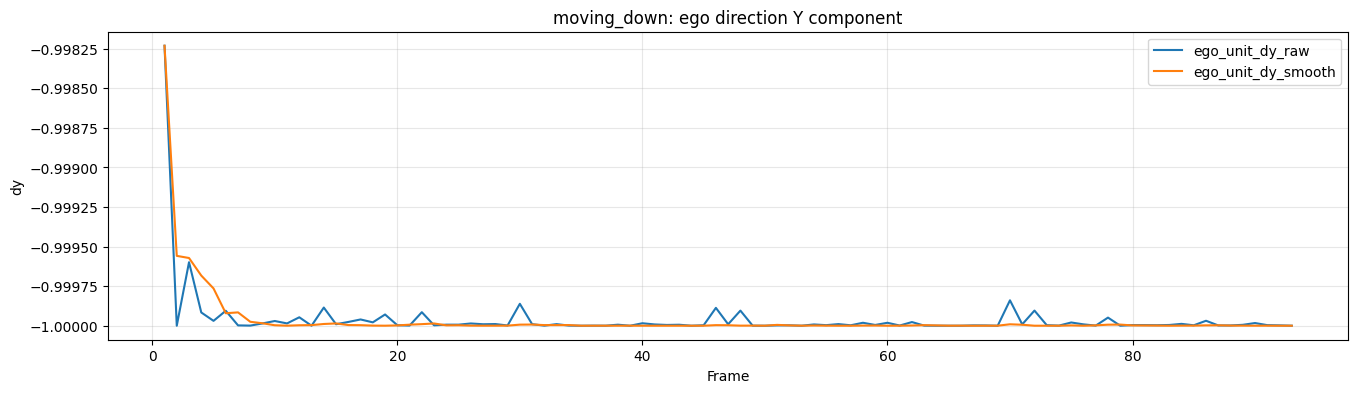

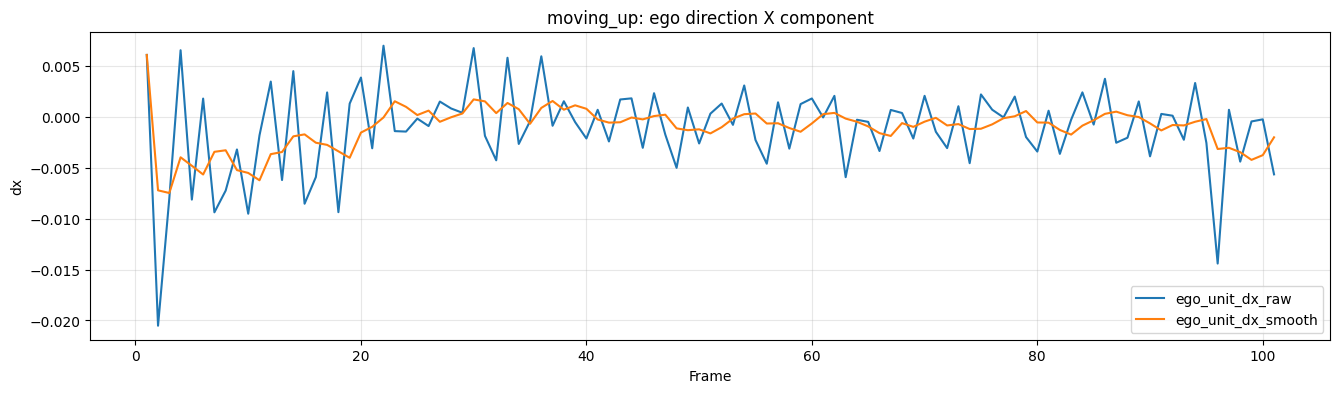

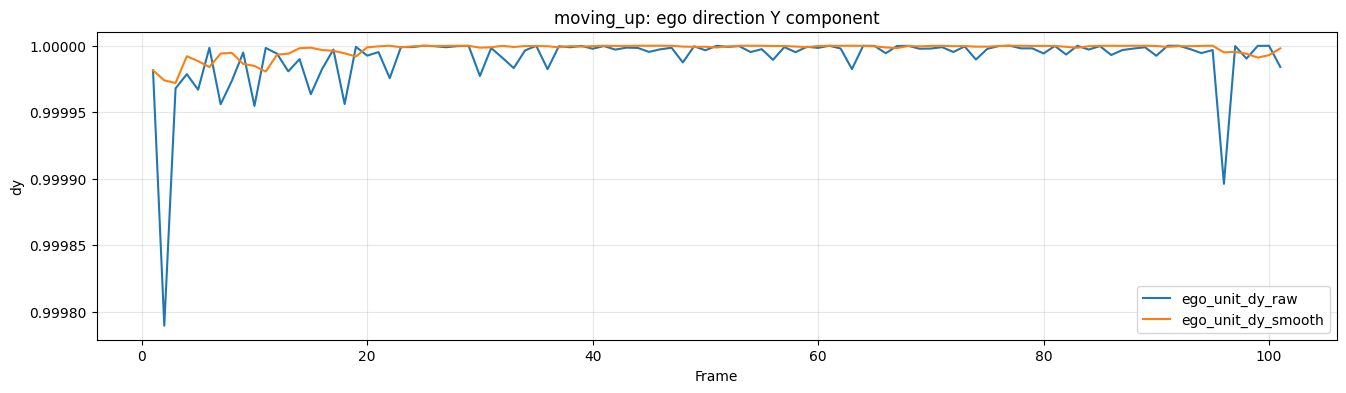

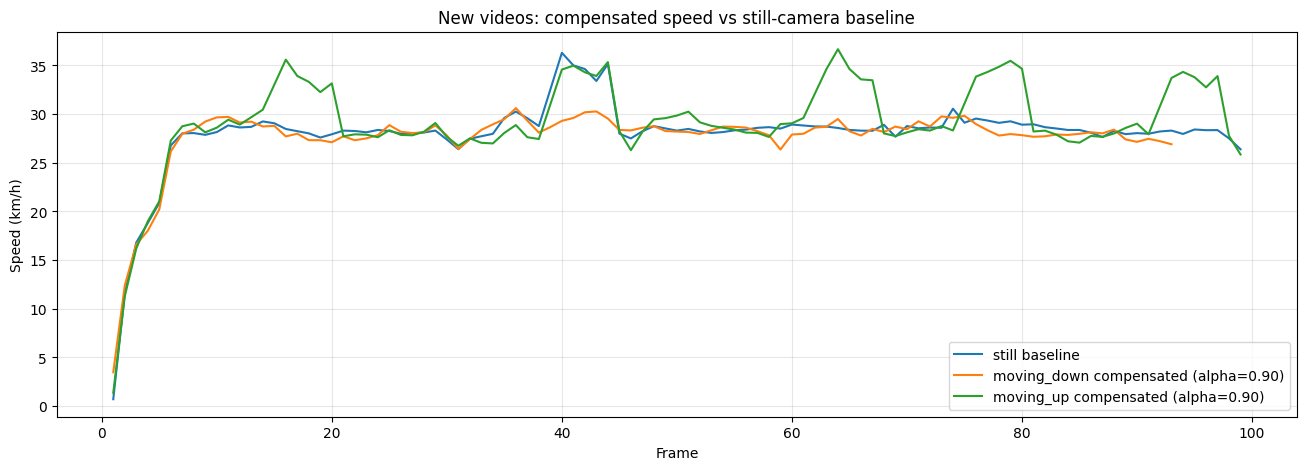

=== New-video comparison vs still baseline ===


,video_key,mean_speed_kmh,bias_vs_still
0,still_baseline,27.963293,0.000000
1,moving_down_compensated,27.585837,-0.377457
2,moving_up_compensated,29.070927,1.107634



Saved files:
02 ego-direction video (down): C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\02_ego_direction_estimation\moving_down_ego_direction_ego_debug.mp4
02 ego-direction video (up)  : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\02_ego_direction_estimation\moving_up_ego_direction_ego_debug.mp4
03 relative video (down)     : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\03_vector_compensation\moving_down_relative_velocity_annotated.mp4
03 relative video (up)       : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\03_vector_compensation\moving_up_relative_velocity_annota

In [15]:
# ============================================================
# Cell 14: Run current pipeline on camera_moving_down / up
#
# Purpose:
# - add the two new videos:
#     1) camera_moving_down.mp4
#     2) camera_moving_up.mp4
# - run:
#     a) 02_ego_direction_estimation
#     b) 03_vector_compensation
# - use the CURRENT best pipeline:
#     - original relative estimator
#     - background-based ego-direction estimation
#     - known camera speed magnitude
#     - vector compensation with alpha = BEST_ALPHA
#
# Notes:
# - We are NOT locking anything in yet.
# - This cell is for evaluation on the new motion directions.
# - It saves:
#     1) ego-direction debug videos in 02_ego_direction_estimation
#     2) relative-velocity annotated videos in 03_vector_compensation
#     3) compensated CSVs in 03_vector_compensation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# 1) New video paths
# -----------------------------
MOVING_DOWN_VIDEO_PATH = BASE_PATH / "camera_moving_down.mp4"
MOVING_UP_VIDEO_PATH   = BASE_PATH / "camera_moving_up.mp4"

assert MOVING_DOWN_VIDEO_PATH.exists(), f"Missing video: {MOVING_DOWN_VIDEO_PATH}"
assert MOVING_UP_VIDEO_PATH.exists(), f"Missing video: {MOVING_UP_VIDEO_PATH}"

NEW_VIDEO_PATHS = {
    "moving_down": MOVING_DOWN_VIDEO_PATH,
    "moving_up": MOVING_UP_VIDEO_PATH,
}

NEW_CAMERA_SPEED_KMH_BY_VIDEO = {
    "moving_down": 5.0,
    "moving_up": 5.0,
}

print("New videos:")
for k, v in NEW_VIDEO_PATHS.items():
    print(f"  - {k}: {v}")

print("\nUsing BEST_ALPHA =", BEST_ALPHA)

# -----------------------------
# 2) Run ego-direction estimation (02_ego_direction_estimation)
# -----------------------------
moving_down_ego_results = estimate_background_ego_direction(
    video_path=NEW_VIDEO_PATHS["moving_down"],
    detector=DETECTOR,
    class_map=PHASE_CLASSES,
    output_dir=OUTPUT_DIRS["ego"],
    experiment_name="moving_down_ego_direction",
)

moving_up_ego_results = estimate_background_ego_direction(
    video_path=NEW_VIDEO_PATHS["moving_up"],
    detector=DETECTOR,
    class_map=PHASE_CLASSES,
    output_dir=OUTPUT_DIRS["ego"],
    experiment_name="moving_up_ego_direction",
)

MOVING_DOWN_EGO_DF = moving_down_ego_results["ego_df"].copy()
MOVING_UP_EGO_DF = moving_up_ego_results["ego_df"].copy()

# -----------------------------
# 3) Run relative estimator (03_vector_compensation inputs)
# -----------------------------
moving_down_rel_results = run_relative_velocity_baseline(
    video_path=NEW_VIDEO_PATHS["moving_down"],
    output_dir=OUTPUT_DIRS["final"],
    detector=DETECTOR,
    class_map=PHASE_CLASSES,
    experiment_name="moving_down_relative_velocity",
)

moving_up_rel_results = run_relative_velocity_baseline(
    video_path=NEW_VIDEO_PATHS["moving_up"],
    output_dir=OUTPUT_DIRS["final"],
    detector=DETECTOR,
    class_map=PHASE_CLASSES,
    experiment_name="moving_up_relative_velocity",
)

MOVING_DOWN_REL_DF = moving_down_rel_results["obs_df"].copy()
MOVING_UP_REL_DF = moving_up_rel_results["obs_df"].copy()

# -----------------------------
# 4) Compensation helper using locked-in alpha
# -----------------------------
def compensate_with_locked_alpha(
    rel_df: pd.DataFrame,
    ego_df: pd.DataFrame,
    camera_speed_kmh: float,
    alpha: float,
    video_key: str,
) -> pd.DataFrame:
    out = rel_df.copy()

    ego_cols = [
        "frame_idx",
        "ego_unit_dx_smooth",
        "ego_unit_dy_smooth",
        "n_background_tracks_used",
        "flow_mag_px",
    ]
    out = out.merge(ego_df[ego_cols].copy(), on="frame_idx", how="left")

    camera_speed_mps = float(camera_speed_kmh) / 3.6

    # estimated ego vector = apparent background motion
    # camera motion = negative of that
    out["cam_unit_dx"] = -out["ego_unit_dx_smooth"]
    out["cam_unit_dy"] = -out["ego_unit_dy_smooth"]

    out["alpha"] = float(alpha)
    out["camera_speed_kmh_input"] = float(camera_speed_kmh)
    out["camera_speed_mps_input"] = camera_speed_mps

    out["vx_cam_mps"] = float(alpha) * camera_speed_mps * out["cam_unit_dx"]
    out["vy_cam_mps"] = float(alpha) * camera_speed_mps * out["cam_unit_dy"]

    out["vx_world_mps"] = out["vx_rel_mps_smooth"] + out["vx_cam_mps"]
    out["vy_world_mps"] = out["vy_rel_mps_smooth"] + out["vy_cam_mps"]

    out["speed_world_kmh"] = 3.6 * np.sqrt(
        np.square(out["vx_world_mps"]) + np.square(out["vy_world_mps"])
    )

    out["video_key"] = video_key
    return out

# -----------------------------
# 5) Apply compensation
# -----------------------------
MOVING_DOWN_COMP_DF = compensate_with_locked_alpha(
    rel_df=MOVING_DOWN_REL_DF,
    ego_df=MOVING_DOWN_EGO_DF,
    camera_speed_kmh=NEW_CAMERA_SPEED_KMH_BY_VIDEO["moving_down"],
    alpha=BEST_ALPHA,
    video_key="moving_down",
)

MOVING_UP_COMP_DF = compensate_with_locked_alpha(
    rel_df=MOVING_UP_REL_DF,
    ego_df=MOVING_UP_EGO_DF,
    camera_speed_kmh=NEW_CAMERA_SPEED_KMH_BY_VIDEO["moving_up"],
    alpha=BEST_ALPHA,
    video_key="moving_up",
)

# -----------------------------
# 6) Save compensated CSVs
# -----------------------------
MOVING_DOWN_COMP_CSV = OUTPUT_DIRS["final"] / "moving_down_compensated_velocity.csv"
MOVING_UP_COMP_CSV   = OUTPUT_DIRS["final"] / "moving_up_compensated_velocity.csv"

MOVING_DOWN_COMP_DF.to_csv(MOVING_DOWN_COMP_CSV, index=False)
MOVING_UP_COMP_DF.to_csv(MOVING_UP_COMP_CSV, index=False)

# -----------------------------
# 7) Summaries for new videos
# -----------------------------
def summarize_new_video(comp_df: pd.DataFrame, title_prefix: str):
    print(f"=== {title_prefix} compensated summary ===")
    display(
        comp_df[
            [
                "vx_rel_mps_smooth",
                "vy_rel_mps_smooth",
                "vx_cam_mps",
                "vy_cam_mps",
                "vx_world_mps",
                "vy_world_mps",
                "speed_rel_kmh_smooth",
                "speed_world_kmh",
            ]
        ].describe()
    )

    dominant_track_id = int(comp_df["track_id"].value_counts().index[0])
    dom_df = (
        comp_df[comp_df["track_id"] == dominant_track_id]
        .sort_values("frame_idx")
        .reset_index(drop=True)
    )

    rel_mean = float(dom_df["speed_rel_kmh_smooth"].dropna().mean())
    world_mean = float(dom_df["speed_world_kmh"].dropna().mean())

    print(f"Dominant track_id: {dominant_track_id}")
    print(f"Dominant-track mean relative speed (km/h):   {rel_mean:.3f}")
    print(f"Dominant-track mean compensated speed (km/h): {world_mean:.3f}")
    print(f"Bias vs still baseline (km/h): {world_mean - still_baseline_mean_kmh:.3f}")

    return dominant_track_id, dom_df

moving_down_dom_tid, moving_down_dom_df = summarize_new_video(
    MOVING_DOWN_COMP_DF,
    title_prefix="moving_down",
)

moving_up_dom_tid, moving_up_dom_df = summarize_new_video(
    MOVING_UP_COMP_DF,
    title_prefix="moving_up",
)

# -----------------------------
# 8) Plot ego-direction components for the new videos
# -----------------------------
def plot_ego_components(ego_df: pd.DataFrame, title_prefix: str):
    plt.figure(figsize=(16, 4))
    plt.plot(ego_df["frame_idx"], ego_df["ego_unit_dx_raw"], label="ego_unit_dx_raw")
    plt.plot(ego_df["frame_idx"], ego_df["ego_unit_dx_smooth"], label="ego_unit_dx_smooth")
    plt.xlabel("Frame")
    plt.ylabel("dx")
    plt.title(f"{title_prefix}: ego direction X component")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(16, 4))
    plt.plot(ego_df["frame_idx"], ego_df["ego_unit_dy_raw"], label="ego_unit_dy_raw")
    plt.plot(ego_df["frame_idx"], ego_df["ego_unit_dy_smooth"], label="ego_unit_dy_smooth")
    plt.xlabel("Frame")
    plt.ylabel("dy")
    plt.title(f"{title_prefix}: ego direction Y component")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_ego_components(MOVING_DOWN_EGO_DF, "moving_down")
plot_ego_components(MOVING_UP_EGO_DF, "moving_up")

# -----------------------------
# 9) Plot speed comparison against still baseline
# -----------------------------
plt.figure(figsize=(16, 5))
plt.plot(
    STILL_BASELINE_DOMINANT_DF["frame_idx"],
    STILL_BASELINE_DOMINANT_DF["speed_rel_kmh_smooth"],
    label="still baseline",
)
plt.plot(
    moving_down_dom_df["frame_idx"],
    moving_down_dom_df["speed_world_kmh"],
    label=f"moving_down compensated (alpha={BEST_ALPHA:.2f})",
)
plt.plot(
    moving_up_dom_df["frame_idx"],
    moving_up_dom_df["speed_world_kmh"],
    label=f"moving_up compensated (alpha={BEST_ALPHA:.2f})",
)
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("New videos: compensated speed vs still-camera baseline")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 10) Final quick comparison table
# -----------------------------
new_video_compare_df = pd.DataFrame([
    {
        "video_key": "still_baseline",
        "mean_speed_kmh": still_baseline_mean_kmh,
        "bias_vs_still": 0.0,
    },
    {
        "video_key": "moving_down_compensated",
        "mean_speed_kmh": float(moving_down_dom_df["speed_world_kmh"].dropna().mean()),
        "bias_vs_still": float(moving_down_dom_df["speed_world_kmh"].dropna().mean()) - still_baseline_mean_kmh,
    },
    {
        "video_key": "moving_up_compensated",
        "mean_speed_kmh": float(moving_up_dom_df["speed_world_kmh"].dropna().mean()),
        "bias_vs_still": float(moving_up_dom_df["speed_world_kmh"].dropna().mean()) - still_baseline_mean_kmh,
    },
])

print("=== New-video comparison vs still baseline ===")
display(new_video_compare_df)

# -----------------------------
# 11) Save globals for later analysis
# -----------------------------
MOVING_DOWN_EGO_RESULTS = moving_down_ego_results
MOVING_UP_EGO_RESULTS = moving_up_ego_results

MOVING_DOWN_REL_RESULTS = moving_down_rel_results
MOVING_UP_REL_RESULTS = moving_up_rel_results

MOVING_DOWN_DOMINANT_TRACK_ID = moving_down_dom_tid
MOVING_UP_DOMINANT_TRACK_ID = moving_up_dom_tid

MOVING_DOWN_DOMINANT_DF = moving_down_dom_df
MOVING_UP_DOMINANT_DF = moving_up_dom_df

CELL14_NEW_VIDEO_COMPARE_DF = new_video_compare_df

print("\nSaved files:")
print("02 ego-direction video (down):", moving_down_ego_results["debug_video_path"])
print("02 ego-direction video (up)  :", moving_up_ego_results["debug_video_path"])
print("03 relative video (down)     :", moving_down_rel_results["output_video_path"])
print("03 relative video (up)       :", moving_up_rel_results["output_video_path"])
print("03 compensated CSV (down)    :", MOVING_DOWN_COMP_CSV)
print("03 compensated CSV (up)      :", MOVING_UP_COMP_CSV)

print("\nCell 14 complete.")

Still-camera baseline mean speed (km/h): 27.963293
=== Up/down alpha sweep summary ===


,alpha,still_baseline_mean_kmh,moving_down_mean_kmh,moving_up_mean_kmh,moving_down_minus_still,moving_up_minus_still,abs_total_error_vs_still,up_down_gap_kmh
0,0.7,27.963293,27.577195,29.127671,-0.386099,1.164377,1.550476,1.550476
1,0.8,27.963293,27.576621,29.094129,-0.386673,1.130836,1.517508,1.517508
2,0.9,27.963293,27.585837,29.070927,-0.377457,1.107634,1.485090,1.485090
3,1.0,27.963293,27.604784,29.057077,-0.358510,1.093783,1.452293,1.452293
4,1.1,27.963293,27.633360,29.052177,-0.329933,1.088884,1.418817,1.418817
5,1.2,27.963293,27.671442,29.056069,-0.291851,1.092775,1.384627,1.384627
6,1.3,27.963293,27.718897,29.068674,-0.244397,1.105380,1.349777,1.349777


Best alpha for up/down by total error vs still baseline: 1.30


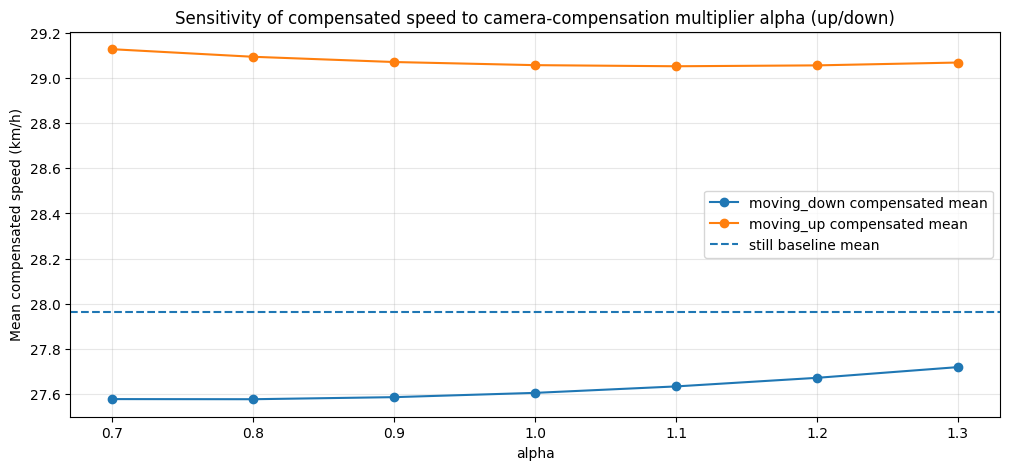

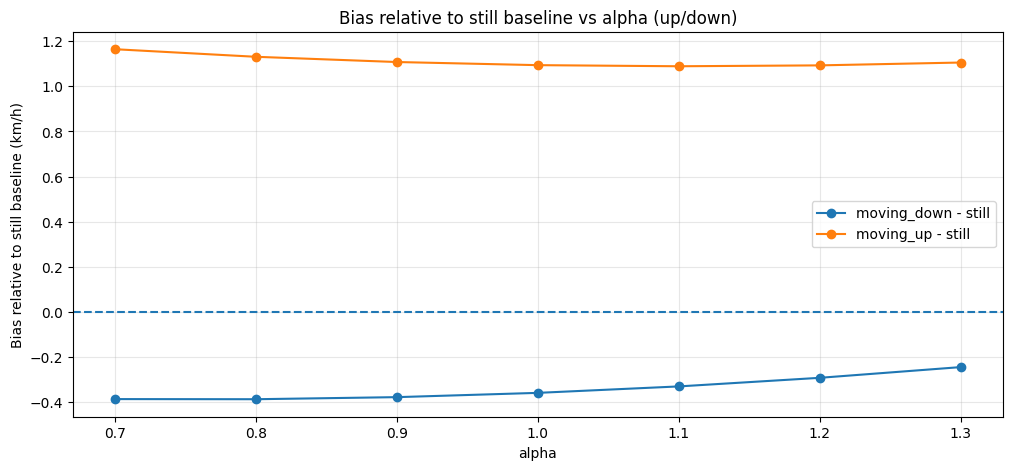

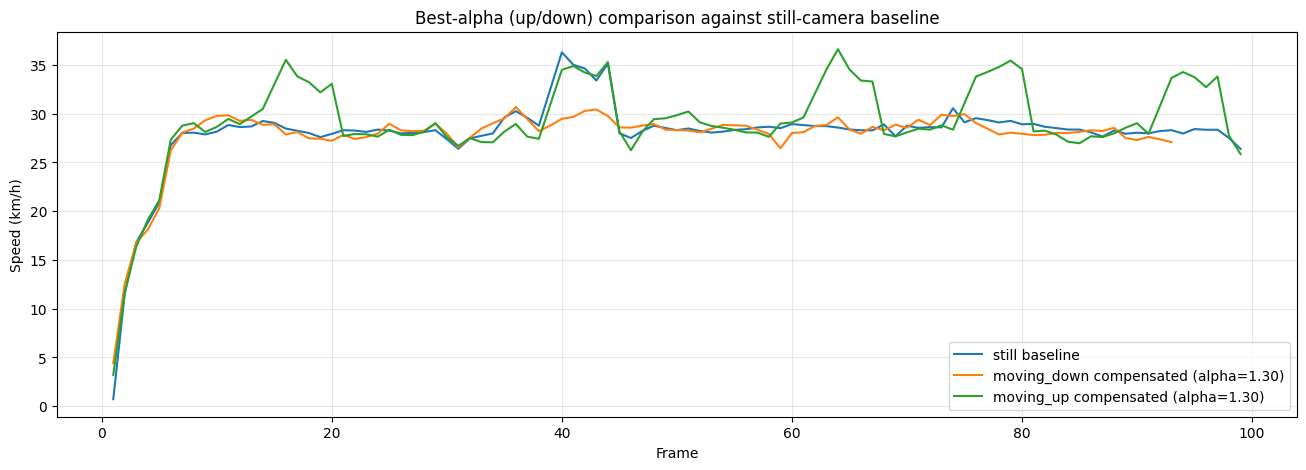

Current left/right best alpha: 0.9
Current up/down best alpha   : 1.3
Cell 15 complete.
Selected BEST_ALPHA_UP_DOWN = 1.30


In [16]:
# ============================================================
# Cell 15: Alpha sweep for moving_down and moving_up
#
# Purpose:
# - run the same alpha sweep we used for left/right
# - evaluate whether a single compensation multiplier alpha
#   also works well for vertical camera motion
#
# What this cell will tell us:
# - whether alpha = 0.90 generalizes to up/down
# - whether moving_down and moving_up prefer different alphas
# - whether we may need:
#     1) one global alpha, or
#     2) direction-specific alpha, or
#     3) separate horizontal / vertical gain terms later
#
# Inputs assumed to already exist:
# - MOVING_DOWN_REL_DF
# - MOVING_UP_REL_DF
# - MOVING_DOWN_EGO_DF
# - MOVING_UP_EGO_DF
# - STILL_BASELINE_DOMINANT_DF
# - still_baseline_mean_kmh
# - compensate_with_alpha(...)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Alpha sweep settings
# -----------------------------
ALPHA_VALUES_UP_DOWN = [0.70, 0.80, 0.90, 1.00, 1.10, 1.20, 1.30]

print("Still-camera baseline mean speed (km/h):", round(still_baseline_mean_kmh, 6))

# -----------------------------
# 2) Run alpha sweep for moving_down / moving_up
# -----------------------------
down_alpha_results = {}
up_alpha_results = {}
up_down_alpha_summary_rows = []

for alpha in ALPHA_VALUES_UP_DOWN:
    down_df_alpha = compensate_with_alpha(
        rel_df=MOVING_DOWN_REL_DF,
        ego_df=MOVING_DOWN_EGO_DF,
        camera_speed_kmh=NEW_CAMERA_SPEED_KMH_BY_VIDEO["moving_down"],
        alpha=alpha,
        video_key="moving_down",
    )

    up_df_alpha = compensate_with_alpha(
        rel_df=MOVING_UP_REL_DF,
        ego_df=MOVING_UP_EGO_DF,
        camera_speed_kmh=NEW_CAMERA_SPEED_KMH_BY_VIDEO["moving_up"],
        alpha=alpha,
        video_key="moving_up",
    )

    down_alpha_results[alpha] = down_df_alpha
    up_alpha_results[alpha] = up_df_alpha

    down_dom = (
        down_df_alpha[down_df_alpha["track_id"] == MOVING_DOWN_DOMINANT_TRACK_ID]
        .sort_values("frame_idx")
        .reset_index(drop=True)
    )
    up_dom = (
        up_df_alpha[up_df_alpha["track_id"] == MOVING_UP_DOMINANT_TRACK_ID]
        .sort_values("frame_idx")
        .reset_index(drop=True)
    )

    down_mean = float(down_dom["speed_world_kmh_alpha"].dropna().mean())
    up_mean = float(up_dom["speed_world_kmh_alpha"].dropna().mean())

    up_down_alpha_summary_rows.append({
        "alpha": float(alpha),
        "still_baseline_mean_kmh": still_baseline_mean_kmh,
        "moving_down_mean_kmh": down_mean,
        "moving_up_mean_kmh": up_mean,
        "moving_down_minus_still": down_mean - still_baseline_mean_kmh,
        "moving_up_minus_still": up_mean - still_baseline_mean_kmh,
        "abs_total_error_vs_still": abs(down_mean - still_baseline_mean_kmh) + abs(up_mean - still_baseline_mean_kmh),
        "up_down_gap_kmh": up_mean - down_mean,
    })

up_down_alpha_summary_df = (
    pd.DataFrame(up_down_alpha_summary_rows)
    .sort_values("alpha")
    .reset_index(drop=True)
)

print("=== Up/down alpha sweep summary ===")
display(up_down_alpha_summary_df)

best_up_down_alpha_row = up_down_alpha_summary_df.sort_values(
    by=["abs_total_error_vs_still", "up_down_gap_kmh"],
    key=lambda s: np.abs(s) if s.name == "up_down_gap_kmh" else s
).iloc[0]

BEST_ALPHA_UP_DOWN = float(best_up_down_alpha_row["alpha"])
print(f"Best alpha for up/down by total error vs still baseline: {BEST_ALPHA_UP_DOWN:.2f}")

# -----------------------------
# 3) Plot mean compensated speed vs alpha
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(
    up_down_alpha_summary_df["alpha"],
    up_down_alpha_summary_df["moving_down_mean_kmh"],
    marker="o",
    label="moving_down compensated mean",
)
plt.plot(
    up_down_alpha_summary_df["alpha"],
    up_down_alpha_summary_df["moving_up_mean_kmh"],
    marker="o",
    label="moving_up compensated mean",
)
plt.axhline(still_baseline_mean_kmh, linestyle="--", label="still baseline mean")
plt.xlabel("alpha")
plt.ylabel("Mean compensated speed (km/h)")
plt.title("Sensitivity of compensated speed to camera-compensation multiplier alpha (up/down)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(
    up_down_alpha_summary_df["alpha"],
    up_down_alpha_summary_df["moving_down_minus_still"],
    marker="o",
    label="moving_down - still",
)
plt.plot(
    up_down_alpha_summary_df["alpha"],
    up_down_alpha_summary_df["moving_up_minus_still"],
    marker="o",
    label="moving_up - still",
)
plt.axhline(0.0, linestyle="--")
plt.xlabel("alpha")
plt.ylabel("Bias relative to still baseline (km/h)")
plt.title("Bias relative to still baseline vs alpha (up/down)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 4) Inspect dominant tracks at best alpha for up/down
# -----------------------------
best_down_df = down_alpha_results[BEST_ALPHA_UP_DOWN]
best_up_df = up_alpha_results[BEST_ALPHA_UP_DOWN]

best_down_dom = (
    best_down_df[best_down_df["track_id"] == MOVING_DOWN_DOMINANT_TRACK_ID]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

best_up_dom = (
    best_up_df[best_up_df["track_id"] == MOVING_UP_DOMINANT_TRACK_ID]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

plt.figure(figsize=(16, 5))
plt.plot(
    STILL_BASELINE_DOMINANT_DF["frame_idx"],
    STILL_BASELINE_DOMINANT_DF["speed_rel_kmh_smooth"],
    label="still baseline",
)
plt.plot(
    best_down_dom["frame_idx"],
    best_down_dom["speed_world_kmh_alpha"],
    label=f"moving_down compensated (alpha={BEST_ALPHA_UP_DOWN:.2f})",
)
plt.plot(
    best_up_dom["frame_idx"],
    best_up_dom["speed_world_kmh_alpha"],
    label=f"moving_up compensated (alpha={BEST_ALPHA_UP_DOWN:.2f})",
)
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Best-alpha (up/down) comparison against still-camera baseline")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 5) Optional: compare against left/right best alpha
# -----------------------------
print("Current left/right best alpha:", BEST_ALPHA)
print("Current up/down best alpha   :", BEST_ALPHA_UP_DOWN)

# -----------------------------
# 6) Save artifacts for later analysis
# -----------------------------
CELL15_UP_DOWN_ALPHA_SUMMARY_DF = up_down_alpha_summary_df
CELL15_BEST_ALPHA_UP_DOWN = BEST_ALPHA_UP_DOWN
CELL15_DOWN_ALPHA_RESULTS = down_alpha_results
CELL15_UP_ALPHA_RESULTS = up_alpha_results
CELL15_BEST_DOWN_DF = best_down_df
CELL15_BEST_UP_DF = best_up_df
CELL15_BEST_DOWN_DOM_DF = best_down_dom
CELL15_BEST_UP_DOM_DF = best_up_dom

print("Cell 15 complete.")
print(f"Selected BEST_ALPHA_UP_DOWN = {BEST_ALPHA_UP_DOWN:.2f}")

Still-camera baseline mean speed (km/h): 27.963293
=== Extended up/down alpha sweep summary ===


,alpha,still_baseline_mean_kmh,moving_down_mean_kmh,moving_up_mean_kmh,moving_down_minus_still,moving_up_minus_still,abs_total_error_vs_still,up_down_gap_kmh
0,0.7,27.963293,27.577195,29.127671,-0.386099,1.164377,1.550476,1.550476
1,0.8,27.963293,27.576621,29.094129,-0.386673,1.130836,1.517508,1.517508
2,0.9,27.963293,27.585837,29.070927,-0.377457,1.107634,1.485090,1.485090
3,1.0,27.963293,27.604784,29.057077,-0.358510,1.093783,1.452293,1.452293
4,1.1,27.963293,27.633360,29.052177,-0.329933,1.088884,1.418817,1.418817
5,1.2,27.963293,27.671442,29.056069,-0.291851,1.092775,1.384627,1.384627
6,1.3,27.963293,27.718897,29.068674,-0.244397,1.105380,1.349777,1.349777
7,1.4,27.963293,27.775592,29.089942,-0.187701,1.126649,1.314350,1.314350
8,1.5,27.963293,27.841402,29.119830,-0.121891,1.156537,1.278428,1.278428
9,1.6,27.963293,27.916206,29.158295,-0.047088,1.195002,1.242090,1.242090


Best extended alpha for up/down: 1.60


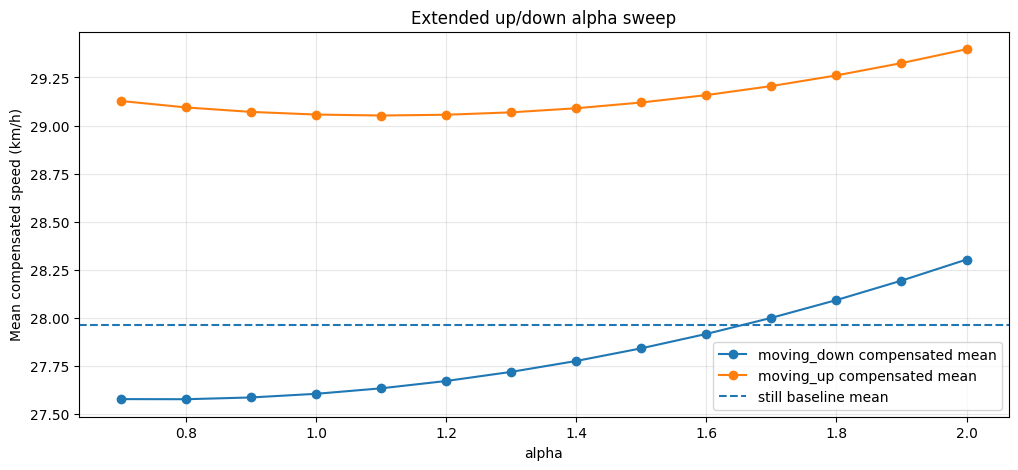

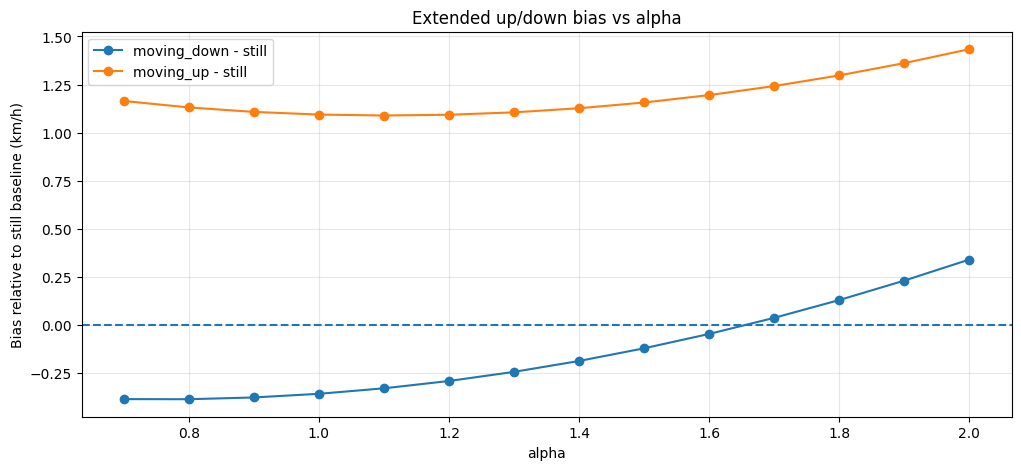

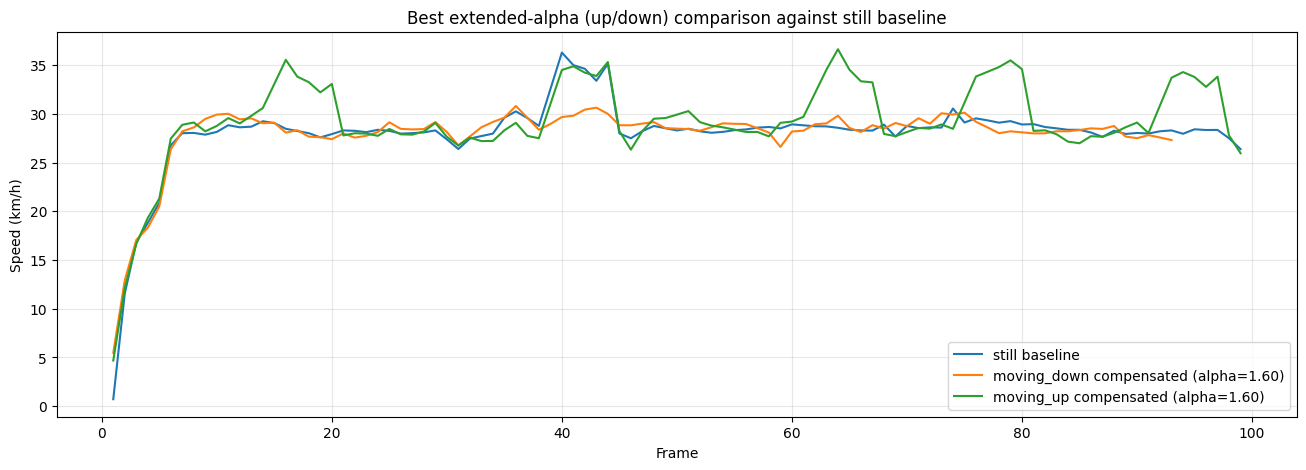

Cell 16 complete.
Selected BEST_ALPHA_UP_DOWN_EXT = 1.60


In [17]:
# ============================================================
# Cell 16: Extended alpha sweep for moving_down and moving_up
#
# Purpose:
# - continue the up/down alpha sweep beyond 1.30
# - test whether the best alpha for vertical camera motion is
#   simply outside the previous search range
#
# What we learned so far:
# - left/right preferred alpha ≈ 0.90
# - up/down did NOT behave the same way
# - moving_up stayed noticeably above the still baseline and was
#   only weakly sensitive to alpha in the 0.70 -> 1.30 range
# - so we now test a larger alpha range before deciding whether
#   alpha alone can solve vertical-motion bias
#
# Output:
# - summary table for extended alpha sweep
# - plots of mean compensated speed vs alpha
# - best-alpha comparison against still baseline
#
# Expected interpretation:
# - if the best alpha keeps drifting to the upper boundary, then
#   alpha alone is probably not the real fix
# - if a clear interior optimum appears, then we can keep a
#   direction-specific alpha for up/down
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Extended alpha range
# -----------------------------
ALPHA_VALUES_UP_DOWN_EXT = [
    0.70, 0.80, 0.90, 1.00, 1.10, 1.20, 1.30,
    1.40, 1.50, 1.60, 1.70, 1.80, 1.90, 2.00
]

print("Still-camera baseline mean speed (km/h):", round(still_baseline_mean_kmh, 6))

# -----------------------------
# 2) Run extended alpha sweep
# -----------------------------
down_alpha_ext_results = {}
up_alpha_ext_results = {}
up_down_alpha_ext_summary_rows = []

for alpha in ALPHA_VALUES_UP_DOWN_EXT:
    down_df_alpha = compensate_with_alpha(
        rel_df=MOVING_DOWN_REL_DF,
        ego_df=MOVING_DOWN_EGO_DF,
        camera_speed_kmh=NEW_CAMERA_SPEED_KMH_BY_VIDEO["moving_down"],
        alpha=alpha,
        video_key="moving_down",
    )

    up_df_alpha = compensate_with_alpha(
        rel_df=MOVING_UP_REL_DF,
        ego_df=MOVING_UP_EGO_DF,
        camera_speed_kmh=NEW_CAMERA_SPEED_KMH_BY_VIDEO["moving_up"],
        alpha=alpha,
        video_key="moving_up",
    )

    down_alpha_ext_results[alpha] = down_df_alpha
    up_alpha_ext_results[alpha] = up_df_alpha

    down_dom = (
        down_df_alpha[down_df_alpha["track_id"] == MOVING_DOWN_DOMINANT_TRACK_ID]
        .sort_values("frame_idx")
        .reset_index(drop=True)
    )
    up_dom = (
        up_df_alpha[up_df_alpha["track_id"] == MOVING_UP_DOMINANT_TRACK_ID]
        .sort_values("frame_idx")
        .reset_index(drop=True)
    )

    down_mean = float(down_dom["speed_world_kmh_alpha"].dropna().mean())
    up_mean = float(up_dom["speed_world_kmh_alpha"].dropna().mean())

    up_down_alpha_ext_summary_rows.append({
        "alpha": float(alpha),
        "still_baseline_mean_kmh": still_baseline_mean_kmh,
        "moving_down_mean_kmh": down_mean,
        "moving_up_mean_kmh": up_mean,
        "moving_down_minus_still": down_mean - still_baseline_mean_kmh,
        "moving_up_minus_still": up_mean - still_baseline_mean_kmh,
        "abs_total_error_vs_still": abs(down_mean - still_baseline_mean_kmh) + abs(up_mean - still_baseline_mean_kmh),
        "up_down_gap_kmh": up_mean - down_mean,
    })

up_down_alpha_ext_summary_df = (
    pd.DataFrame(up_down_alpha_ext_summary_rows)
    .sort_values("alpha")
    .reset_index(drop=True)
)

print("=== Extended up/down alpha sweep summary ===")
display(up_down_alpha_ext_summary_df)

best_up_down_alpha_ext_row = up_down_alpha_ext_summary_df.sort_values(
    by=["abs_total_error_vs_still", "up_down_gap_kmh"],
    key=lambda s: np.abs(s) if s.name == "up_down_gap_kmh" else s
).iloc[0]

BEST_ALPHA_UP_DOWN_EXT = float(best_up_down_alpha_ext_row["alpha"])
print(f"Best extended alpha for up/down: {BEST_ALPHA_UP_DOWN_EXT:.2f}")

# -----------------------------
# 3) Plots
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(
    up_down_alpha_ext_summary_df["alpha"],
    up_down_alpha_ext_summary_df["moving_down_mean_kmh"],
    marker="o",
    label="moving_down compensated mean",
)
plt.plot(
    up_down_alpha_ext_summary_df["alpha"],
    up_down_alpha_ext_summary_df["moving_up_mean_kmh"],
    marker="o",
    label="moving_up compensated mean",
)
plt.axhline(still_baseline_mean_kmh, linestyle="--", label="still baseline mean")
plt.xlabel("alpha")
plt.ylabel("Mean compensated speed (km/h)")
plt.title("Extended up/down alpha sweep")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(
    up_down_alpha_ext_summary_df["alpha"],
    up_down_alpha_ext_summary_df["moving_down_minus_still"],
    marker="o",
    label="moving_down - still",
)
plt.plot(
    up_down_alpha_ext_summary_df["alpha"],
    up_down_alpha_ext_summary_df["moving_up_minus_still"],
    marker="o",
    label="moving_up - still",
)
plt.axhline(0.0, linestyle="--")
plt.xlabel("alpha")
plt.ylabel("Bias relative to still baseline (km/h)")
plt.title("Extended up/down bias vs alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 4) Best-alpha comparison
# -----------------------------
best_down_ext_df = down_alpha_ext_results[BEST_ALPHA_UP_DOWN_EXT]
best_up_ext_df = up_alpha_ext_results[BEST_ALPHA_UP_DOWN_EXT]

best_down_ext_dom = (
    best_down_ext_df[best_down_ext_df["track_id"] == MOVING_DOWN_DOMINANT_TRACK_ID]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

best_up_ext_dom = (
    best_up_ext_df[best_up_ext_df["track_id"] == MOVING_UP_DOMINANT_TRACK_ID]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

plt.figure(figsize=(16, 5))
plt.plot(
    STILL_BASELINE_DOMINANT_DF["frame_idx"],
    STILL_BASELINE_DOMINANT_DF["speed_rel_kmh_smooth"],
    label="still baseline",
)
plt.plot(
    best_down_ext_dom["frame_idx"],
    best_down_ext_dom["speed_world_kmh_alpha"],
    label=f"moving_down compensated (alpha={BEST_ALPHA_UP_DOWN_EXT:.2f})",
)
plt.plot(
    best_up_ext_dom["frame_idx"],
    best_up_ext_dom["speed_world_kmh_alpha"],
    label=f"moving_up compensated (alpha={BEST_ALPHA_UP_DOWN_EXT:.2f})",
)
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Best extended-alpha (up/down) comparison against still baseline")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 5) Save artifacts
# -----------------------------
CELL16_UP_DOWN_ALPHA_EXT_SUMMARY_DF = up_down_alpha_ext_summary_df
CELL16_BEST_ALPHA_UP_DOWN_EXT = BEST_ALPHA_UP_DOWN_EXT
CELL16_DOWN_ALPHA_EXT_RESULTS = down_alpha_ext_results
CELL16_UP_ALPHA_EXT_RESULTS = up_alpha_ext_results
CELL16_BEST_DOWN_EXT_DF = best_down_ext_df
CELL16_BEST_UP_EXT_DF = best_up_ext_df
CELL16_BEST_DOWN_EXT_DOM_DF = best_down_ext_dom
CELL16_BEST_UP_EXT_DOM_DF = best_up_ext_dom

print("Cell 16 complete.")
print(f"Selected BEST_ALPHA_UP_DOWN_EXT = {BEST_ALPHA_UP_DOWN_EXT:.2f}")

In [26]:
# ============================================================
# Final Cell: End-to-end moving-camera speed estimator
#
# Purpose:
# - run as a standalone pipeline on ANY input video
# - estimate camera ego direction from background motion
# - estimate per-object relative velocity using the locked-in
#   bbox-dimension foundation and the original representative point
# - compensate for camera motion
# - write a clean annotated output video
#
# Visual output:
# - bounding box
# - "ID <track_id>: <class> | <speed> km/h"
# - top-left smoothed ego arrow (camera motion direction)
#
# Intentionally NOT drawn:
# - red representative-point dot
# - blue trail
# - vx / vy values
# - confidence score
#
# Current locked-in choices:
# - representative point:
#     bottom_center + 8 px offset (the original chosen point)
# - ego direction:
#     estimated from background motion
# - camera speed magnitude:
#     provided by the caller
#
# Direction-aware compensation:
# - left/right experiments preferred alpha ≈ 0.90
# - up/down experiments preferred alpha ≈ 1.60
# - to support arbitrary camera direction, we blend them by the
#   smoothed camera-motion direction components:
#
#     alpha_eff = alpha_lr * |cam_dx| + alpha_ud * |cam_dy|
#
#   where:
#     cam_dx, cam_dy = unit camera-motion direction components
#
# This gives:
# - mostly horizontal motion -> alpha near alpha_lr
# - mostly vertical motion   -> alpha near alpha_ud
# - diagonal motion          -> interpolated alpha
# ============================================================

import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
from tqdm.auto import tqdm

# -----------------------------
# 0) User-facing configuration
# -----------------------------
BASE_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "vector_additions"
STILL_VIDEO_PATH = BASE_PATH / "camera_still.mp4"
MOVING_LEFT_VIDEO_PATH = BASE_PATH / "camera_moving_left.mp4"
MOVING_RIGHT_VIDEO_PATH = BASE_PATH / "camera_moving_right.mp4"
MOVING_UP_VIDEO_PATH = BASE_PATH / "camera_moving_up.mp4"
MOVING_DOWN_VIDEO_PATH = BASE_PATH / "camera_moving_down.mp4"
MOVING_CIRCLE_1M_VIDEO_PATH = BASE_PATH / "camera_moving_circle_1m.mp4"
MOVING_CIRCLE_2M_VIDEO_PATH = BASE_PATH / "camera_moving_circle_2m.mp4"

# Known camera speed magnitude in km/h for this video.
#   still        -> 0.0
#   moving left  -> 5.0
#   moving right -> 5.0
#   moving up    -> 5.0
#   moving down  -> 5.0
#   moving circle 1 meter radius  -> 5.0
#   moving circle 2 meter radius  -> 5.0

INPUT_VIDEO_PATHS_AND_SPEEDS = {
    "still": [STILL_VIDEO_PATH, 0.0],
    "moving_left": [MOVING_LEFT_VIDEO_PATH, 5.0],
    "moving_right": [MOVING_RIGHT_VIDEO_PATH, 5.0],
    "moving_up": [MOVING_UP_VIDEO_PATH, 5.0],
    "moving_down": [MOVING_DOWN_VIDEO_PATH, 5.0],
    "moving_circle_1m": [MOVING_CIRCLE_1M_VIDEO_PATH, 5.0],
    "moving_circle_2m": [MOVING_CIRCLE_2M_VIDEO_PATH, 5.0],
}

# Set to inout video and known camera speed
video_type = "moving_circle_2m"  # <-- change as needed
FINAL_INPUT_VIDEO_PATH = INPUT_VIDEO_PATHS_AND_SPEEDS[video_type][0]
FINAL_CAMERA_SPEED_KMH = INPUT_VIDEO_PATHS_AND_SPEEDS[video_type][1]

# Output location
FINAL_OUTPUT_DIR = OUTPUT_BASE_DIR / "04_final_end_to_end_outputs"
FINAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FINAL_RUN_NAME = Path(FINAL_INPUT_VIDEO_PATH).stem
FINAL_OUTPUT_VIDEO_PATH = FINAL_OUTPUT_DIR / f"{FINAL_RUN_NAME}_final_speed_estimation.mp4"
FINAL_OUTPUT_CSV_PATH = FINAL_OUTPUT_DIR / f"{FINAL_RUN_NAME}_final_speed_estimation.csv"

# Direction-aware alpha values learned from experiments
ALPHA_LEFT_RIGHT = BEST_ALPHA                 # expected ~0.90
ALPHA_UP_DOWN = BEST_ALPHA_UP_DOWN_EXT       # expected ~1.60

# -----------------------------
# 1) Locked-in estimator config
# -----------------------------
FINAL_DET_THRESHOLD = 0.30
FINAL_MIN_BOX_AREA = 30 * 30
FINAL_DETECT_EVERY_N = 1
FINAL_DEFAULT_FPS = 30.0

FINAL_TRACK_THRESH = 0.30
FINAL_TRACK_BUFFER = 30
FINAL_MATCH_THRESH = 0.80

FINAL_BORDER_MARGIN_PX = 20
FINAL_MPP_WINDOW = 5
FINAL_SPEED_WINDOW = 5
FINAL_MAX_REASONABLE_SPEED_KMH = 250.0

# locked-in representative point choice
FINAL_REP_POINT_MODE = "bottom_center"
FINAL_REP_Y_OFFSET_PX = 8.0

# ego-direction estimation config
FINAL_EGO_FEATURE_MAX_CORNERS = 600
FINAL_EGO_FEATURE_QUALITY = 0.01
FINAL_EGO_FEATURE_MIN_DISTANCE = 7
FINAL_EGO_FEATURE_BLOCK_SIZE = 7
FINAL_EGO_LK_WIN_SIZE = (21, 21)
FINAL_EGO_LK_MAX_LEVEL = 3
FINAL_EGO_LK_CRITERIA = (
    cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
    30,
    0.01,
)
FINAL_EGO_MIN_VALID_TRACKS = 25
FINAL_EGO_DIRECTION_SMOOTH_WINDOW = 5
FINAL_EGO_MASK_DILATE_PX = 12
FINAL_EGO_BORDER_MARGIN_PX = 10

# -----------------------------
# 2) Class priors (locked-in)
# -----------------------------
FINAL_CLASS_DIMENSION_PRIORS = {
    "Human": {"width_m": 0.50, "length_m": 0.50},
    "Bicycle": {"width_m": 0.60, "length_m": 1.80},
    "Car": {"width_m": 2.05, "length_m": 5.10},
    "Truck": {"width_m": 2.50, "length_m": 7.00},
    "Bus": {"width_m": 2.55, "length_m": 12.00},
    "Other": {"width_m": 2.00, "length_m": 4.50},
}

# -----------------------------
# 3) Helper functions
# -----------------------------
def final_canonicalize_class_name(label: str) -> str:
    if label is None:
        return "Other"
    label = str(label).strip()
    if label in FINAL_CLASS_DIMENSION_PRIORS:
        return label
    lowered = label.lower()
    aliases = {
        "person": "Human",
        "pedestrian": "Human",
        "people": "Human",
        "bike": "Bicycle",
        "bicycle": "Bicycle",
        "cyclist": "Bicycle",
        "car": "Car",
        "sedan": "Car",
        "van": "Car",
        "suv": "Car",
        "pickup": "Car",
        "truck": "Truck",
        "lorry": "Truck",
        "semi": "Truck",
        "bus": "Bus",
        "coach": "Bus",
        "other": "Other",
        "motor": "Other",
        "vehicle": "Other",
    }
    return aliases.get(lowered, "Other")

def final_rfdetr_to_sv_detections(det, min_conf=0.30):
    xyxy = np.asarray(det.xyxy, dtype=np.float32)
    conf = np.asarray(det.confidence, dtype=np.float32)
    cls = np.asarray(det.class_id, dtype=np.int32)

    keep = conf >= float(min_conf)
    return sv.Detections(
        xyxy=xyxy[keep],
        confidence=conf[keep],
        class_id=cls[keep],
    )

def final_build_tracker(frame_rate):
    sig = inspect.signature(sv.ByteTrack.__init__)
    params = set(sig.parameters.keys())
    kwargs = {}

    if "track_activation_threshold" in params:
        kwargs["track_activation_threshold"] = FINAL_TRACK_THRESH
    if "lost_track_buffer" in params:
        kwargs["lost_track_buffer"] = FINAL_TRACK_BUFFER
    if "minimum_matching_threshold" in params:
        kwargs["minimum_matching_threshold"] = FINAL_MATCH_THRESH
    if "frame_rate" in params:
        kwargs["frame_rate"] = int(round(frame_rate))

    if "track_thresh" in params:
        kwargs["track_thresh"] = FINAL_TRACK_THRESH
    if "track_buffer" in params:
        kwargs["track_buffer"] = FINAL_TRACK_BUFFER
    if "match_thresh" in params:
        kwargs["match_thresh"] = FINAL_MATCH_THRESH

    try:
        tracker = sv.ByteTrack(**kwargs)
    except TypeError:
        tracker = sv.ByteTrack()

    if hasattr(tracker, "reset"):
        tracker.reset()

    return tracker

def final_active_tracks_to_boxes_and_ids(tracker):
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

def final_bbox_touches_border(box_xyxy, image_width, image_height, margin_px=20):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return (
        x1 <= margin_px or
        y1 <= margin_px or
        x2 >= (image_width - margin_px) or
        y2 >= (image_height - margin_px)
    )

def final_bbox_bottom_center_xyxy(box_xyxy, y_offset_px=0.0):
    x1, y1, x2, y2 = map(float, box_xyxy)
    cx = 0.5 * (x1 + x2)
    cy = y2 + float(y_offset_px)
    return np.array([cx, cy], dtype=np.float32)

def final_representative_point_xyxy(box_xyxy):
    if FINAL_REP_POINT_MODE != "bottom_center":
        raise ValueError("This final cell is locked to bottom_center mode.")
    return final_bbox_bottom_center_xyxy(box_xyxy, y_offset_px=FINAL_REP_Y_OFFSET_PX)

def final_safe_bbox_dims(box_xyxy):
    x1, y1, x2, y2 = map(float, box_xyxy)
    w_px = max(float(x2 - x1), 1e-6)
    h_px = max(float(y2 - y1), 1e-6)
    return w_px, h_px

def final_compute_local_scale_from_box(box_xyxy, class_label):
    canonical = final_canonicalize_class_name(class_label)
    prior = FINAL_CLASS_DIMENSION_PRIORS[canonical]

    bbox_w_px, bbox_h_px = final_safe_bbox_dims(box_xyxy)
    mpp_x = float(prior["width_m"]) / bbox_w_px
    mpp_y = float(prior["length_m"]) / bbox_h_px
    mpp_geom = float(np.sqrt(max(mpp_x, 1e-12) * max(mpp_y, 1e-12)))

    return {
        "canonical_label": canonical,
        "bbox_width_px": bbox_w_px,
        "bbox_height_px": bbox_h_px,
        "mpp_x": mpp_x,
        "mpp_y": mpp_y,
        "mpp_geom": mpp_geom,
    }

def final_moving_average_ignore_none(values, window=5):
    recent = [float(v) for v in values if v is not None and np.isfinite(v)]
    if len(recent) == 0:
        return None
    return float(np.mean(recent[-int(window):]))

def final_make_object_mask(frame_shape, boxes_xyxy, dilate_px=12, border_margin_px=10):
    h, w = frame_shape[:2]
    mask = np.full((h, w), 255, dtype=np.uint8)

    if border_margin_px > 0:
        mask[:border_margin_px, :] = 0
        mask[h - border_margin_px:, :] = 0
        mask[:, :border_margin_px] = 0
        mask[:, w - border_margin_px:] = 0

    for box in boxes_xyxy:
        x1, y1, x2, y2 = map(int, np.round(box))
        x1 = max(0, x1 - dilate_px)
        y1 = max(0, y1 - dilate_px)
        x2 = min(w - 1, x2 + dilate_px)
        y2 = min(h - 1, y2 + dilate_px)
        mask[y1:y2 + 1, x1:x2 + 1] = 0

    return mask

def final_detect_background_features(gray_frame, allowed_mask):
    pts = cv2.goodFeaturesToTrack(
        gray_frame,
        maxCorners=FINAL_EGO_FEATURE_MAX_CORNERS,
        qualityLevel=FINAL_EGO_FEATURE_QUALITY,
        minDistance=FINAL_EGO_FEATURE_MIN_DISTANCE,
        blockSize=FINAL_EGO_FEATURE_BLOCK_SIZE,
        mask=allowed_mask,
    )
    if pts is None:
        return np.zeros((0, 1, 2), dtype=np.float32)
    return pts.astype(np.float32)

def final_robust_unit_direction_from_flows(flow_vectors, min_valid_tracks=25):
    flow_vectors = np.asarray(flow_vectors, dtype=np.float32)
    if flow_vectors.ndim != 2 or flow_vectors.shape[0] == 0:
        return {"ok": False}

    mags = np.linalg.norm(flow_vectors, axis=1)
    finite = np.isfinite(mags)
    flow_vectors = flow_vectors[finite]
    mags = mags[finite]

    if len(flow_vectors) < min_valid_tracks:
        return {"ok": False}

    q10, q90 = np.percentile(mags, [10, 90])
    keep = (mags >= q10) & (mags <= q90)
    trimmed = flow_vectors[keep]
    if len(trimmed) < min_valid_tracks:
        trimmed = flow_vectors

    mean_flow = np.median(trimmed, axis=0).astype(np.float32)
    mean_dx = float(mean_flow[0])
    mean_dy = float(mean_flow[1])
    mag = float(np.sqrt(mean_dx**2 + mean_dy**2))

    if not np.isfinite(mag) or mag <= 1e-8:
        return {"ok": False}

    return {
        "ok": True,
        "n_used": int(len(trimmed)),
        "mean_dx": mean_dx,
        "mean_dy": mean_dy,
        "unit_dx": mean_dx / mag,
        "unit_dy": mean_dy / mag,
        "flow_mag_px": mag,
    }

def final_moving_average_unit_vectors(dx_list, dy_list, window=5):
    recent = []
    for dx, dy in zip(dx_list, dy_list):
        if dx is None or dy is None:
            continue
        if not (np.isfinite(dx) and np.isfinite(dy)):
            continue
        recent.append([float(dx), float(dy)])

    if len(recent) == 0:
        return None, None

    recent = np.asarray(recent[-int(window):], dtype=np.float64)
    mean_vec = recent.mean(axis=0)
    mag = float(np.linalg.norm(mean_vec))
    if mag <= 1e-8 or not np.isfinite(mag):
        return None, None

    return float(mean_vec[0] / mag), float(mean_vec[1] / mag)

def final_make_empty_track_history():
    return {
        "frames": [],
        "labels": [],
        "image_points": [],
        "mpp_geom": [],
        "mpp_smoothed": [],
        "vx_rel_mps_raw": [],
        "vy_rel_mps_raw": [],
        "speed_rel_kmh_raw": [],
        "vx_rel_mps_smooth": [],
        "vy_rel_mps_smooth": [],
        "speed_rel_kmh_smooth": [],
    }

def final_append_relative_velocity_observation(track_history, frame_idx, box_xyxy, class_label, fps):
    rep_pt = final_representative_point_xyxy(box_xyxy)
    scale_info = final_compute_local_scale_from_box(box_xyxy, class_label)

    track_history["frames"].append(int(frame_idx))
    track_history["labels"].append(class_label)
    track_history["image_points"].append(rep_pt)
    track_history["mpp_geom"].append(scale_info["mpp_geom"])

    current_mpp_smoothed = final_moving_average_ignore_none(
        track_history["mpp_geom"],
        window=FINAL_MPP_WINDOW,
    )
    track_history["mpp_smoothed"].append(current_mpp_smoothed)

    vx_rel_mps_raw = None
    vy_rel_mps_raw = None
    speed_rel_kmh_raw = None

    if len(track_history["image_points"]) >= 2:
        p1 = np.asarray(track_history["image_points"][-2], dtype=np.float64)
        p2 = np.asarray(track_history["image_points"][-1], dtype=np.float64)

        prev_mpp = track_history["mpp_smoothed"][-2]
        curr_mpp = track_history["mpp_smoothed"][-1]

        if prev_mpp is not None and curr_mpp is not None:
            local_mpp = 0.5 * (float(prev_mpp) + float(curr_mpp))
            dt = 1.0 / float(fps)

            dx_px = float(p2[0] - p1[0])
            dy_px = float(p2[1] - p1[1])

            vx_rel_mps_raw = (dx_px * local_mpp) / dt
            vy_rel_mps_raw = (dy_px * local_mpp) / dt
            speed_rel_mps_raw = float(np.sqrt(vx_rel_mps_raw**2 + vy_rel_mps_raw**2))
            speed_rel_kmh_raw = 3.6 * speed_rel_mps_raw

            if not (0.0 <= speed_rel_kmh_raw <= FINAL_MAX_REASONABLE_SPEED_KMH):
                vx_rel_mps_raw = None
                vy_rel_mps_raw = None
                speed_rel_kmh_raw = None

    track_history["vx_rel_mps_raw"].append(vx_rel_mps_raw)
    track_history["vy_rel_mps_raw"].append(vy_rel_mps_raw)
    track_history["speed_rel_kmh_raw"].append(speed_rel_kmh_raw)

    vx_rel_mps_smooth = final_moving_average_ignore_none(
        track_history["vx_rel_mps_raw"], window=FINAL_SPEED_WINDOW
    )
    vy_rel_mps_smooth = final_moving_average_ignore_none(
        track_history["vy_rel_mps_raw"], window=FINAL_SPEED_WINDOW
    )
    speed_rel_kmh_smooth = None
    if vx_rel_mps_smooth is not None and vy_rel_mps_smooth is not None:
        speed_rel_kmh_smooth = 3.6 * float(np.sqrt(vx_rel_mps_smooth**2 + vy_rel_mps_smooth**2))

    track_history["vx_rel_mps_smooth"].append(vx_rel_mps_smooth)
    track_history["vy_rel_mps_smooth"].append(vy_rel_mps_smooth)
    track_history["speed_rel_kmh_smooth"].append(speed_rel_kmh_smooth)

    return {
        "rep_pt": rep_pt,
        "scale_info": scale_info,
        "vx_rel_mps_smooth": vx_rel_mps_smooth,
        "vy_rel_mps_smooth": vy_rel_mps_smooth,
        "speed_rel_kmh_smooth": speed_rel_kmh_smooth,
    }

# -----------------------------
# 4) End-to-end runner
# -----------------------------
def run_final_end_to_end_speed_estimator(
    video_path,
    output_video_path,
    output_csv_path,
    camera_speed_kmh,
    detector,
    class_map,
):
    video_path = Path(video_path)
    output_video_path = Path(output_video_path)
    output_csv_path = Path(output_csv_path)
    output_video_path.parent.mkdir(parents=True, exist_ok=True)
    output_csv_path.parent.mkdir(parents=True, exist_ok=True)

    temp_infer_path = output_video_path.parent / f"_{video_path.stem}_temp_frame.jpg"

    # ---- Pass 1: estimate background ego direction per frame ----
    cap = cv2.VideoCapture(str(video_path))
    assert cap.isOpened(), f"Could not open video: {video_path}"

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or not np.isfinite(fps) or fps <= 1:
        fps = FINAL_DEFAULT_FPS

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    tracker_ego = final_build_tracker(frame_rate=fps)
    track_meta_ego = {}

    prev_gray = None
    prev_background_pts = None
    smooth_unit_dx_hist = []
    smooth_unit_dy_hist = []
    ego_rows = []

    pbar1 = tqdm(total=total_frames, desc="Pass 1/2: ego direction")

    for frame_idx in range(total_frames):
        ok, frame_bgr = cap.read()
        if not ok:
            break

        frame_gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

        if frame_idx % FINAL_DETECT_EVERY_N == 0:
            ok_write = cv2.imwrite(str(temp_infer_path), frame_bgr)
            assert ok_write, f"Failed to write temp frame: {temp_infer_path}"

            det = detector.predict(str(temp_infer_path), threshold=FINAL_DET_THRESHOLD)
            detections = final_rfdetr_to_sv_detections(det, min_conf=FINAL_DET_THRESHOLD)

            if len(detections) > 0:
                xyxy = detections.xyxy
                areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
                keep = areas >= FINAL_MIN_BOX_AREA
                detections = detections[keep]

            det_with_ids = tracker_ego.update_with_detections(detections)

            if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
                for i in range(len(det_with_ids)):
                    tid = int(det_with_ids.tracker_id[i])
                    cls = int(det_with_ids.class_id[i])
                    label = class_map.get(cls, "Other")
                    track_meta_ego[tid] = label
        else:
            empty_dets = sv.Detections(
                xyxy=np.zeros((0, 4), dtype=np.float32),
                confidence=np.zeros((0,), dtype=np.float32),
                class_id=np.zeros((0,), dtype=np.int32),
            )
            _ = tracker_ego.update_with_detections(empty_dets)

        active_boxes, active_ids = final_active_tracks_to_boxes_and_ids(tracker_ego)
        bg_mask = final_make_object_mask(
            frame_shape=frame_bgr.shape,
            boxes_xyxy=active_boxes,
            dilate_px=FINAL_EGO_MASK_DILATE_PX,
            border_margin_px=FINAL_EGO_BORDER_MARGIN_PX,
        )

        mean_dx = None
        mean_dy = None
        unit_dx = None
        unit_dy = None
        unit_dx_smooth = None
        unit_dy_smooth = None
        n_used = 0
        flow_mag_px = None

        if prev_gray is not None:
            need_new_points = (
                prev_background_pts is None or
                len(prev_background_pts) < FINAL_EGO_MIN_VALID_TRACKS
            )

            if need_new_points:
                prev_bg_mask = final_make_object_mask(
                    frame_shape=frame_bgr.shape,
                    boxes_xyxy=active_boxes,
                    dilate_px=FINAL_EGO_MASK_DILATE_PX,
                    border_margin_px=FINAL_EGO_BORDER_MARGIN_PX,
                )
                prev_background_pts = final_detect_background_features(prev_gray, prev_bg_mask)

            if prev_background_pts is not None and len(prev_background_pts) > 0:
                next_pts, status, err = cv2.calcOpticalFlowPyrLK(
                    prev_gray,
                    frame_gray,
                    prev_background_pts,
                    None,
                    winSize=FINAL_EGO_LK_WIN_SIZE,
                    maxLevel=FINAL_EGO_LK_MAX_LEVEL,
                    criteria=FINAL_EGO_LK_CRITERIA,
                )

                if next_pts is not None and status is not None:
                    good_prev = prev_background_pts[status.flatten() == 1].reshape(-1, 2)
                    good_next = next_pts[status.flatten() == 1].reshape(-1, 2)

                    valid_prev = []
                    valid_next = []
                    for p0, p1 in zip(good_prev, good_next):
                        x1i = int(round(p1[0]))
                        y1i = int(round(p1[1]))
                        if 0 <= x1i < width and 0 <= y1i < height and bg_mask[y1i, x1i] > 0:
                            valid_prev.append(p0)
                            valid_next.append(p1)

                    if len(valid_prev) > 0:
                        valid_prev = np.asarray(valid_prev, dtype=np.float32)
                        valid_next = np.asarray(valid_next, dtype=np.float32)
                        flows = valid_next - valid_prev

                        robust = final_robust_unit_direction_from_flows(
                            flows,
                            min_valid_tracks=FINAL_EGO_MIN_VALID_TRACKS,
                        )

                        if robust.get("ok", False):
                            mean_dx = robust["mean_dx"]
                            mean_dy = robust["mean_dy"]
                            unit_dx = robust["unit_dx"]
                            unit_dy = robust["unit_dy"]
                            n_used = robust["n_used"]
                            flow_mag_px = robust["flow_mag_px"]

                            smooth_unit_dx_hist.append(unit_dx)
                            smooth_unit_dy_hist.append(unit_dy)

                            unit_dx_smooth, unit_dy_smooth = final_moving_average_unit_vectors(
                                smooth_unit_dx_hist,
                                smooth_unit_dy_hist,
                                window=FINAL_EGO_DIRECTION_SMOOTH_WINDOW,
                            )

                    prev_background_pts = valid_next.reshape(-1, 1, 2) if len(valid_prev) > 0 else None
                else:
                    prev_background_pts = None

        ego_rows.append({
            "frame_idx": int(frame_idx),
            "mean_flow_dx_px": mean_dx,
            "mean_flow_dy_px": mean_dy,
            "ego_unit_dx_raw": unit_dx,
            "ego_unit_dy_raw": unit_dy,
            "ego_unit_dx_smooth": unit_dx_smooth,
            "ego_unit_dy_smooth": unit_dy_smooth,
            "flow_mag_px": flow_mag_px,
            "n_background_tracks_used": int(n_used),
        })

        prev_gray = frame_gray
        pbar1.update(1)

    pbar1.close()
    cap.release()

    ego_df = pd.DataFrame(ego_rows)

    # ---- Pass 2: relative estimation + final rendering ----
    cap = cv2.VideoCapture(str(video_path))
    assert cap.isOpened(), f"Could not reopen video: {video_path}"

    tracker_obj = final_build_tracker(frame_rate=fps)
    track_meta = {}
    track_histories = {}
    output_rows = []

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_video_path), fourcc, fps, (width, height))
    assert writer.isOpened(), f"Could not open writer: {output_video_path}"

    pbar2 = tqdm(total=total_frames, desc="Pass 2/2: render final output")

    for frame_idx in range(total_frames):
        ok, frame_bgr = cap.read()
        if not ok:
            break

        if frame_idx % FINAL_DETECT_EVERY_N == 0:
            ok_write = cv2.imwrite(str(temp_infer_path), frame_bgr)
            assert ok_write, f"Failed to write temp frame: {temp_infer_path}"

            det = detector.predict(str(temp_infer_path), threshold=FINAL_DET_THRESHOLD)
            detections = final_rfdetr_to_sv_detections(det, min_conf=FINAL_DET_THRESHOLD)

            if len(detections) > 0:
                xyxy = detections.xyxy
                areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
                keep = areas >= FINAL_MIN_BOX_AREA
                detections = detections[keep]

            det_with_ids = tracker_obj.update_with_detections(detections)

            if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
                for i in range(len(det_with_ids)):
                    tid = int(det_with_ids.tracker_id[i])
                    cls = int(det_with_ids.class_id[i])
                    label = class_map.get(cls, "Other")
                    track_meta[tid] = (cls, label)
        else:
            empty_dets = sv.Detections(
                xyxy=np.zeros((0, 4), dtype=np.float32),
                confidence=np.zeros((0,), dtype=np.float32),
                class_id=np.zeros((0,), dtype=np.int32),
            )
            _ = tracker_obj.update_with_detections(empty_dets)

        frame_rows = []
        boxes, ids = final_active_tracks_to_boxes_and_ids(tracker_obj)

        ego_row = ego_df[ego_df["frame_idx"] == frame_idx]
        if len(ego_row) > 0:
            ego_row = ego_row.iloc[0]
            ego_bg_dx = ego_row["ego_unit_dx_smooth"]
            ego_bg_dy = ego_row["ego_unit_dy_smooth"]
        else:
            ego_bg_dx = None
            ego_bg_dy = None

        # background flow direction -> camera motion direction
        cam_unit_dx = None
        cam_unit_dy = None
        alpha_eff = None
        vx_cam_mps = None
        vy_cam_mps = None

        if ego_bg_dx is not None and ego_bg_dy is not None and np.isfinite(ego_bg_dx) and np.isfinite(ego_bg_dy):
            cam_unit_dx = -float(ego_bg_dx)
            cam_unit_dy = -float(ego_bg_dy)

            alpha_eff = (
                float(ALPHA_LEFT_RIGHT) * abs(cam_unit_dx) +
                float(ALPHA_UP_DOWN) * abs(cam_unit_dy)
            )

            camera_speed_mps = float(camera_speed_kmh) / 3.6
            vx_cam_mps = alpha_eff * camera_speed_mps * cam_unit_dx
            vy_cam_mps = alpha_eff * camera_speed_mps * cam_unit_dy

        out = frame_bgr.copy()

        for box, tid in zip(boxes, ids):
            cls, label = track_meta.get(tid, (-1, "Other"))
            if final_bbox_touches_border(box, width, height, margin_px=FINAL_BORDER_MARGIN_PX):
                continue

            if tid not in track_histories:
                track_histories[tid] = final_make_empty_track_history()

            result = final_append_relative_velocity_observation(
                track_history=track_histories[tid],
                frame_idx=frame_idx,
                box_xyxy=box,
                class_label=label,
                fps=fps,
            )

            vx_rel = result["vx_rel_mps_smooth"]
            vy_rel = result["vy_rel_mps_smooth"]
            speed_rel = result["speed_rel_kmh_smooth"]

            speed_world = None
            if vx_rel is not None and vy_rel is not None and vx_cam_mps is not None and vy_cam_mps is not None:
                vx_world = float(vx_rel) + float(vx_cam_mps)
                vy_world = float(vy_rel) + float(vy_cam_mps)
                speed_world = 3.6 * float(np.sqrt(vx_world**2 + vy_world**2))
            else:
                speed_world = speed_rel

            frame_rows.append({
                "track_id": int(tid),
                "frame_idx": int(frame_idx),
                "class_id": int(cls),
                "label": label,
                "bbox_x1": float(box[0]),
                "bbox_y1": float(box[1]),
                "bbox_x2": float(box[2]),
                "bbox_y2": float(box[3]),
                "vx_rel_mps_smooth": vx_rel,
                "vy_rel_mps_smooth": vy_rel,
                "speed_rel_kmh_smooth": speed_rel,
                "ego_bg_dx_smooth": ego_bg_dx,
                "ego_bg_dy_smooth": ego_bg_dy,
                "cam_unit_dx": cam_unit_dx,
                "cam_unit_dy": cam_unit_dy,
                "alpha_eff": alpha_eff,
                "vx_cam_mps": vx_cam_mps,
                "vy_cam_mps": vy_cam_mps,
                "speed_world_kmh": speed_world,
            })

            x1, y1, x2, y2 = map(int, np.round(box))
            cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)

            text = f"ID {tid}: {label}"
            if speed_world is not None and np.isfinite(speed_world):
                text += f" | {speed_world:.2f} km/h"

            cv2.putText(
                out,
                text,
                (x1, max(0, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                1,
                cv2.LINE_AA,
            )

        # draw top-left camera-motion arrow
        arrow_origin = np.array([70, 70], dtype=np.int32)
        arrow_len = 50

        camera_is_still = abs(float(camera_speed_kmh)) < 1e-6

        if camera_is_still:
            # Show a dot instead of an arrow when the input says the camera is not moving
            cv2.circle(out, tuple(arrow_origin), 8, (0, 255, 255), -1)
            cv2.putText(
                out,
                "camera still",
                (20, 25),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                (0, 255, 255),
                2,
                cv2.LINE_AA,
            )
        elif cam_unit_dx is not None and cam_unit_dy is not None:
            end_pt = arrow_origin + np.round(
                arrow_len * np.array([cam_unit_dx, cam_unit_dy])
            ).astype(np.int32)

            cv2.arrowedLine(
                out,
                tuple(arrow_origin),
                tuple(end_pt),
                (0, 255, 255),
                3,
                tipLength=0.25,
            )
            cv2.putText(
                out,
                "camera ego",
                (20, 25),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                (0, 255, 255),
                2,
                cv2.LINE_AA,
            )
        else:
            # fallback when motion is nonzero but ego direction is temporarily unavailable
            cv2.circle(out, tuple(arrow_origin), 8, (0, 255, 255), 2)
            cv2.putText(
                out,
                "camera ego unavailable",
                (20, 25),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                (0, 255, 255),
                2,
                cv2.LINE_AA,
            )

        writer.write(out)
        output_rows.extend(frame_rows)
        pbar2.update(1)

    pbar2.close()
    cap.release()
    writer.release()

    if temp_infer_path.exists():
        try:
            temp_infer_path.unlink()
        except Exception:
            pass

    obs_df = pd.DataFrame(output_rows)
    obs_df.to_csv(output_csv_path, index=False)

    print("\n=== Final outputs ===")
    print("Output video:", output_video_path)
    print("Output CSV  :", output_csv_path)

    return {
        "ego_df": ego_df,
        "obs_df": obs_df,
        "output_video_path": output_video_path,
        "output_csv_path": output_csv_path,
    }

# -----------------------------
# 5) Run the final pipeline
# -----------------------------
assert Path(FINAL_INPUT_VIDEO_PATH).exists(), f"Missing input video: {FINAL_INPUT_VIDEO_PATH}"

FINAL_RESULTS = run_final_end_to_end_speed_estimator(
    video_path=FINAL_INPUT_VIDEO_PATH,
    output_video_path=FINAL_OUTPUT_VIDEO_PATH,
    output_csv_path=FINAL_OUTPUT_CSV_PATH,
    camera_speed_kmh=FINAL_CAMERA_SPEED_KMH,
    detector=DETECTOR,
    class_map=PHASE_CLASSES,
)

print("\nDone.")
print("Annotated final video:", FINAL_RESULTS["output_video_path"])
print("Final observations CSV:", FINAL_RESULTS["output_csv_path"])

Pass 1/2: ego direction:   0%|          | 0/120 [00:00<?, ?it/s]

Pass 2/2: render final output:   0%|          | 0/120 [00:00<?, ?it/s]


=== Final outputs ===
Output video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\04_final_end_to_end_outputs\camera_moving_circle_2m_final_speed_estimation.mp4
Output CSV  : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\04_final_end_to_end_outputs\camera_moving_circle_2m_final_speed_estimation.csv

Done.
Annotated final video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\04_final_end_to_end_outputs\camera_moving_circle_2m_final_speed_estimation.mp4
Final observations CSV: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\vector_additions\moving_camera_velocity_pipeline\04_final_end_to_end_outputs\camera_moving_circle_2m_fi